In [3]:
# Library Imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import my_functions as mf
from scipy.optimize import curve_fit
from scipy.fftpack import fft, ifft, fftfreq
from scipy.special import voigt_profile
from scipy.signal import convolve
import re
import importlib
importlib.reload(mf)
from collections import defaultdict

In [4]:
data_path = r"data_optics\IH_Studies\2025-11-12\2025-12-25_IH_line_magnet_ramp/"
figure_save_path="/Users/fergusayton/Documents/My Library/fayt3249/2024/Honours Thesis/Thesis Figures and Diagrams/Figures/MyResults"
data_file = r"data_optics\IH_Studies\2025-11-12\2025-12-25_IH_line_magnet_ramp\2025-11-12 16-48-23_freq_195.11768_rng_37.0026_gain_0_fld_0.054561865999999994.csv"


## Functions ## 

In [5]:
def read_B_field(file_name):
    match = re.search(r'fld_([0-9.]+)', file_name)
    if match: 
        
        b_field = float(match.group(1).strip("."))
        return b_field
    else: 
        print("Error: field value not found in filename.")



def normalise_traces(traces, floors = None, flip = False):
    '''
    Normalisation function for traces. Normalised between a provided floor for *each* trace
    (or zero) and the maximum of each array OR between zero and the maximum, if no floors provided.

    If flip is true, then subtracts 1 at the end and flips, so it's an upwards peak (for peak fitting convenience).

    Inputs:
        traces: enumerable of individual np.arrays. Typically a tuple. 
        floors = None: enumerable of detector floors/blanks the gain setting used to take data. This value will be subtracted before normalisation. 
        flip = False: if true, make the background 0 and flip the peaks so that they go upwards (rather than down from 1). 
    
    Returns:
        cal_traces: tuple of individual np.arrays.
    '''
    
    # If no floors provided, make them all zero
    if not floors:
        floors = np.zeros(len(traces))
    # Do the thing
    if flip: # if flip true then flip it
        cal_traces = tuple( 
            -1*((trace - floors[i]) / (np.max(trace) - floors[i]) - 1) for i, trace in enumerate(traces)
        )
    else: # otherwise don't flip it
        cal_traces = tuple( 
            (trace - floors[i]) / (np.max(trace) - floors[i]) for i, trace in enumerate(traces)
        )
    
    return cal_traces

    

## Single Spectrum ## 

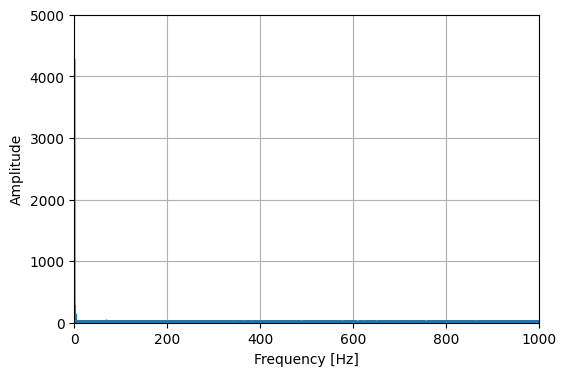

<Figure size 640x480 with 0 Axes>

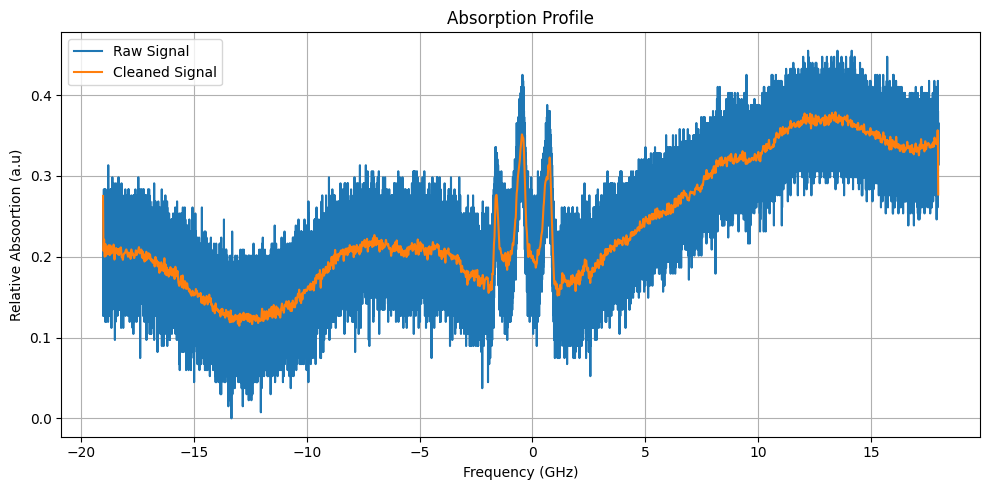

In [6]:

# Step 1: read CSV
data = pd.read_csv(data_file, header=None)

# Extract time, signal, and frequency
time_axis = data.iloc[0].values.astype(float)
voltage = data.iloc[1].values.astype(float)
freq_axis = data.iloc[2].values.astype(float)

# Normalise and Flip absorotion 
# signal = -voltage
# signal = mf.normalise_0_1(signal)


voltage_traces = (voltage,)  # tuple of a single 1D array
floors = (-0.03080024083683403,)

# Apply normalization (flip=True if you want dips → peaks)
normalized_traces = mf.normalise_traces(voltage_traces, floors=floors, flip=True)
signal =normalized_traces[0]

# Convert frequency from Hz to GHz for cleaner axis
freq_axis_GHz = freq_axis / 1e9
## Low Pass Band Filter ## 20 Hz. 
cleaned = mf.low_pass_band_filter_fft(20,freq_axis_GHz,signal,plot_check=True)

# Plot absorption profile
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq_axis_GHz, signal, label='Raw Signal')
ax.plot(freq_axis_GHz, cleaned, label='Cleaned Signal')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Relative Absoortion (a.u)")
ax.set_title("Absorption Profile")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()



## 2D Colour Map ## 

In [7]:
data_files =  sorted(glob.glob(data_path +"*"))

voltages = [] 
fields = [] 

for file in data_files: 
    # Step 1: read CSV
    data = pd.read_csv(file, header=None)
    # Extract time, signal, and frequency
    time_axis = data.iloc[0].values.astype(float)
    voltage = data.iloc[1].values.astype(float)
    freq_axis = data.iloc[2].values.astype(float)

    #voltage = mf.low_pass_band_filter_fft(20,freq_axis_GHz,voltage,plot_check=False)

    # Convert frequency from Hz to GHz for cleaner axis
    freq_axis_GHz = freq_axis / 1e9

    B_field = read_B_field(file_name=file)
    fields.append(B_field)
    voltages.append(voltage)

fields = np.array(fields)
voltages = np.array(voltages)

# Sort by magnetic fieldusing arg sort
sort_idx = np.argsort(fields)
fields = fields[sort_idx]
voltages = voltages[sort_idx]


In [8]:
## Shift Frequency and  Normalise Volatage ## 
freq_shift = 0 # GHz
freq_axis_GHz_shifted= freq_axis_GHz-freq_shift

signals = -voltages
signals = mf.normalise_0_1(signals)

    # Convert voltages list to tuple of 1D arrays
voltage_traces = tuple(voltages)

# Optional: detector floors (if known), otherwise will default to 0
# Example: floors = np.array([np.min(v) for v in voltage_traces])
floors =tuple(-0.0035351922089636857*np.ones(len(voltage_traces))) # or: floors = np.array([0.0]*len(voltage_traces))

# Apply normalization (flip=True if you want dips → peaks)
normalized_traces = normalise_traces(voltage_traces, floors=floors, flip=True)
signals = np.array(normalized_traces)

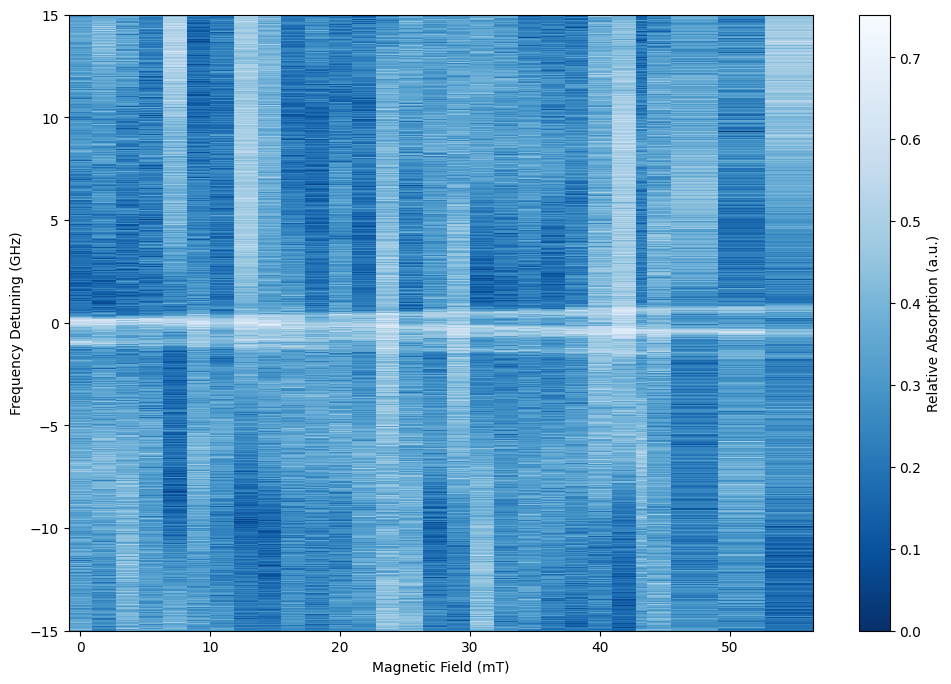

In [10]:
fig, ax = plt.subplots(figsize=(12,8))
#c= ax.pcolormesh(freq_axis_GHz, fields * 1000, voltages, shading='auto', cmap='Blues')
c=ax.pcolormesh(fields * 1000, freq_axis_GHz_shifted, signals.T, shading='auto', cmap='Blues_r')  # Alternative plot
ax.set_ylim([-15, 15])
#ax.set_ylim([80, 90])  # Uncomment and set limits if needed
cbar = fig.colorbar(c, ax=ax, label="Relative Absorption (a.u.)")
ax.set_xlabel("Magnetic Field (mT)")
ax.set_ylabel("Frequency Detuning (GHz)")
plt.show()


In [11]:
from qil_helpers.Fergus import plotting_helpers as ph 
ph.save_figure_as_is(fig, "2025_11_12_IH_Sweep_Blood_Orange_CC", "2025_11_12_IH_Sweep")

In [12]:

# mf.apply_fig_style(fig,ax,style="large", colorbar=cbar)
# mf.save_figure(fig,"25_03_2025_IH_abosorption_site1",folder=figure_save_path,dpi=1200)
# fig

## Linear Fitting and Graphing Peak Picking ## 

In [13]:
import pandas as pd
import numpy as np

# Paths to the peak data
peak_paths = {
    "A": "data_optics/peak_picking_data_2/2025_04_18_11_27_01_absorption_peaks_2025-03-25_site1_A.csv",
    "B": "data_optics/peak_picking_data_2/2025_04_18_11_38_46_absorption_peaks_2025-03-25_site1_B.csv",
    "C": "data_optics/peak_picking_data_2/2025_04_18_11_47_49_absorption_peaks_2025-03-25_site1_C.csv",
    "D": "data_optics/peak_picking_data_2/2025_04_18_11_56_05_absorption_peaks_2025-03-25_site1_D.csv",
    "E": "data_optics/peak_picking_data_2/2025_04_18_12_00_28_absorption_peaks_2025-03-25_site1_E.csv",
    "F": "data_optics/peak_picking_data_2/2025_04_18_12_03_43_absorption_peaks_2025-03-25_site1_F.csv"
}

peak_data = {}
slopes = {}
extrap_fields=np.arange(0, int(100),step=1)

# Load each peak data into a dictionary and calculate the slope and R^2
for peak, path in peak_paths.items():
    data = pd.read_csv(path)
    data = data.dropna() 
    freq = data['Frequency (GHz)'].values - freq_shift
    #print(freq)
    b_field = data['B Field (mT)'].values

    # Linear fit
    fit, cov = np.polyfit(b_field, freq, 1, cov=True)
    slope = fit[0]
    intercept = fit[1]
    slope_err = np.sqrt(cov[0, 0])  # standard error of slope
    intercept_err = np.sqrt(cov[1, 1])
    # Create the polynomial function for the fit
    poly = np.poly1d(fit)

    start_freq=poly(0)
    end_freq =poly(extrap_fields[-1])
    delta_f = np.abs(end_freq-start_freq)
    
    # Extrapolate the fit over the entire range of the predefined fields array
    extrapolated_fit = poly(extrap_fields)

    # Calculate fitted values for the original data
    fitted_values = poly(b_field)

    # Calculate R^2
    ss_res = np.sum((freq - fitted_values) ** 2)
    ss_tot = np.sum((freq - np.mean(freq)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    slopes[peak] = (slope, intercept, slope_err, intercept_err, r_squared)
    # Store the data and fit line
    peak_data[peak] = {
        "freq": freq,
        "b_field": b_field,
        "slope": slope,
        "r_squared": r_squared,
        "fit_line": fitted_values,
        "intercept": intercept,
        "extrapolated_fit": extrapolated_fit
    }
        # Store extended data
    peak_data[peak].update({
        "slope_err": slope_err,
        "intercept_err": intercept_err,
    })
    print(f"Slope of Peak {peak}: {slope:.6f} ± {slope_err:.6f} GHz/mT, R²: {r_squared:.6f}")
    print(f"Slope of Peak {peak}: {slope:.6f} GHz/mT, R²: {r_squared:.6f}, Intercept: {intercept:.6f}")
    print("Start Frequency=, " ,start_freq, "GHz")
    print("End Frequency=, " ,end_freq, "GHz")
    print("Delta F = ", delta_f, "GHz")
    print("\n")


Slope of Peak A: -0.026402 ± 0.000127 GHz/mT, R²: 0.998655
Slope of Peak A: -0.026402 GHz/mT, R²: 0.998655, Intercept: -0.075153
Start Frequency=,  -0.07515278147532253 GHz
End Frequency=,  -2.6889259197930926 GHz
Delta F =  2.6137731383177703 GHz


Slope of Peak B: 0.026524 ± 0.000153 GHz/mT, R²: 0.998075
Slope of Peak B: 0.026524 GHz/mT, R²: 0.998075, Intercept: -0.079796
Start Frequency=,  -0.07979642941660639 GHz
End Frequency=,  2.5460428759213087 GHz
Delta F =  2.625839305337915 GHz


Slope of Peak C: -0.019249 ± 0.000460 GHz/mT, R²: 0.967982
Slope of Peak C: -0.019249 GHz/mT, R²: 0.967982, Intercept: -1.344863
Start Frequency=,  -1.3448630254875413 GHz
End Frequency=,  -3.2505130314212476 GHz
Delta F =  1.9056500059337063 GHz


Slope of Peak D: 0.018046 ± 0.000244 GHz/mT, R²: 0.992543
Slope of Peak D: 0.018046 GHz/mT, R²: 0.992543, Intercept: -1.561375
Start Frequency=,  -1.5613747300718874 GHz
End Frequency=,  0.2251689621393027 GHz
Delta F =  1.7865436922111901 GHz


Slope of 

In [14]:
import pandas as pd
import numpy as np

# Paths to the peak data
peak_paths = {
    "A": "data_optics/peak_picking_data_2/2025_04_18_11_27_01_absorption_peaks_2025-03-25_site1_A.csv",
    "B": "data_optics/peak_picking_data_2/2025_04_18_11_38_46_absorption_peaks_2025-03-25_site1_B.csv",
    "C": "data_optics/peak_picking_data_2/2025_04_18_11_47_49_absorption_peaks_2025-03-25_site1_C.csv",
    "D": "data_optics/peak_picking_data_2/2025_04_18_11_56_05_absorption_peaks_2025-03-25_site1_D.csv",
    "E": "data_optics/peak_picking_data_2/2025_04_18_12_00_28_absorption_peaks_2025-03-25_site1_E.csv",
    "F": "data_optics/peak_picking_data_2/2025_04_18_12_03_43_absorption_peaks_2025-03-25_site1_F.csv"
}
peak_data = {}
slopes = {}
extrap_fields = np.arange(0, int(100), step=1)  # Adjust fields array as needed

# Load each peak data into a dictionary and calculate the slope and R^2
for peak, path in peak_paths.items():
    data = pd.read_csv(path)
    data = data.dropna()

    # Extract data columns based on the new structure
    freq = data['Frequency (GHz)'].values
    signal = data['Signal'].values  # Signal data (can be used for normalization or analysis)
    linewidth = data['Linewidth (GHz)'].values  # Linewidth data (for further analysis or display)
    scale = data['Scale'].values  # Scale data (if needed for processing or fitting)
    b_field = data['B Field (mT)'].values  # Magnetic field values

    # Linear fit
    fit, cov = np.polyfit(b_field, freq, 1, cov=True)
    slope = fit[0]
    intercept = fit[1]
    slope_err = np.sqrt(cov[0, 0])  # standard error of slope
    intercept_err = np.sqrt(cov[1, 1])

    # Create the polynomial function for the fit
    poly = np.poly1d(fit)

    # Extrapolate the frequency values
    start_freq = poly(0)
    end_freq = poly(extrap_fields[-1])
    delta_f = np.abs(end_freq - start_freq)

    # Extrapolate the fit over the entire range of the predefined fields array
    extrapolated_fit = poly(extrap_fields)

    # Calculate fitted values for the original data
    fitted_values = poly(b_field)

    # Calculate R^2
    ss_res = np.sum((freq - fitted_values) ** 2)
    ss_tot = np.sum((freq - np.mean(freq)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # Store the slope, intercept, and R^2 for each peak
    slopes[peak] = (slope, intercept, slope_err, intercept_err, r_squared)

    # Store the data, fit line, and other relevant information in the peak_data dictionary
    peak_data[peak] = {
        "freq": freq,
        "signal": signal,
        "linewidth": linewidth,
        "scale": scale,
        "b_field": b_field,
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared,
        "fit_line": fitted_values,
        "extrapolated_fit": extrapolated_fit
    }

    # Store extended data such as the errors
    peak_data[peak].update({
        "slope_err": slope_err,
        "intercept_err": intercept_err,
        "start_freq": start_freq,
        "end_freq": end_freq,
        "delta_f": delta_f
    })

    # Print out the results for each peak
    print(f"Slope of Peak {peak}: {slope:.6f} ± {slope_err:.6f} GHz/mT, R²: {r_squared:.6f}")
    print(f"Slope of Peak {peak}: {slope:.6f} GHz/mT, R²: {r_squared:.6f}, Intercept: {intercept:.6f}")
    print("Start Frequency= ", start_freq, "GHz")
    print("End Frequency= ", end_freq, "GHz")
    print("Delta F = ", delta_f, "GHz")
    print("\n")


Slope of Peak A: -0.026402 ± 0.000127 GHz/mT, R²: 0.998655
Slope of Peak A: -0.026402 GHz/mT, R²: 0.998655, Intercept: -0.750708
Start Frequency=  -0.7507077814753231 GHz
End Frequency=  -3.3644809197930927 GHz
Delta F =  2.61377313831777 GHz


Slope of Peak B: 0.026524 ± 0.000153 GHz/mT, R²: 0.998075
Slope of Peak B: 0.026524 GHz/mT, R²: 0.998075, Intercept: -0.755351
Start Frequency=  -0.7553514294166069 GHz
End Frequency=  1.8704878759213082 GHz
Delta F =  2.625839305337915 GHz


Slope of Peak C: -0.019249 ± 0.000460 GHz/mT, R²: 0.967982
Slope of Peak C: -0.019249 GHz/mT, R²: 0.967982, Intercept: -2.020418
Start Frequency=  -2.020418025487542 GHz
End Frequency=  -3.9260680314212477 GHz
Delta F =  1.9056500059337056 GHz


Slope of Peak D: 0.018046 ± 0.000244 GHz/mT, R²: 0.992543
Slope of Peak D: 0.018046 GHz/mT, R²: 0.992543, Intercept: -2.236930
Start Frequency=  -2.2369297300718873 GHz
End Frequency=  -0.4503860378606974 GHz
Delta F =  1.78654369221119 GHz


Slope of Peak E: -0.134

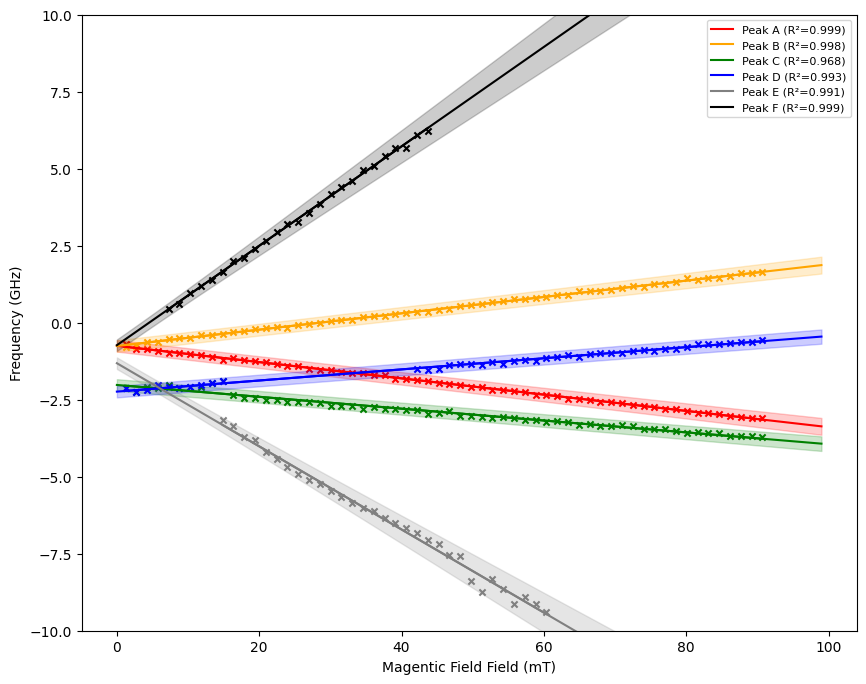

In [15]:
# Plot the data and linear fits
fig2, ax2 = plt.subplots(figsize=(10, 8))
#c = ax2.pcolormesh(fields * 1000,freq_axis_GHz, voltages.T, shading='auto', cmap='Blues')
# Plot the scatter points, linear fits, and extrapolated fits for each peak

uncert_f = 0.1875 #GHz
uncert_B_pct = 0.272/3.57220371#0.45 #%
colors = ['red', 'orange', 'green', 'blue', 'grey', 'k']
for i, (peak, data) in enumerate(peak_data.items()):
    freq_err = np.full_like(data['freq'], uncert_f)
    b_field = data['b_field']
    b_err = b_field * uncert_B_pct

    #ax2.errorbar(data['b_field'], data['freq'],xerr=b_err, yerr=freq_err,fmt=".",color=colors[i])#label=f"Peak {peak}"
    # Scatter plot of the original data points
    ax2.scatter(data['b_field'], data['freq'], color=colors[i], marker='x', s=20) #label=f"Peak {peak}"

    # Plot the fitted line within the original data range
    ax2.plot(data['b_field'], data['fit_line'], color=colors[i], label=f"Peak {peak} (R²={data['r_squared']:.3f})") # label=f"Fit {peak} (R²={data['r_squared']:.3f})"

    # Plot the extrapolated fit over the entire fields range
    ax2.plot(extrap_fields, data['extrapolated_fit'], color=colors[i])

        # Plot the extrapolated fit over the entire fields range
    #ax2.plot(extrap_fields, data['extrapolated_fit'], color=colors[i], linestyle='-')

    # --- Add shaded error region ---
    # Compute upper and lower bounds based on slope uncertainty
    slope = data['slope']
    intercept = data['intercept']
    slope_err = slopes[peak][0] * 0  # default fallback if not set
    if len(slopes[peak]) >= 4:
        slope_err = slopes[peak][2]  # slope_err is third if updated slopes[peak] has full info

    # Linear extrapolation with slope ± error
    # fit_upper = (slope + slope_err) * extrap_fields + intercept
    # fit_lower = (slope - slope_err) * extrap_fields + intercept

    # Total uncertainty in predicted frequency at each extrapolated B
    b_err_extrap = extrap_fields * uncert_B_pct  # extrapolated B uncertainty
    fit_center = slope * extrap_fields + intercept
    fit_err_band = np.sqrt((slope * b_err_extrap)**2 + uncert_f**2)

    fit_upper = fit_center + fit_err_band
    fit_lower = fit_center - fit_err_band

    peak_data[peak].update({
    "fit_upper": fit_upper,
    "fit_lower": fit_lower
    })

    # Shaded region between upper and lower
    ax2.fill_between(extrap_fields, fit_lower, fit_upper, color=colors[i], alpha=0.2)

# Add labels and legend
#fig2.colorbar(c, ax=ax2, label="Voltage")
ax2.set_ylim([-10,10])
ax2.set_xlabel("Magentic Field Field (mT)")
ax2.set_ylabel("Frequency (GHz)")
ax2.legend(fontsize=8)

In [16]:
print(extrap_fields)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


In [17]:
# mf.apply_fig_style(fig2,ax2,style="large", line_size=0.8,marker_size=0.1)
# mf.save_figure(fig2,"25_03_2025_IH_abosorption_site1_fitted_err2",folder=figure_save_path,dpi=1200)
# fig2

Slope of deltaE = F-A_ground_o: 0.187802 GHz/mT, Intercept: 0.020892
Slope of deltaE = B-E_ground_o: 0.161479 GHz/mT, Intercept: 0.559390
Slope of deltaE = A-E_excited_o: 0.108553 GHz/mT, Intercept: 0.564034
Slope of deltaE = F-B_excited_o: 0.134876 GHz/mT, Intercept: 0.025536


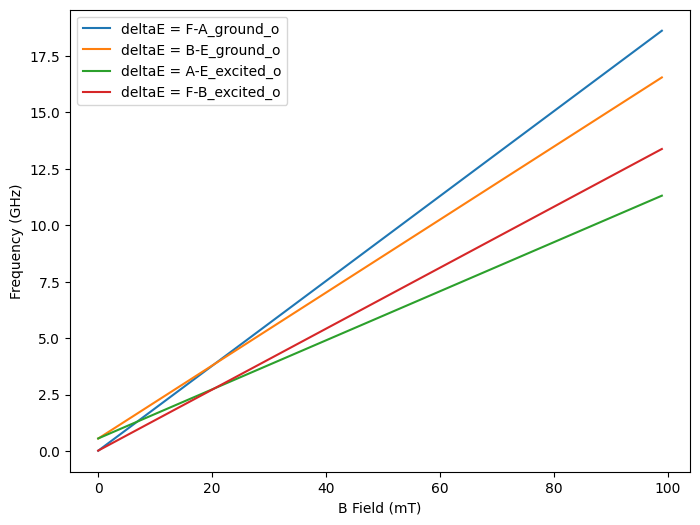

In [18]:
fig3, ax3 = plt.subplots(figsize=(8, 6))

# Get the extrapolated fit lines from the peak data
e2e_line = np.array(peak_data["A"]["extrapolated_fit"])
g2e_line = np.array(peak_data["F"]["extrapolated_fit"])
e2g_line = np.array(peak_data["E"]["extrapolated_fit"])
g2g_line = np.array(peak_data["B"]["extrapolated_fit"])

# Calculate the difference between lines
delta_E_abs_F_A = g2e_line - e2e_line
delta_E_abs_B_E = g2g_line - e2g_line
delta_E_abs_A_E = e2e_line - e2g_line
delta_E_abs_F_B = g2e_line - g2g_line

# Define a function to calculate the slope and plot the fitted line
def calculate_slope(x, y, label, units="GHz/mT"):
    # Perform linear fit
    fit = np.polyfit(x, y, 1)  # Degree 1 for linear fit
    slope, intercept = fit
    print(f"Slope of {label}: {slope:.6f} {units}, Intercept: {intercept:.6f}")
    
    # Plot the fitted line
    y_fit = np.poly1d(fit)(x)
   #ax3.plot(x, y_fit, linestyle='--', label=f"Fit {label} (Slope={slope:.3f})")
    return slope, intercept

# Plot the delta E lines
ax3.plot(extrap_fields, delta_E_abs_F_A, label="deltaE = F-A_ground_o")
ax3.plot(extrap_fields, delta_E_abs_B_E, label="deltaE = B-E_ground_o")
ax3.plot(extrap_fields, delta_E_abs_A_E, label="deltaE = A-E_excited_o")
ax3.plot(extrap_fields, delta_E_abs_F_B, label="deltaE = F-B_excited_o")

# Calculate slopes and plot fitted lines
slope_F_A, _ = calculate_slope(extrap_fields, delta_E_abs_F_A, "deltaE = F-A_ground_o")
slope_B_E, _ = calculate_slope(extrap_fields, delta_E_abs_B_E, "deltaE = B-E_ground_o")
slope_A_E, _ = calculate_slope(extrap_fields, delta_E_abs_A_E, "deltaE = A-E_excited_o")
slope_F_B, _ = calculate_slope(extrap_fields, delta_E_abs_F_B, "deltaE = F-B_excited_o")

# Plot settings
ax3.set_xlabel("B Field (mT)")
ax3.set_ylabel("Frequency (GHz)")
ax3.legend()
plt.show()


## G Tensor Calculations ## 

In [19]:
muB = 9.27400968e-24 #Bohr Magneton (J/T)
muN = 5.05078375e-27 #Nuclear Magneton (J/T)
hbar = 	1.054571817E-34 #Reduced planck constant (Js)
h = 2*np.pi*hbar #Planck constant (Js)
g_eff_F_A_ground_o = (h/muB)*slope_F_A*(10**9)/(10**(-3))
g_eff_B_E_ground_o = (h/muB)*slope_B_E*(10**9)/(10**(-3))
g_eff_F_A_excited_o =(h/muB)* slope_A_E*(10**9)/(10**(-3))
g_eff_A_E_excited_o = (h/muB)*slope_F_B*(10**9)/(10**(-3))

print("g_eff_F_A_ground_o = ",g_eff_F_A_ground_o )
print("g_eff_B_E_ground_o= ",g_eff_B_E_ground_o )
print("Average_Ground_o_ =", np.average([g_eff_F_A_ground_o,g_eff_B_E_ground_o]))
print("g_eff_F_A_excited_o = ",g_eff_F_A_excited_o )
print("g_eff_A_E_excited_o = ",g_eff_A_E_excited_o )
print("Average_Ground_o_ =", np.average([g_eff_F_A_excited_o,g_eff_A_E_excited_o]))

#  Can I calculate full g tensor ? 

g_eff_F_A_ground_o =  13.418003649312674
g_eff_B_E_ground_o=  11.537279897045112
Average_Ground_o_ = 12.477641773178892
g_eff_F_A_excited_o =  7.75588133613905
g_eff_A_E_excited_o =  9.636605088406613
Average_Ground_o_ = 8.696243212272831


## G TENSORS WITH UNCERT ## 

In [20]:
# ---- Compute g_eff from extrapolated slopes (including slope uncertainty from fill_between) ----

def get_delta_slope_and_error(peak1, peak2, label):
    y = np.array(peak_data[peak1]["extrapolated_fit"]) - np.array(peak_data[peak2]["extrapolated_fit"])
    y_upper = np.array(peak_data[peak1]["fit_upper"]) - np.array(peak_data[peak2]["fit_lower"])
    y_lower = np.array(peak_data[peak1]["fit_lower"]) - np.array(peak_data[peak2]["fit_upper"])

    m = np.polyfit(extrap_fields, y, 1)[0]
    m_upper = np.polyfit(extrap_fields, y_upper, 1)[0]
    m_lower = np.polyfit(extrap_fields, y_lower, 1)[0]
    m_err = np.abs(m_upper - m_lower) / 2

    print(f"{label}: slope = {m:.6f} ± {m_err:.6f} GHz/mT")
    return m, m_err


# Run this for each deltaE line
slope_F_A, slope_F_A_err = get_delta_slope_and_error("F", "A", "deltaE = F-A_ground_o")
slope_B_E, slope_B_E_err = get_delta_slope_and_error("B", "E", "deltaE = B-E_ground_o")
slope_A_E, slope_A_E_err = get_delta_slope_and_error("A", "E", "deltaE = A-E_excited_o")
slope_F_B, slope_F_B_err = get_delta_slope_and_error("F", "B", "deltaE = F-B_excited_o")


# ---- Physical constants ----
muB = 9.27400968e-24  # Bohr Magneton (J/T)
hbar = 1.054571817E-34  # Reduced Planck constant (Js)
h = 2 * np.pi * hbar
scale = (h / muB) * 1e9 / 1e-3  # Converts GHz/mT to unitless g_eff

# ---- Convert slopes to g_eff with uncertainty ----
g_eff_F_A = slope_F_A * scale
g_eff_F_A_err = slope_F_A_err * scale

g_eff_B_E = slope_B_E * scale
g_eff_B_E_err = slope_B_E_err * scale

g_eff_A_E = slope_A_E * scale
g_eff_A_E_err = slope_A_E_err * scale

g_eff_F_B = slope_F_B * scale
g_eff_F_B_err = slope_F_B_err * scale

# ---- Averages with propagated error ----
avg_ground = np.mean([g_eff_F_A, g_eff_B_E])
avg_ground_err = np.sqrt(g_eff_F_A_err**2 + g_eff_B_E_err**2) / 2

avg_excited = np.mean([g_eff_A_E, g_eff_F_B])
avg_excited_err = np.sqrt(g_eff_A_E_err**2 + g_eff_F_B_err**2) / 2

# ---- Output ----
print("\n---- g_eff Results ----")
print(f"g_eff_F_A_ground_o     = {g_eff_F_A:.3f} ± {g_eff_F_A_err:.3f}")
print(f"g_eff_B_E_ground_o     = {g_eff_B_E:.3f} ± {g_eff_B_E_err:.3f}")
print(f"Average Ground g_eff   = {avg_ground:.3f} ± {avg_ground_err:.3f}")
print("")
print(f"g_eff_A_E_excited_o    = {g_eff_A_E:.3f} ± {g_eff_A_E_err:.3f}")
print(f"g_eff_F_B_excited_o    = {g_eff_F_B:.3f} ± {g_eff_F_B_err:.3f}")
print(f"Average Excited g_eff  = {avg_excited:.3f} ± {avg_excited_err:.3f}")


deltaE = F-A_ground_o: slope = 0.187802 ± 0.012063 GHz/mT
deltaE = B-E_ground_o: slope = 0.161479 ± 0.009992 GHz/mT
deltaE = A-E_excited_o: slope = 0.108553 ± 0.009985 GHz/mT
deltaE = F-B_excited_o: slope = 0.134876 ± 0.012070 GHz/mT

---- g_eff Results ----
g_eff_F_A_ground_o     = 13.418 ± 0.862
g_eff_B_E_ground_o     = 11.537 ± 0.714
Average Ground g_eff   = 12.478 ± 0.560

g_eff_A_E_excited_o    = 7.756 ± 0.713
g_eff_F_B_excited_o    = 9.637 ± 0.862
Average Excited g_eff  = 8.696 ± 0.560


## Global Magnetic Field Inhomogeniety ## 
- The Zero field splitting is characterisitc of strain on the crystal. Meaning that part of the crystal is under a an amount of stress. 
- The gradient of the that absopriton line as compared to the other line should give us an estimate on the magnetic field homoegenity across the crystal if we assume the starin and the unstrained part are at the length of the crystal. This should give use b-axis magnetic field gradient. 

$$\Delta B = B(\frac{m'-m}{m})$$
See notes for derivation.

In [21]:


def calculate_homogeneity_features(target_B_field, slope_strained, slope_unstrained): # Slope GHz/mt
    delta_B = target_B_field*np.abs((slope_strained-slope_unstrained)/slope_unstrained)
    delta_f_strained = slope_strained*delta_B
    delta_f_unstrained = slope_unstrained*delta_B
    return delta_B, np.abs(delta_f_strained), np.abs(delta_f_unstrained) # GHZ and MT

    
target_field = 60 #mt 
## Get Slopes of Lines ## 
print("Peak Pair 1")
print("Slope of Strained A = ", peak_data["A"]["slope"], "GHz/mT")
print("Slope of Unstrained C = ", peak_data["C"]["slope"], "GHz/mT")
print("Slope Difference abs(A-C) =", np.abs(peak_data["A"]["slope"]-peak_data["C"]["slope"]), "GHz/mT")
delta_B_1, delta_f_strained_1, delta_f_unstrained_1 = calculate_homogeneity_features(target_field, peak_data["A"]["slope"],peak_data["C"]["slope"] )
print(f"At B ={target_field}, Field Grad = {delta_B_1} mT, Strained FWHM = {delta_f_strained_1*1000} MHz, Unstrained FWHM = {delta_f_unstrained_1*1000} MHz") 
print("\n")
print("Peak Pair 2")
print("Slope of Strained B = ", peak_data["B"]["slope"], "GHz/mT")
print("Slope of Unstrained D = ", peak_data["D"]["slope"], "GHz/mT")
print("Slope Difference abs(B-D) =", np.abs(peak_data["B"]["slope"]-peak_data["D"]["slope"]), "GHz/mT")
delta_B_2, delta_f_strained_2, delta_f_unstrained_2 = calculate_homogeneity_features(target_field, peak_data["B"]["slope"],peak_data["D"]["slope"])
print(f"At B ={target_field}, Field Grad = {delta_B_2} mT, Strained FWHM = {delta_f_strained_2*1000} MHz, Unstrained FWHM = {delta_f_unstrained_2*1000} MHz ") 

## Average ## 
delta_B_av= np.average([delta_B_1, delta_B_2])
delta_f_strained_av = np.average([delta_f_strained_1, delta_f_strained_2])
delta_f_unstrained_av = np.average([delta_f_unstrained_1, delta_f_unstrained_2])
print("\n")
print("AVERAGE")
print(f"At B = {target_field} mT, Field Grad = {delta_B_av} mT over 5.8mm, Strained FWHM = {delta_f_strained_av*1000} MHz, Unstrained FWHM = {delta_f_unstrained_av*1000} MHz ") 




Peak Pair 1
Slope of Strained A =  -0.026401748871896658 GHz/mT
Slope of Unstrained C =  -0.019248989958926318 GHz/mT
Slope Difference abs(A-C) = 0.00715275891297034 GHz/mT
At B =60, Field Grad = 22.29548333153989 mT, Strained FWHM = 588.6397518968741 MHz, Unstrained FWHM = 429.16553477822043 MHz


Peak Pair 2
Slope of Strained B =  0.026523629346847627 GHz/mT
Slope of Unstrained D =  0.01804589588092111 GHz/mT
Slope Difference abs(B-D) = 0.008477733465926517 GHz/mT
At B =60, Field Grad = 28.187240540015104 mT, Strained FWHM = 747.6279203937978 MHz, Unstrained FWHM = 508.6640079555911 MHz 


AVERAGE
At B = 60 mT, Field Grad = 25.241361935777498 mT over 5.8mm, Strained FWHM = 668.133836145336 MHz, Unstrained FWHM = 468.9147713669057 MHz 


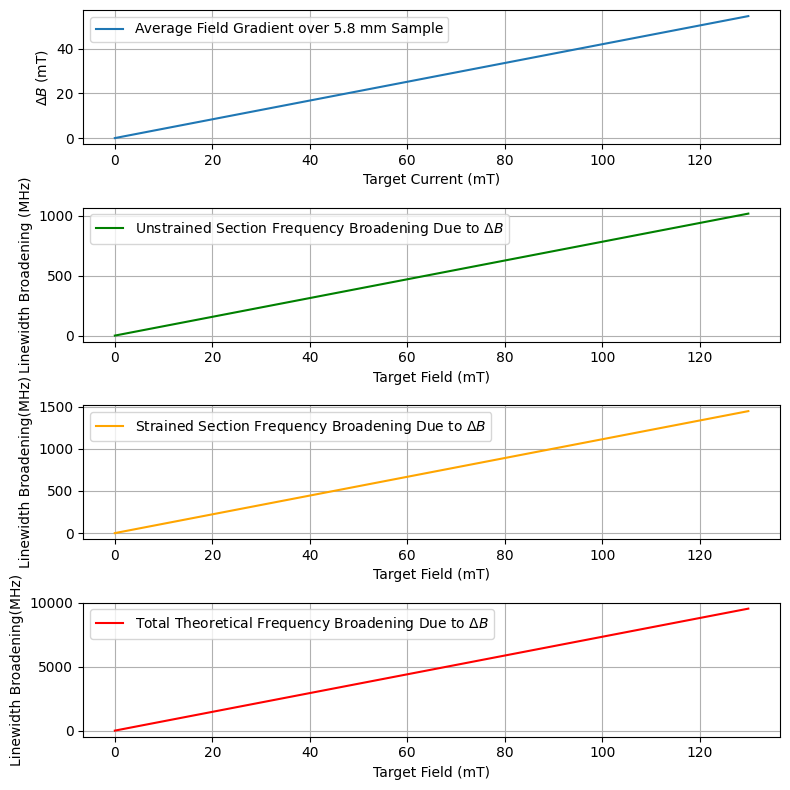

In [22]:
## Plot ## 
target_fields=np.arange(0,140,10)

delta_B_1, delta_f_strained_1, delta_f_unstrained_1 = calculate_homogeneity_features(target_fields, peak_data["A"]["slope"],peak_data["C"]["slope"] )
delta_B_2, delta_f_strained_2, delta_f_unstrained_2 = calculate_homogeneity_features(target_fields, peak_data["B"]["slope"],peak_data["D"]["slope"])
delta_B_av =[]
delta_f_strained_av =[]
delta_f_unstrained_av =[]
delta_f_theoretical =[]
g_estimate = 12.485805793985854
#g_estimate = 4.4

for i in range(0,len(target_fields)): 
    delta_B_av.append(np.average([delta_B_1[i], delta_B_2[i]]))
    delta_f_unstrained_av.append(np.average([delta_f_unstrained_1[i], delta_f_unstrained_2[i]]))
    delta_f_strained_av.append(np.average([delta_f_strained_1[i], delta_f_strained_2[i]]))
    delta_f_theoretical.append((muB/h)*g_estimate*delta_B_av[i]*10**(-3)/(10**9))


delta_f_theoretical= np.array(delta_f_theoretical)
delta_B_av =np.array(delta_B_av)
delta_f_strained_av =np.array(delta_f_strained_av)
delta_f_unstrained_av = np.array(delta_f_unstrained_av)
# delta_B_av= np.average([delta_B_1, delta_B_2])
# delta_f_strained_av = np.average([delta_f_strained_1, delta_f_strained_2])
# delta_f_unstrained_av = np.average([delta_f_unstrained_1, delta_f_unstrained_2])
coil_const_used = 3.57220371 # mT/A
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8,8 )) 
ax1.plot(target_fields, delta_B_av, label="Average Field Gradient over 5.8 mm Sample")
ax1.grid() 
ax1.set_xlabel(r"Target Current (mT)")
#ax1.set_xlabel(r"Target Field (mT)")
ax1.set_ylabel(r"$\Delta B$ (mT)")
ax1.legend()


ax2.plot(target_fields, delta_f_unstrained_av*1000,color ="green", label=r"Unstrained Section Frequency Broadening Due to $\Delta B$")
ax2.grid() 
ax2.set_xlabel(r"Target Field (mT)")
ax2.set_ylabel(r"Linewidth Broadening (MHz)")
ax2.legend()


ax3.plot(target_fields, delta_f_strained_av*1000, color="orange", label=r"Strained Section Frequency Broadening Due to $\Delta B$")
ax3.grid() 
ax3.set_xlabel(r"Target Field (mT)")
ax3.set_ylabel(r"Linewidth Broadening(MHz)")
ax3.legend()

ax4.plot(target_fields, delta_f_theoretical*1000, color="red", label=r"Total Theoretical Frequency Broadening Due to $\Delta B$")
ax4.grid() 
ax4.set_xlabel(r"Target Field (mT)")
ax4.set_ylabel(r"Linewidth Broadening(MHz)")
ax4.legend()
plt.tight_layout()

In [23]:
#Pecentage#
slope, intercept = calculate_slope(target_fields, delta_B_av,"delta B  v amp", units="mT/mT")
print("Field Variation across sample", slope*100, "%")

Slope of delta B  v amp: 0.420689 mT/mT, Intercept: -0.000000
Field Variation across sample 42.06893655962916 %


In [24]:
## COIL CONSTANT ## 
slope, intercept = calculate_slope(target_fields/coil_const_used, delta_B_av,"delta B  v amp", units="mT/A")
print("Max Coil Constant Estimate in Sample =", coil_const_used+slope/2, "mt/A")
print("Min Coil Constant Estimate in Sample =", coil_const_used-slope/2, "mT/A")

print("Coil Constant Field Variation across sample", slope/5.8, "mt/(A mm)")

Slope of delta B  v amp: 1.502788 mT/A, Intercept: -0.000000
Max Coil Constant Estimate in Sample = 4.32359776627031 mt/A
Min Coil Constant Estimate in Sample = 2.8208096537296905 mT/A
Coil Constant Field Variation across sample 0.2591013987138999 mt/(A mm)


In [25]:
def get_field_homogeneity_features(target_field, peak_data, g_estimate=12.485805793985854, muB=9.2740100783e-24, h=6.62607015e-34):
    """
    For a given target magnetic field (in mT), return average ΔB and expected frequency broadenings.
    """
    if not isinstance(target_field, (int, float)):
        raise ValueError("target_field must be a float or int representing field in mT")

    # Run homogeneity calculations for strained/unstrained peak pairs
    delta_B_1, delta_f_strained_1, delta_f_unstrained_1 = calculate_homogeneity_features(target_field, peak_data["A"]["slope"],peak_data["C"]["slope"] )
    delta_B_2, delta_f_strained_2, delta_f_unstrained_2 = calculate_homogeneity_features(target_field, peak_data["B"]["slope"],peak_data["D"]["slope"])

    # Compute averages
    delta_B_av = np.average([delta_B_1, delta_B_2])
    delta_f_strained_av = np.average([delta_f_strained_1, delta_f_strained_2])*1e9
    delta_f_unstrained_av = np.average([delta_f_unstrained_1, delta_f_unstrained_2])*1e9# convert to Hz 

    # Theoretical frequency broadening: Δf = (μB / h) * g * ΔB
    delta_f_theoretical = (muB / h) * g_estimate * delta_B_av * 1e-3  # convert mT → T
    return {
        "delta_B_av (mT)": delta_B_av,
        # "delta_f_unstrained (Hz)": delta_f_unstrained_av,
        # "delta_f_strained (Hz)": delta_f_strained_av,
        "delta_f_theoretical (Hz)": delta_f_theoretical
    }

target_field = 60.03
result = get_field_homogeneity_features(target_field, peak_data,g_estimate=4.4)
for key, val in result.items():
    if 'Hz' in key:
        print(f"{key}: {val/1e6:.3f} MHz")
    else:
        print(f"{key}: {val:.3f}")

delta_B_av (mT): 25.254
delta_f_theoretical (Hz): 1555.228 MHz


## Local Linewidth ##

90.69666666666669

--- Fitting Lorentzians at B = 0.09 mT ---
  Trying A at B = 90.696667 mT
    Guess: Gamma=0.3992, x0=-3.1016, scale=0.2073
    Bounds: [[np.float64(0.003991695305581757), np.float64(-3.1516333129999996), np.float64(0.020728703121871653)]], [[np.float64(0.3991695305581757), np.float64(-3.051633313), np.float64(0.2072870312187165)]]
  Trying B at B = 90.696667 mT
    Guess: Gamma=0.6209, x0=1.6440, scale=0.3528
    Bounds: [[np.float64(0.006209303808682769), np.float64(1.5940488836927649), np.float64(0.03527711486656417)]], [[np.float64(0.6209303808682769), np.float64(1.694048883692765), np.float64(0.3527711486656417)]]
  Trying C at B = 90.696667 mT
    Guess: Gamma=0.6653, x0=-3.7226, scale=0.2043
    Bounds: [[np.float64(0.006652825509302965), np.float64(-3.772563694), np.float64(0.02042844958940345)]], [[np.float64(0.6652825509302964), np.float64(-3.6725636940000004), np.float64(0.2042844958940345)]]
  Trying D at B = 90.696667 mT
    Guess: Gamma=1.3749, x0=-0.57

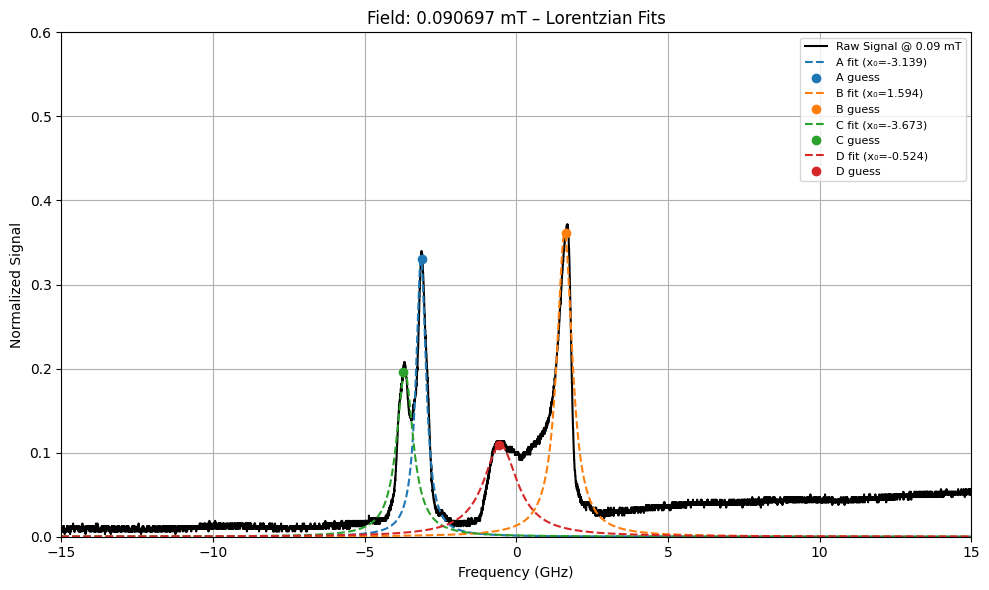

89.18

--- Fitting Lorentzians at B = 0.09 mT ---
  Trying A at B = 89.180000 mT
    Guess: Gamma=0.3992, x0=-3.1016, scale=0.2099
    Bounds: [[np.float64(0.003991695305581757), np.float64(-3.1516333129999996), np.float64(0.020991346574182432)]], [[np.float64(0.3991695305581757), np.float64(-3.051633313), np.float64(0.2099134657418243)]]
  Trying B at B = 89.180000 mT
    Guess: Gamma=0.5322, x0=1.5997, scale=0.3020
    Bounds: [[np.float64(0.005322260407442379), np.float64(1.5496967136307453), np.float64(0.030202001708554)]], [[np.float64(0.5322260407442378), np.float64(1.6496967136307454), np.float64(0.30202001708554)]]
  Trying C at B = 89.180000 mT
    Guess: Gamma=0.5322, x0=-3.6782, scale=0.1675
    Bounds: [[np.float64(0.005322260407442343), np.float64(-3.7282115239999998), np.float64(0.0167493237)]], [[np.float64(0.5322260407442343), np.float64(-3.628211524), np.float64(0.167493237)]]
  Trying D at B = 89.180000 mT
    Guess: Gamma=1.5080, x0=-0.6179, scale=0.2565
    Bounds: 

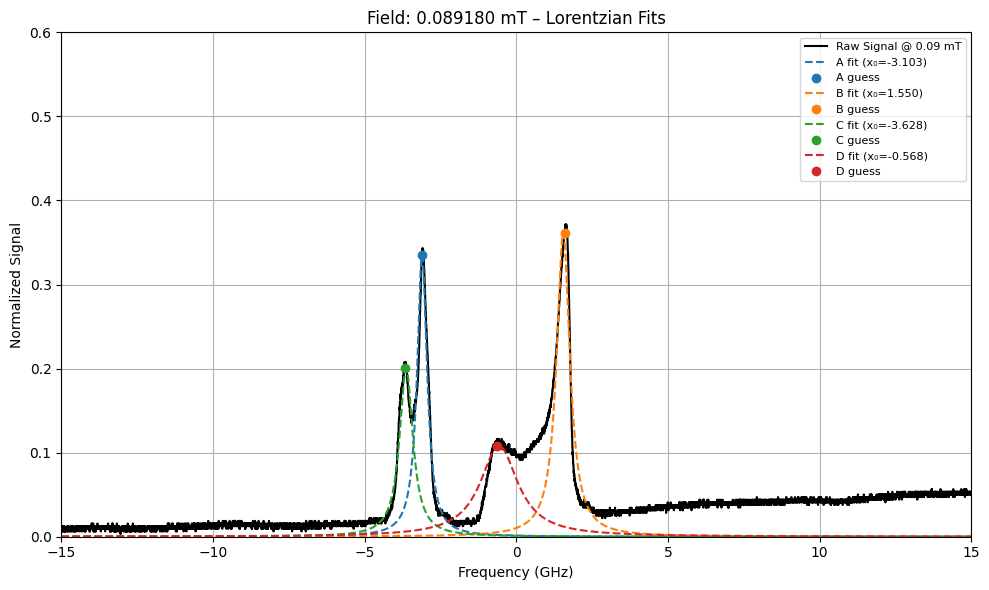

87.66333333333334

--- Fitting Lorentzians at B = 0.09 mT ---
  Trying A at B = 87.663333 mT
    Guess: Gamma=0.3548, x0=-3.0573, scale=0.1910
    Bounds: [[np.float64(0.003548173604961562), np.float64(-3.107281143), np.float64(0.019101452478489822)]], [[np.float64(0.3548173604961562), np.float64(-3.007281143), np.float64(0.1910145247848982)]]
  Trying B at B = 87.663333 mT
    Guess: Gamma=0.5766, x0=1.5997, scale=0.3336
    Bounds: [[np.float64(0.005765782108062574), np.float64(1.5496967136307453), np.float64(0.033355852767995596)]], [[np.float64(0.5765782108062574), np.float64(1.6496967136307454), np.float64(0.333558527679956)]]
  Trying C at B = 87.663333 mT
    Guess: Gamma=0.6209, x0=-3.6782, scale=0.1880
    Bounds: [[np.float64(0.006209303808682769), np.float64(-3.7282115239999998), np.float64(0.018804264065625423)]], [[np.float64(0.6209303808682769), np.float64(-3.628211524), np.float64(0.1880426406562542)]]
  Trying D at B = 87.663333 mT
    Guess: Gamma=1.4193, x0=-0.6179, s

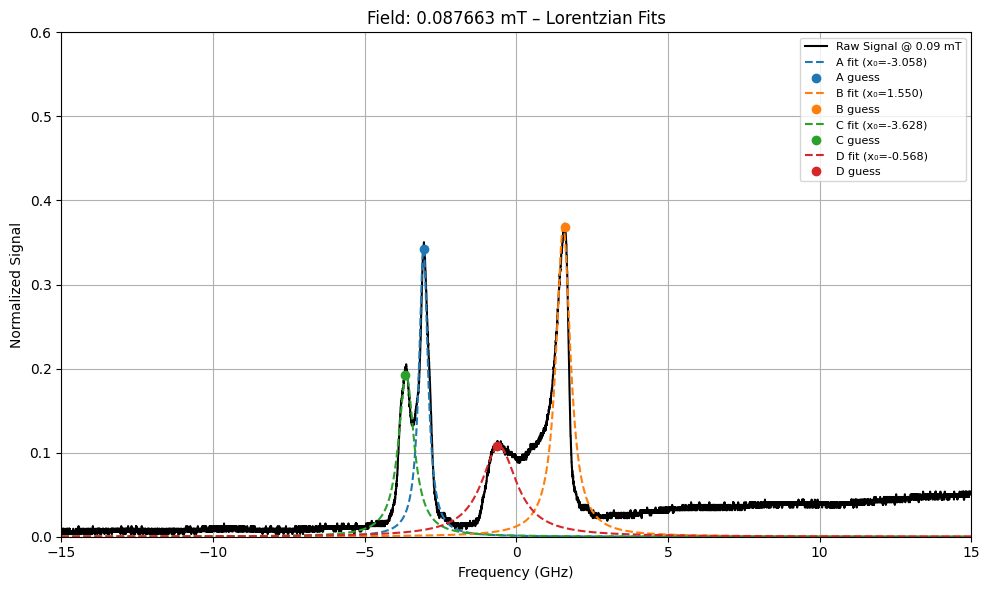

86.14666666666668

--- Fitting Lorentzians at B = 0.09 mT ---
  Trying A at B = 86.146667 mT
    Guess: Gamma=0.4435, x0=-3.0129, scale=0.2428
    Bounds: [[np.float64(0.004435217006201952), np.float64(-3.062928973), np.float64(0.02428421658319521)]], [[np.float64(0.4435217006201952), np.float64(-2.9629289730000004), np.float64(0.2428421658319521)]]
  Trying B at B = 86.146667 mT
    Guess: Gamma=0.6209, x0=1.5110, scale=0.3469
    Bounds: [[np.float64(0.006209303808682769), np.float64(1.4609923735067027), np.float64(0.03468536144015339)]], [[np.float64(0.6209303808682769), np.float64(1.5609923735067028), np.float64(0.3468536144015339)]]
  Trying C at B = 86.146667 mT
    Guess: Gamma=0.5766, x0=-3.6782, scale=0.1657
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.7282115239999998), np.float64(0.01657096871257217)]], [[np.float64(0.5765782108062574), np.float64(-3.628211524), np.float64(0.1657096871257217)]]
  Trying D at B = 86.146667 mT
    Guess: Gamma=1.5080, x0=-0.66

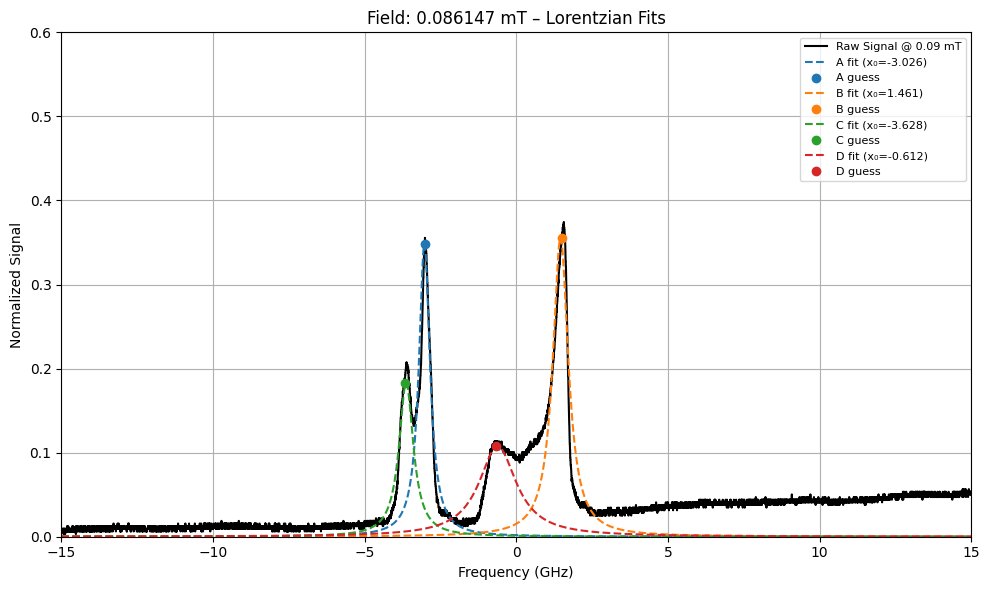

84.63000000000001

--- Fitting Lorentzians at B = 0.08 mT ---
  Trying A at B = 84.630000 mT
    Guess: Gamma=0.3548, x0=-2.9686, scale=0.1994
    Bounds: [[np.float64(0.003548173604961562), np.float64(-3.0185768029999998), np.float64(0.01994405640068628)]], [[np.float64(0.3548173604961562), np.float64(-2.918576803), np.float64(0.1994405640068628)]]
  Trying B at B = 84.630000 mT
    Guess: Gamma=0.6209, x0=1.4666, scale=0.3454
    Bounds: [[np.float64(0.006209303808682769), np.float64(1.4166402034446832), np.float64(0.03454227795096369)]], [[np.float64(0.6209303808682769), np.float64(1.5166402034446833), np.float64(0.3454227795096369)]]
  Trying C at B = 84.630000 mT
    Guess: Gamma=0.5322, x0=-3.5895, scale=0.1678
    Bounds: [[np.float64(0.005322260407442379), np.float64(-3.6395071839999997), np.float64(0.01677992424404636)]], [[np.float64(0.5322260407442378), np.float64(-3.539507184), np.float64(0.1677992424404636)]]
  Trying D at B = 84.630000 mT
    Guess: Gamma=1.5080, x0=-0.70

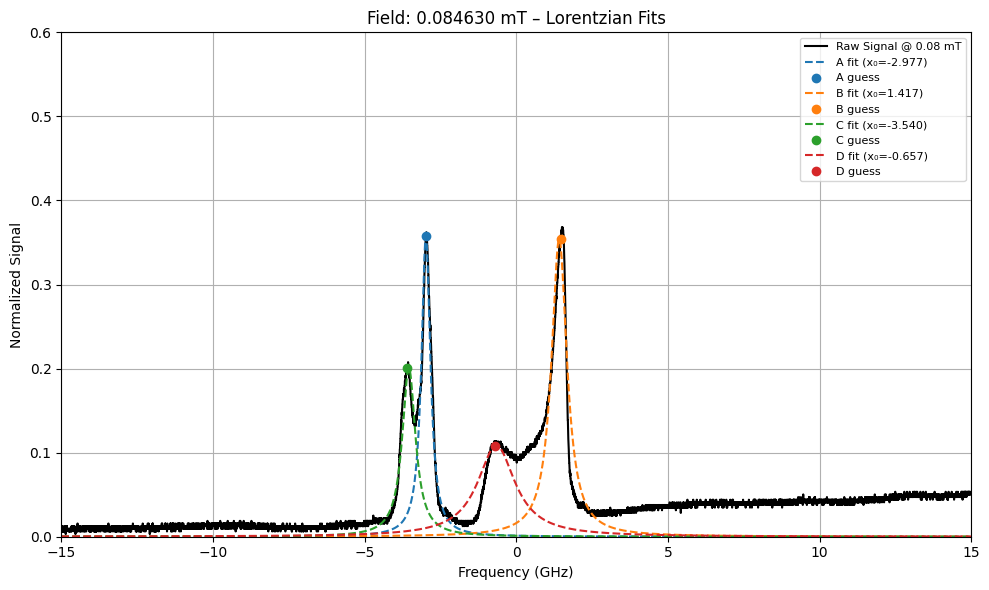

83.11333333333334

--- Fitting Lorentzians at B = 0.08 mT ---
  Trying A at B = 83.113333 mT
    Guess: Gamma=0.4435, x0=-2.9242, scale=0.2516
    Bounds: [[np.float64(0.004435217006201952), np.float64(-2.974224633), np.float64(0.02515784040408864)]], [[np.float64(0.4435217006201952), np.float64(-2.8742246330000003), np.float64(0.2515784040408864)]]
  Trying B at B = 83.113333 mT
    Guess: Gamma=0.6209, x0=1.4666, scale=0.3554
    Bounds: [[np.float64(0.006209303808682769), np.float64(1.4166402034446832), np.float64(0.03554447238209289)]], [[np.float64(0.6209303808682769), np.float64(1.5166402034446833), np.float64(0.3554447238209289)]]
  Trying C at B = 83.113333 mT
    Guess: Gamma=0.5766, x0=-3.5895, scale=0.1785
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.6395071839999997), np.float64(0.01785324065782698)]], [[np.float64(0.5765782108062574), np.float64(-3.539507184), np.float64(0.1785324065782698)]]
  Trying D at B = 83.113333 mT
    Guess: Gamma=1.3749, x0=-0.70

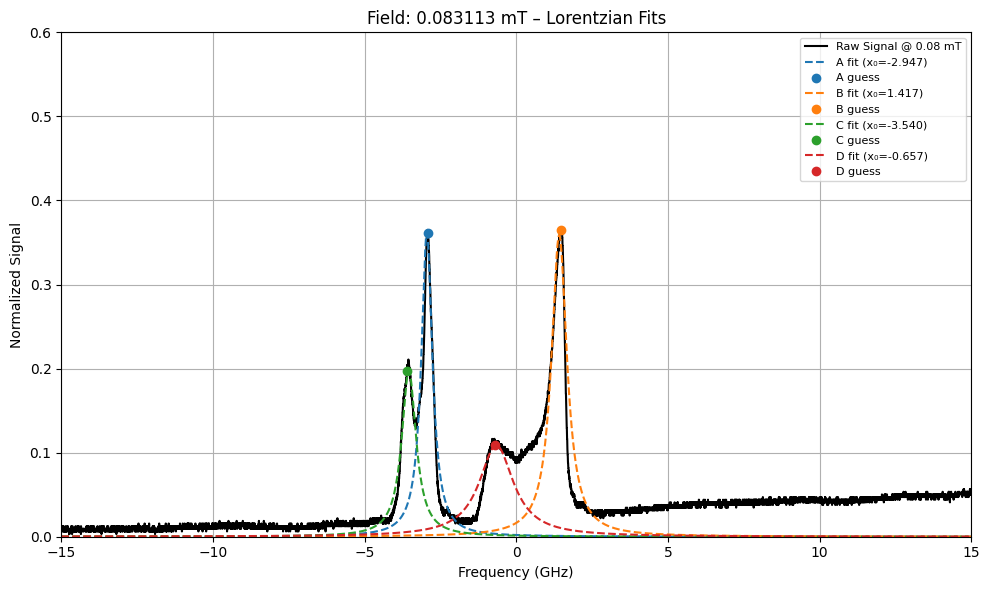

81.59666666666668

--- Fitting Lorentzians at B = 0.08 mT ---
  Trying A at B = 81.596667 mT
    Guess: Gamma=0.3992, x0=-2.9242, scale=0.2157
    Bounds: [[np.float64(0.003991695305581757), np.float64(-2.974224633), np.float64(0.02156809843558131)]], [[np.float64(0.3991695305581757), np.float64(-2.8742246330000003), np.float64(0.2156809843558131)]]
  Trying B at B = 81.596667 mT
    Guess: Gamma=0.5766, x0=1.3779, scale=0.3164
    Bounds: [[np.float64(0.005765782108062574), np.float64(1.3279358633206442), np.float64(0.031639019318035026)]], [[np.float64(0.5765782108062574), np.float64(1.4279358633206443), np.float64(0.3163901931803503)]]
  Trying C at B = 81.596667 mT
    Guess: Gamma=0.5322, x0=-3.5452, scale=0.1672
    Bounds: [[np.float64(0.005322260407442379), np.float64(-3.595155014), np.float64(0.01671919215902853)]], [[np.float64(0.5322260407442378), np.float64(-3.4951550140000003), np.float64(0.1671919215902853)]]
  Trying D at B = 81.596667 mT
    Guess: Gamma=1.3306, x0=-0.7

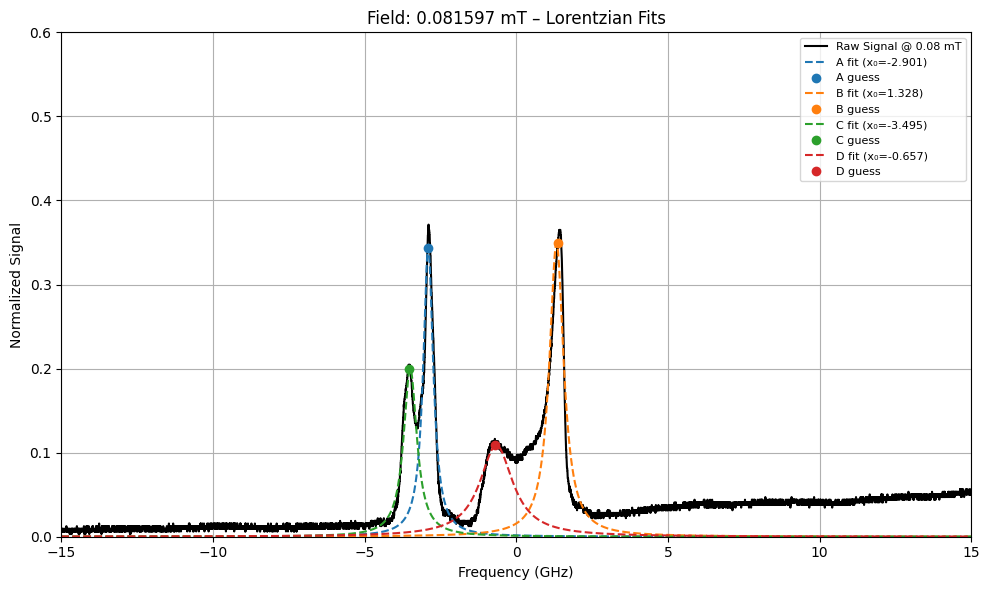

80.08

--- Fitting Lorentzians at B = 0.08 mT ---
  Trying A at B = 80.080000 mT
    Guess: Gamma=0.3548, x0=-2.8799, scale=0.1978
    Bounds: [[np.float64(0.003548173604961562), np.float64(-2.9298724629999997), np.float64(0.01977737695275215)]], [[np.float64(0.3548173604961562), np.float64(-2.829872463), np.float64(0.1977737695275215)]]
  Trying B at B = 80.080000 mT
    Guess: Gamma=0.6653, x0=1.4666, scale=0.3369
    Bounds: [[np.float64(0.006652825509302965), np.float64(1.4166402034446832), np.float64(0.03369433787179426)]], [[np.float64(0.6652825509302964), np.float64(1.5166402034446833), np.float64(0.3369433787179426)]]
  Trying C at B = 80.080000 mT
    Guess: Gamma=0.6653, x0=-3.5895, scale=0.1907
    Bounds: [[np.float64(0.006652825509302965), np.float64(-3.6395071839999997), np.float64(0.019074836129796182)]], [[np.float64(0.6652825509302964), np.float64(-3.539507184), np.float64(0.1907483612979618)]]
  Trying D at B = 80.080000 mT
    Guess: Gamma=1.3306, x0=-0.7953, scale=0

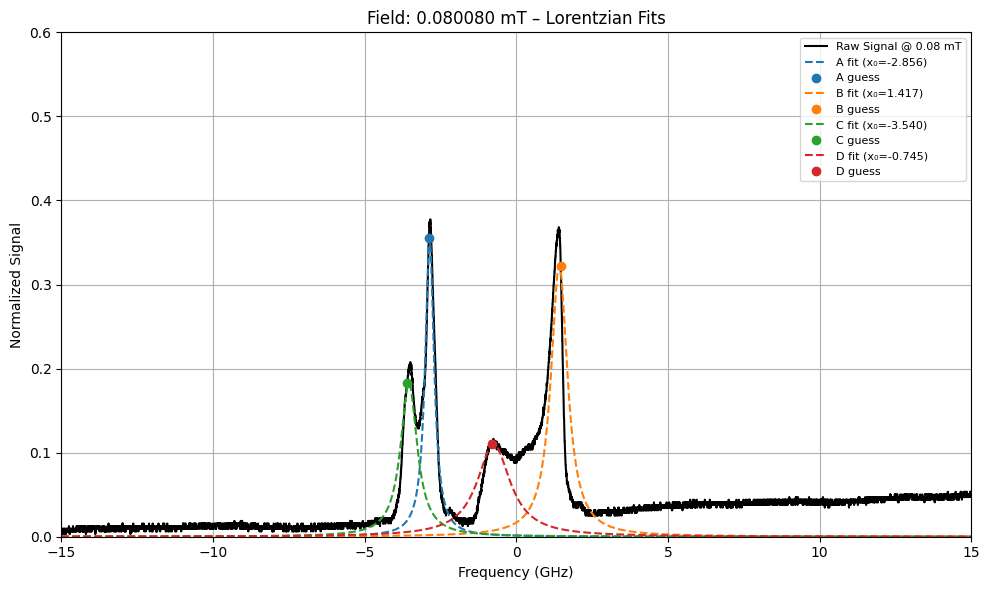

78.56333333333333

--- Fitting Lorentzians at B = 0.08 mT ---
  Trying A at B = 78.563333 mT
    Guess: Gamma=0.3992, x0=-2.7912, scale=0.2345
    Bounds: [[np.float64(0.003991695305581757), np.float64(-2.8411681229999997), np.float64(0.023452947562972042)]], [[np.float64(0.3991695305581757), np.float64(-2.741168123), np.float64(0.2345294756297204)]]
  Trying B at B = 78.563333 mT
    Guess: Gamma=0.6209, x0=1.3336, scale=0.3524
    Bounds: [[np.float64(0.006209303808682734), np.float64(1.2835836932586246), np.float64(0.03523838717590377)]], [[np.float64(0.6209303808682733), np.float64(1.3835836932586247), np.float64(0.3523838717590377)]]
  Trying C at B = 78.563333 mT
    Guess: Gamma=0.6209, x0=-3.5008, scale=0.1941
    Bounds: [[np.float64(0.006209303808682769), np.float64(-3.5508028439999997), np.float64(0.01941465657286238)]], [[np.float64(0.6209303808682769), np.float64(-3.450802844), np.float64(0.1941465657286238)]]
  Trying D at B = 78.563333 mT
    Guess: Gamma=1.4193, x0=-0.8

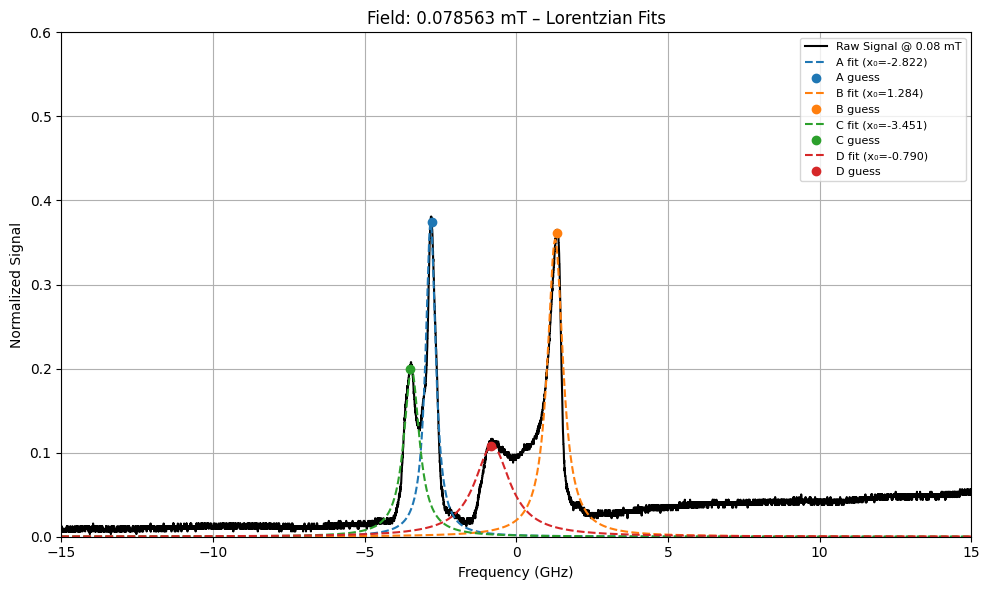

77.04666666666667

--- Fitting Lorentzians at B = 0.08 mT ---
  Trying A at B = 77.046667 mT
    Guess: Gamma=0.3992, x0=-2.7912, scale=0.2345
    Bounds: [[np.float64(0.003991695305581757), np.float64(-2.8411681229999997), np.float64(0.02345297353962531)]], [[np.float64(0.3991695305581757), np.float64(-2.741168123), np.float64(0.2345297353962531)]]
  Trying B at B = 77.046667 mT
    Guess: Gamma=0.5766, x0=1.2449, scale=0.3098
    Bounds: [[np.float64(0.005765782108062539), np.float64(1.1948793531345856), np.float64(0.03098126198655235)]], [[np.float64(0.5765782108062538), np.float64(1.2948793531345857), np.float64(0.3098126198655235)]]
  Trying C at B = 77.046667 mT
    Guess: Gamma=0.5766, x0=-3.4565, scale=0.1830
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.506450673), np.float64(0.01830186276199832)]], [[np.float64(0.5765782108062574), np.float64(-3.406450673), np.float64(0.1830186276199832)]]
  Trying D at B = 77.046667 mT
    Guess: Gamma=1.3749, x0=-0.8397, sca

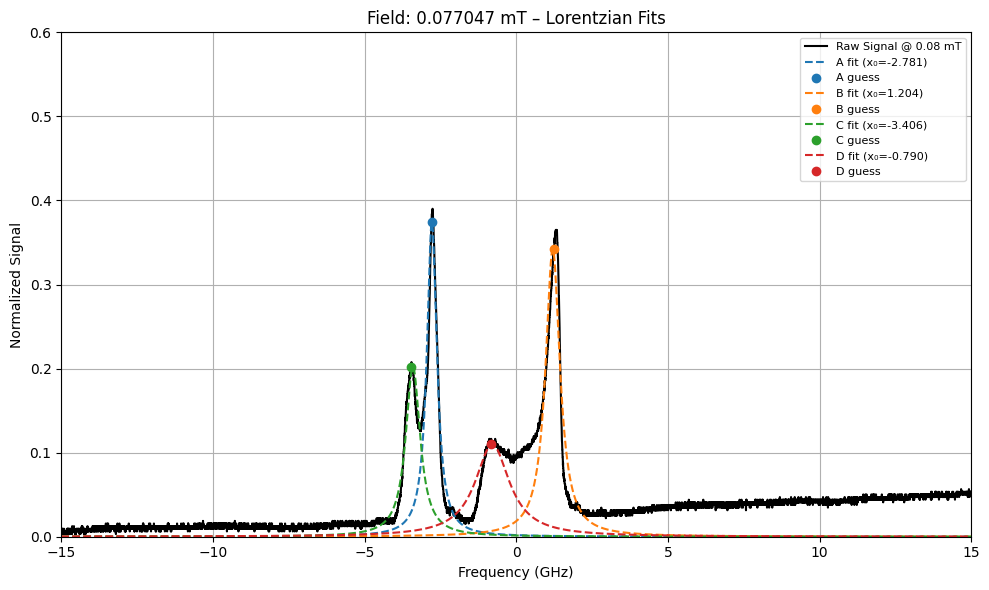

75.53

--- Fitting Lorentzians at B = 0.08 mT ---
  Trying A at B = 75.530000 mT
    Guess: Gamma=0.3548, x0=-2.7468, scale=0.2120
    Bounds: [[np.float64(0.003548173604961597), np.float64(-2.7968159519999998), np.float64(0.02120223437594661)]], [[np.float64(0.3548173604961597), np.float64(-2.696815952), np.float64(0.2120223437594661)]]
  Trying B at B = 75.530000 mT
    Guess: Gamma=0.6209, x0=1.2449, scale=0.3488
    Bounds: [[np.float64(0.006209303808682734), np.float64(1.1948793531345856), np.float64(0.0348811577)]], [[np.float64(0.6209303808682733), np.float64(1.2948793531345857), np.float64(0.348811577)]]
  Trying C at B = 75.530000 mT
    Guess: Gamma=0.6653, x0=-3.4565, scale=0.2052
    Bounds: [[np.float64(0.006652825509302965), np.float64(-3.506450673), np.float64(0.020523864024752782)]], [[np.float64(0.6652825509302964), np.float64(-3.406450673), np.float64(0.2052386402475278)]]
  Trying D at B = 75.530000 mT
    Guess: Gamma=1.4193, x0=-0.9284, scale=0.2390
    Bounds: [[n

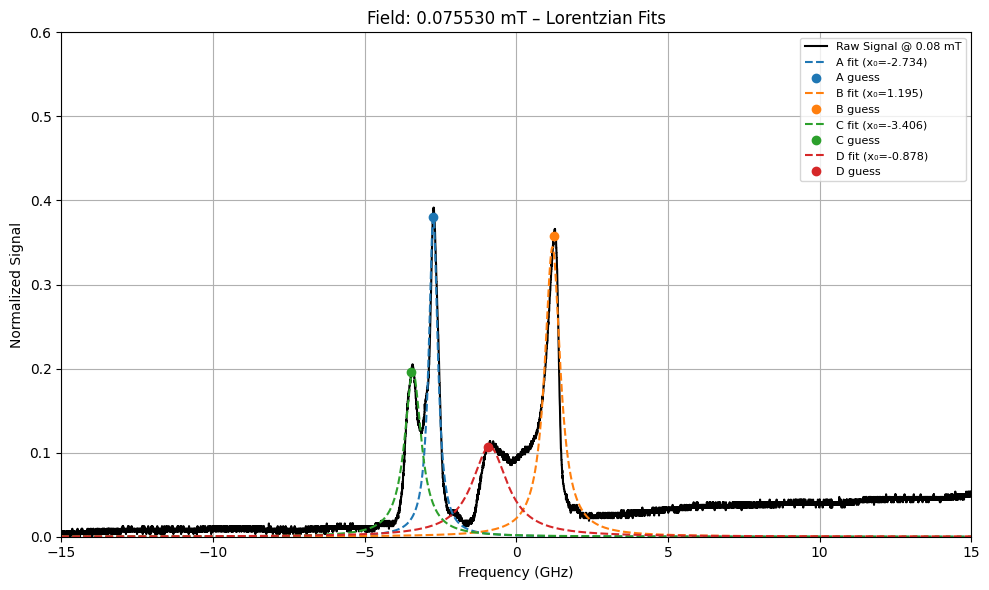

74.01333333333334

--- Fitting Lorentzians at B = 0.07 mT ---
  Trying A at B = 74.013333 mT
    Guess: Gamma=0.3992, x0=-2.7025, scale=0.2447
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-2.752463782), np.float64(0.024471899764343993)]], [[np.float64(0.3991695305581793), np.float64(-2.6524637820000003), np.float64(0.2447189976434399)]]
  Trying B at B = 74.013333 mT
    Guess: Gamma=0.4879, x0=1.1562, scale=0.2566
    Bounds: [[np.float64(0.004878738706822147), np.float64(1.1061750130105465), np.float64(0.025661123690143825)]], [[np.float64(0.4878738706822147), np.float64(1.2061750130105466), np.float64(0.2566112369014382)]]
  Trying C at B = 74.013333 mT
    Guess: Gamma=0.5766, x0=-3.4565, scale=0.1699
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.506450673), np.float64(0.01698776432130724)]], [[np.float64(0.5765782108062574), np.float64(-3.406450673), np.float64(0.1698776432130724)]]
  Trying D at B = 74.013333 mT
    Guess: Gamma=1.3306, x0=-0.8840, 

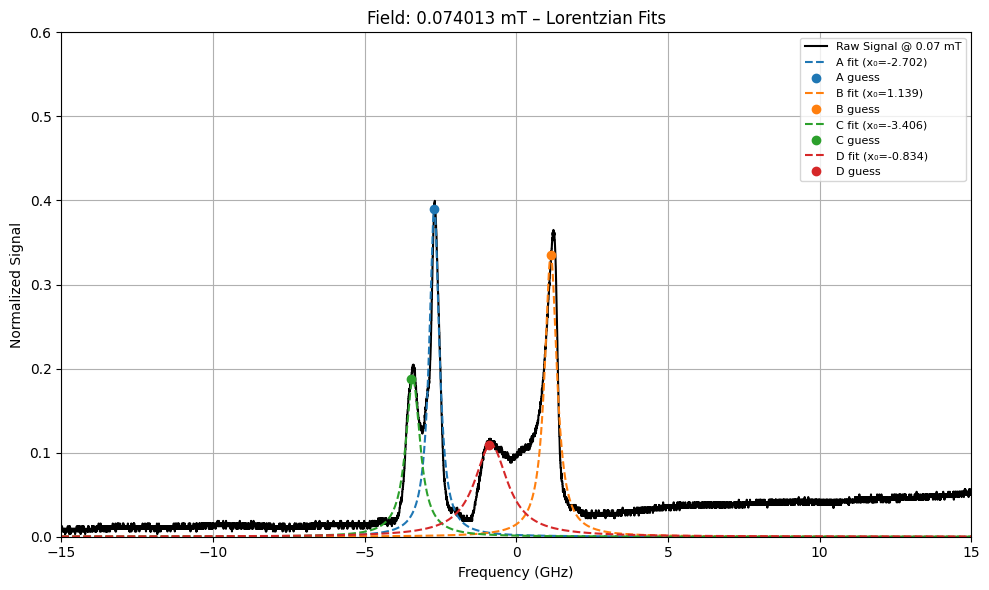

72.49666666666667

--- Fitting Lorentzians at B = 0.07 mT ---
  Trying A at B = 72.496667 mT
    Guess: Gamma=0.3548, x0=-2.6581, scale=0.2195
    Bounds: [[np.float64(0.003548173604961597), np.float64(-2.7081116119999997), np.float64(0.02195309266374225)]], [[np.float64(0.3548173604961597), np.float64(-2.608111612), np.float64(0.2195309266374225)]]
  Trying B at B = 72.496667 mT
    Guess: Gamma=0.5766, x0=1.2005, scale=0.3251
    Bounds: [[np.float64(0.005765782108062539), np.float64(1.1505271830725659), np.float64(0.032508101311110385)]], [[np.float64(0.5765782108062538), np.float64(1.250527183072566), np.float64(0.3250810131111038)]]
  Trying C at B = 72.496667 mT
    Guess: Gamma=0.5766, x0=-3.3677, scale=0.1808
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.4177463329999997), np.float64(0.01807580535828629)]], [[np.float64(0.5765782108062574), np.float64(-3.317746333), np.float64(0.1807580535828629)]]
  Trying D at B = 72.496667 mT
    Guess: Gamma=1.3749, x0=-0.92

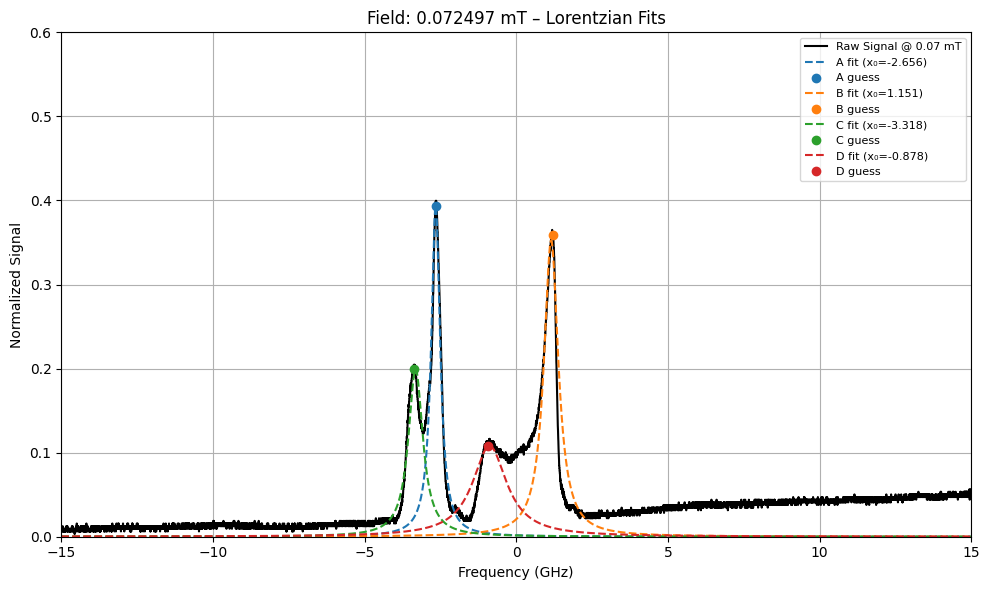

70.98

--- Fitting Lorentzians at B = 0.07 mT ---
  Trying A at B = 70.980000 mT
    Guess: Gamma=0.3548, x0=-2.6138, scale=0.2219
    Bounds: [[np.float64(0.003548173604961597), np.float64(-2.663759442), np.float64(0.02218784533515367)]], [[np.float64(0.3548173604961597), np.float64(-2.5637594420000003), np.float64(0.2218784533515367)]]
  Trying B at B = 70.980000 mT
    Guess: Gamma=0.5766, x0=1.1118, scale=0.3180
    Bounds: [[np.float64(0.005765782108062539), np.float64(1.061822842948527), np.float64(0.0317989159419719)]], [[np.float64(0.5765782108062538), np.float64(1.1618228429485271), np.float64(0.317989159419719)]]
  Trying C at B = 70.980000 mT
    Guess: Gamma=0.6653, x0=-3.3234, scale=0.2074
    Bounds: [[np.float64(0.006652825509302965), np.float64(-3.373394163), np.float64(0.02073635945624785)]], [[np.float64(0.6652825509302964), np.float64(-3.2733941630000003), np.float64(0.2073635945624785)]]
  Trying D at B = 70.980000 mT
    Guess: Gamma=1.4636, x0=-0.9727, scale=0.255

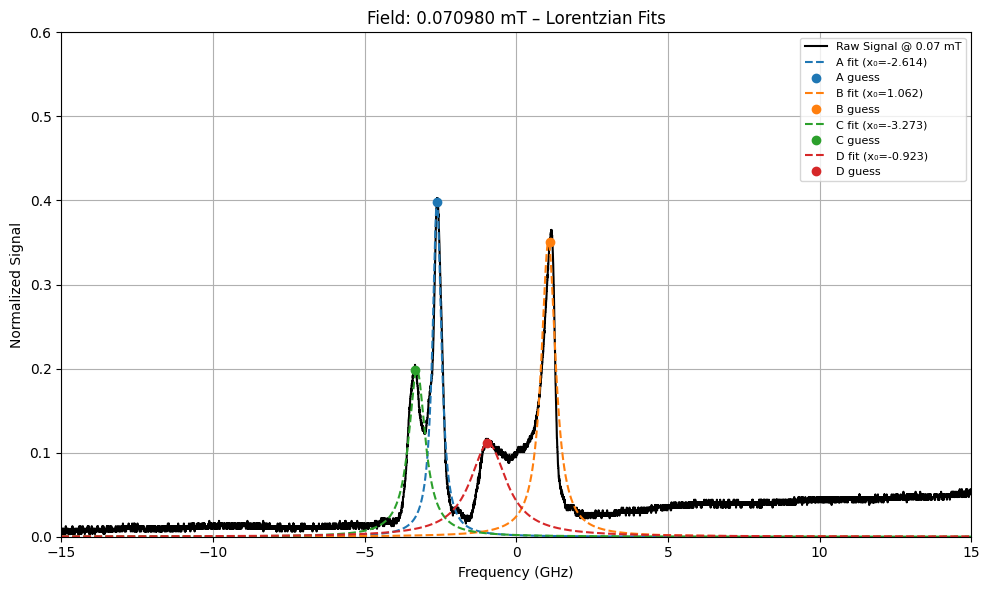

69.46333333333334

--- Fitting Lorentzians at B = 0.07 mT ---
  Trying A at B = 69.463333 mT
    Guess: Gamma=0.3992, x0=-2.5694, scale=0.2538
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-2.6194072719999997), np.float64(0.02538104374662875)]], [[np.float64(0.3991695305581793), np.float64(-2.519407272), np.float64(0.2538104374662875)]]
  Trying B at B = 69.463333 mT
    Guess: Gamma=0.5766, x0=1.0675, scale=0.3157
    Bounds: [[np.float64(0.005765782108062574), np.float64(1.0174706728865075), np.float64(0.031572006624685615)]], [[np.float64(0.5765782108062574), np.float64(1.1174706728865076), np.float64(0.3157200662468561)]]
  Trying C at B = 69.463333 mT
    Guess: Gamma=0.6653, x0=-3.3677, scale=0.1988
    Bounds: [[np.float64(0.006652825509302965), np.float64(-3.4177463329999997), np.float64(0.01988272142827244)]], [[np.float64(0.6652825509302964), np.float64(-3.317746333), np.float64(0.1988272142827244)]]
  Trying D at B = 69.463333 mT
    Guess: Gamma=1.3306, x0=-0.

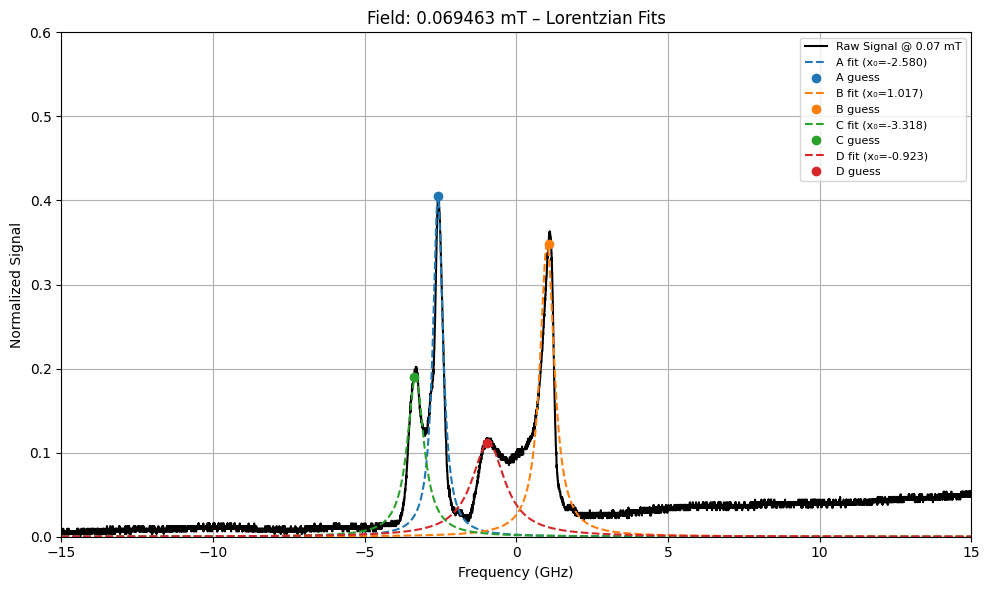

67.94666666666667

--- Fitting Lorentzians at B = 0.07 mT ---
  Trying A at B = 67.946667 mT
    Guess: Gamma=0.3548, x0=-2.5694, scale=0.2094
    Bounds: [[np.float64(0.003548173604961597), np.float64(-2.6194072719999997), np.float64(0.020936884867850183)]], [[np.float64(0.3548173604961597), np.float64(-2.519407272), np.float64(0.2093688486785018)]]
  Trying B at B = 67.946667 mT
    Guess: Gamma=0.5322, x0=1.0231, scale=0.2888
    Bounds: [[np.float64(0.005322260407442379), np.float64(0.973118502824488), np.float64(0.028875542977376142)]], [[np.float64(0.5322260407442378), np.float64(1.073118502824488), np.float64(0.2887554297737614)]]
  Trying C at B = 67.946667 mT
    Guess: Gamma=0.5766, x0=-3.3677, scale=0.1659
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.4177463329999997), np.float64(0.01659400562567213)]], [[np.float64(0.5765782108062574), np.float64(-3.317746333), np.float64(0.1659400562567213)]]
  Trying D at B = 67.946667 mT
    Guess: Gamma=1.2862, x0=-0.97

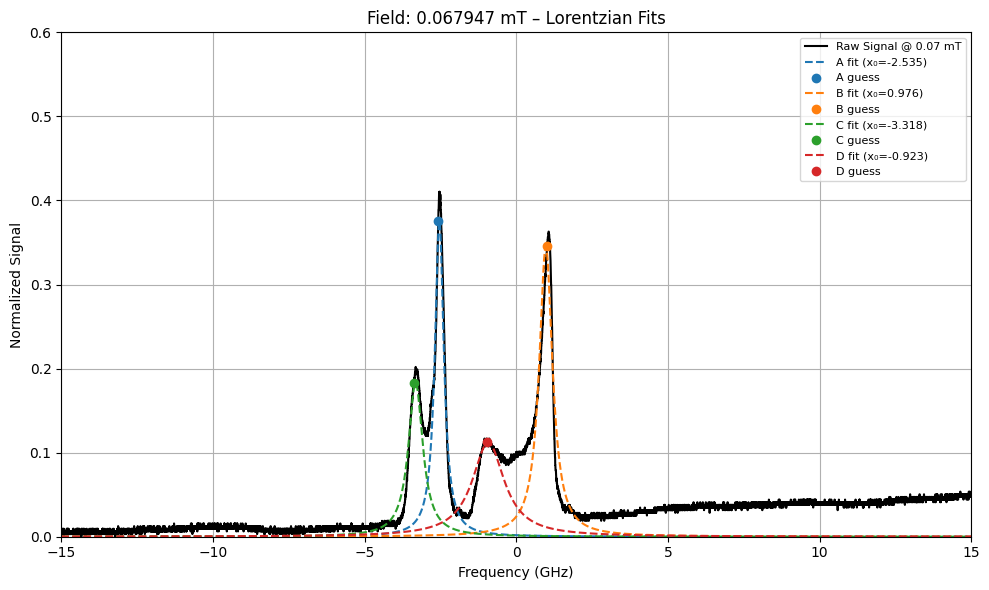

66.43

--- Fitting Lorentzians at B = 0.07 mT ---
  Trying A at B = 66.430000 mT
    Guess: Gamma=0.3992, x0=-2.5251, scale=0.2409
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-2.575055102), np.float64(0.02409379473615042)]], [[np.float64(0.3991695305581793), np.float64(-2.4750551020000002), np.float64(0.2409379473615042)]]
  Trying B at B = 66.430000 mT
    Guess: Gamma=0.0000, x0=1.0231, scale=0.0000
    Bounds: [[np.float64(0.0), np.float64(0.973118502824488), np.float64(0.0)]], [[np.float64(0.0), np.float64(1.073118502824488), np.float64(0.0)]]
Fit failed for B at B = 0.07 mT: Each lower bound must be strictly less than each upper bound.
  Trying C at B = 66.430000 mT
    Guess: Gamma=0.5766, x0=-3.2790, scale=0.1767
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.3290419929999997), np.float64(0.01767099052533995)]], [[np.float64(0.5765782108062574), np.float64(-3.229041993), np.float64(0.1767099052533995)]]
  Trying D at B = 66.430000 mT
    Guess: Gam

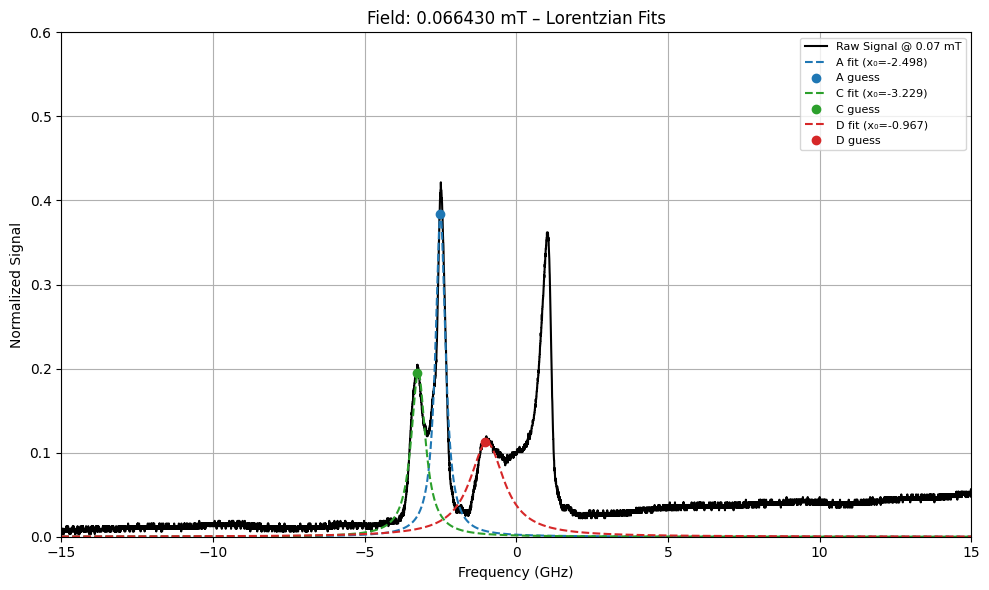

64.91333333333334

--- Fitting Lorentzians at B = 0.06 mT ---
  Trying A at B = 64.913333 mT
    Guess: Gamma=0.3548, x0=-2.4807, scale=0.2199
    Bounds: [[np.float64(0.003548173604961597), np.float64(-2.5307029319999996), np.float64(0.02198842841307823)]], [[np.float64(0.3548173604961597), np.float64(-2.430702932), np.float64(0.2198842841307823)]]
  Trying B at B = 64.913333 mT
    Guess: Gamma=0.5322, x0=1.0231, scale=0.2919
    Bounds: [[np.float64(0.005322260407442379), np.float64(0.973118502824488), np.float64(0.02918898932392699)]], [[np.float64(0.5322260407442378), np.float64(1.073118502824488), np.float64(0.2918898932392699)]]
  Trying C at B = 64.913333 mT
    Guess: Gamma=0.6209, x0=-3.3234, scale=0.1746
    Bounds: [[np.float64(0.006209303808682769), np.float64(-3.373394163), np.float64(0.0174591584)]], [[np.float64(0.6209303808682769), np.float64(-3.2733941630000003), np.float64(0.174591584)]]
  Trying D at B = 64.913333 mT
    Guess: Gamma=1.5080, x0=-1.1058, scale=0.2615

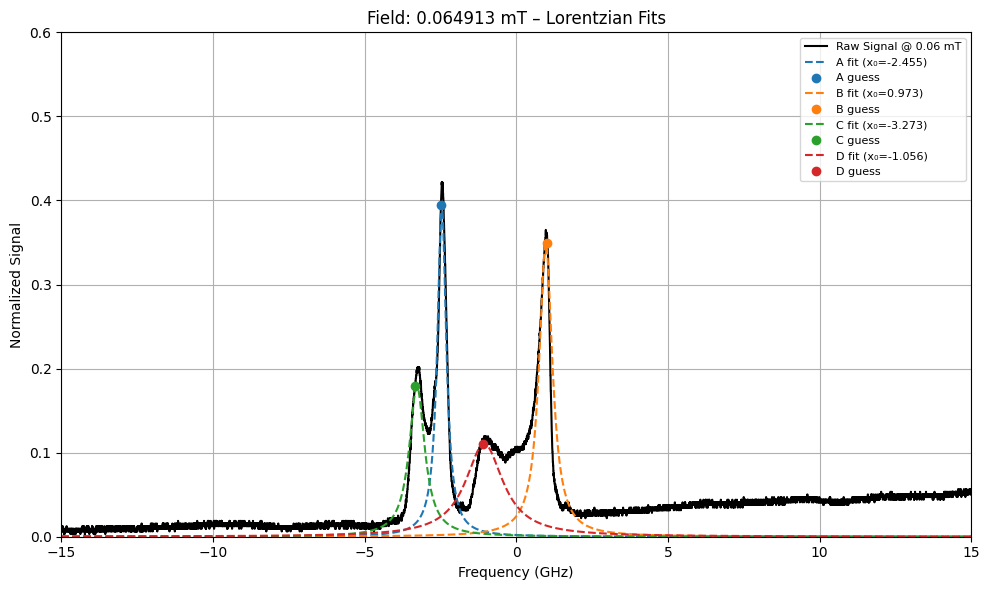

63.39666666666667

--- Fitting Lorentzians at B = 0.06 mT ---
  Trying A at B = 63.396667 mT
    Guess: Gamma=0.2661, x0=-2.4807, scale=0.1414
    Bounds: [[np.float64(0.0026611302037212073), np.float64(-2.5307029319999996), np.float64(0.01414233826399177)]], [[np.float64(0.2661130203721207), np.float64(-2.430702932), np.float64(0.1414233826399177)]]
  Trying B at B = 63.396667 mT
    Guess: Gamma=0.4879, x0=0.8901, scale=0.2591
    Bounds: [[np.float64(0.004878738706822184), np.float64(0.8400619926384294), np.float64(0.02591415681671516)]], [[np.float64(0.4878738706822183), np.float64(0.9400619926384295), np.float64(0.2591415681671516)]]
  Trying C at B = 63.396667 mT
    Guess: Gamma=0.5766, x0=-3.2347, scale=0.1762
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.284689823), np.float64(0.01762410817729021)]], [[np.float64(0.5765782108062574), np.float64(-3.1846898230000003), np.float64(0.1762410817729021)]]
  Trying D at B = 63.396667 mT
    Guess: Gamma=1.3749, x0=-1.0

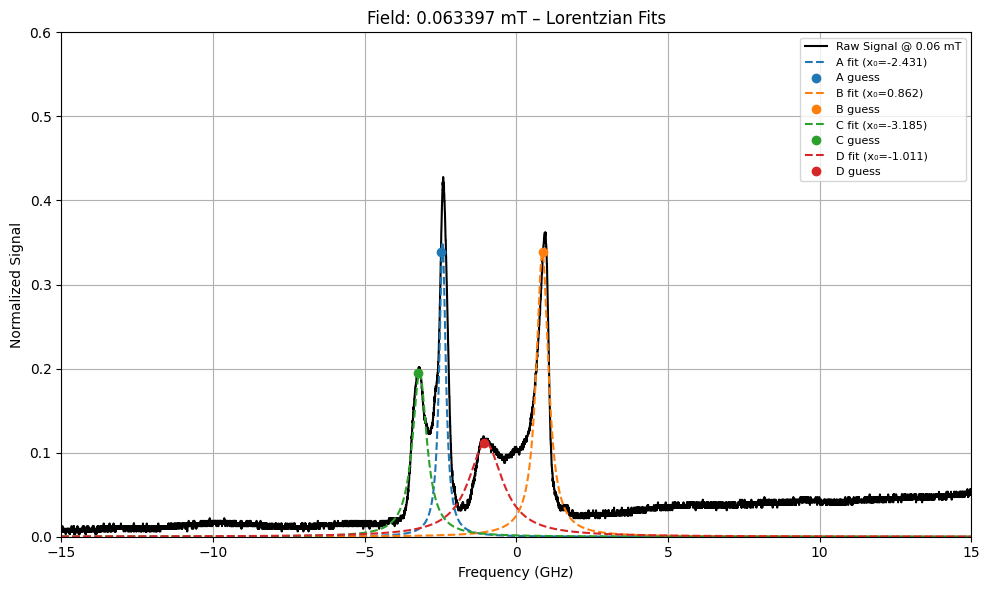

61.88

--- Fitting Lorentzians at B = 0.06 mT ---
  Trying A at B = 61.880000 mT
    Guess: Gamma=0.3548, x0=-2.3920, scale=0.2311
    Bounds: [[np.float64(0.003548173604961597), np.float64(-2.441998592), np.float64(0.023112749852974672)]], [[np.float64(0.3548173604961597), np.float64(-2.3419985920000004), np.float64(0.2311274985297467)]]
  Trying B at B = 61.880000 mT
    Guess: Gamma=0.5322, x0=0.8901, scale=0.2979
    Bounds: [[np.float64(0.005322260407442379), np.float64(0.8400619926384294), np.float64(0.02979415640589273)]], [[np.float64(0.5322260407442378), np.float64(0.9400619926384295), np.float64(0.2979415640589273)]]
  Trying C at B = 61.880000 mT
    Guess: Gamma=0.5322, x0=-3.1903, scale=0.1638
    Bounds: [[np.float64(0.005322260407442379), np.float64(-3.2403376529999997), np.float64(0.01638355691213293)]], [[np.float64(0.5322260407442378), np.float64(-3.140337653), np.float64(0.1638355691213293)]]
  Trying D at B = 61.880000 mT
    Guess: Gamma=1.4636, x0=-1.1058, scale=0

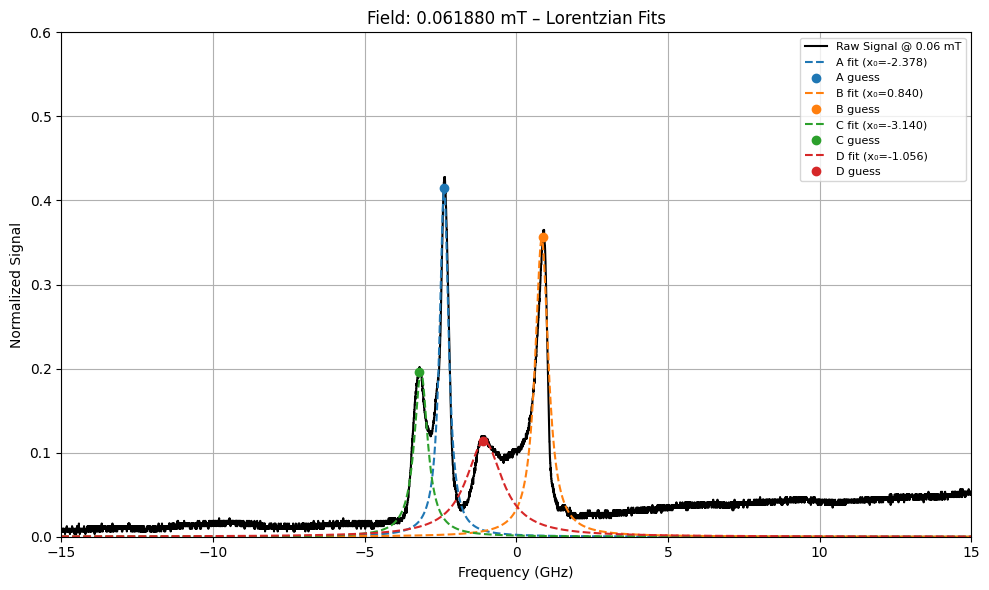

60.36333333333334

--- Fitting Lorentzians at B = 0.06 mT ---
  Trying A at B = 60.363333 mT
    Guess: Gamma=0.3992, x0=-2.3476, scale=0.2636
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-2.3976464219999998), np.float64(0.026358540838638613)]], [[np.float64(0.3991695305581793), np.float64(-2.297646422), np.float64(0.2635854083863861)]]
  Trying B at B = 60.363333 mT
    Guess: Gamma=0.4879, x0=0.8457, scale=0.2721
    Bounds: [[np.float64(0.004878738706822184), np.float64(0.7957098225764099), np.float64(0.02721031985262168)]], [[np.float64(0.4878738706822183), np.float64(0.89570982257641), np.float64(0.2721031985262168)]]
  Trying C at B = 60.363333 mT
    Guess: Gamma=0.6653, x0=-3.2347, scale=0.1907
    Bounds: [[np.float64(0.006652825509302965), np.float64(-3.284689823), np.float64(0.01906523733738482)]], [[np.float64(0.6652825509302964), np.float64(-3.1846898230000003), np.float64(0.1906523733738482)]]
  Trying D at B = 60.363333 mT
    Guess: Gamma=1.3306, x0=-1.15

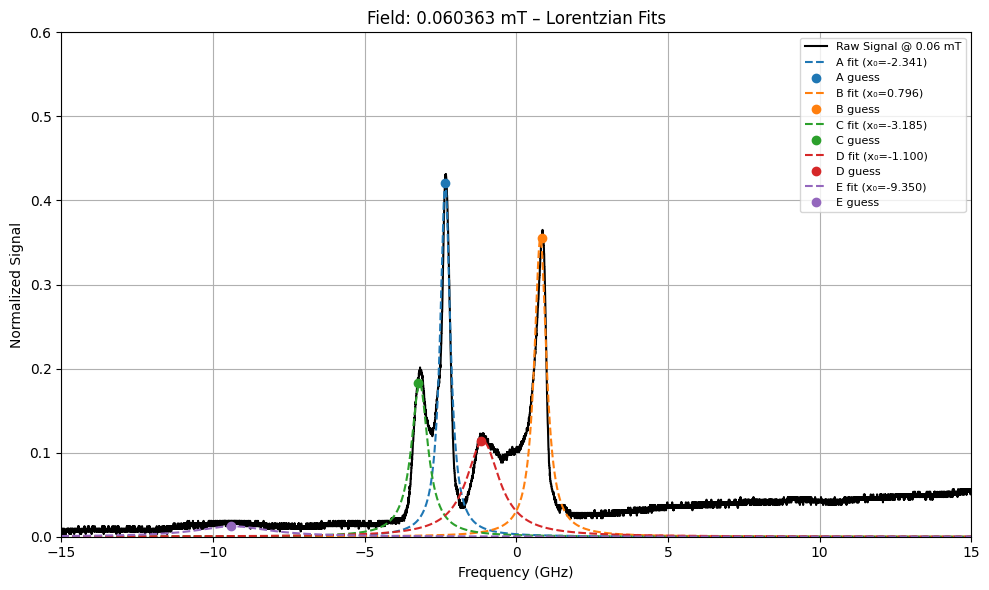

58.84666666666667

--- Fitting Lorentzians at B = 0.06 mT ---
  Trying A at B = 58.846667 mT
    Guess: Gamma=0.3548, x0=-2.3476, scale=0.2040
    Bounds: [[np.float64(0.003548173604961562), np.float64(-2.3976464219999998), np.float64(0.020396638808199672)]], [[np.float64(0.3548173604961562), np.float64(-2.297646422), np.float64(0.2039663880819967)]]
  Trying B at B = 58.846667 mT
    Guess: Gamma=0.4879, x0=0.8014, scale=0.2698
    Bounds: [[np.float64(0.004878738706822184), np.float64(0.7513576525143904), np.float64(0.02697701540432161)]], [[np.float64(0.4878738706822183), np.float64(0.8513576525143904), np.float64(0.2697701540432161)]]
  Trying C at B = 58.846667 mT
    Guess: Gamma=0.5766, x0=-3.1460, scale=0.1754
    Bounds: [[np.float64(0.005765782108062574), np.float64(-3.195985483), np.float64(0.017535140060008638)]], [[np.float64(0.5765782108062574), np.float64(-3.095985483), np.float64(0.1753514006000864)]]
  Trying D at B = 58.846667 mT
    Guess: Gamma=1.4636, x0=-1.2388, s

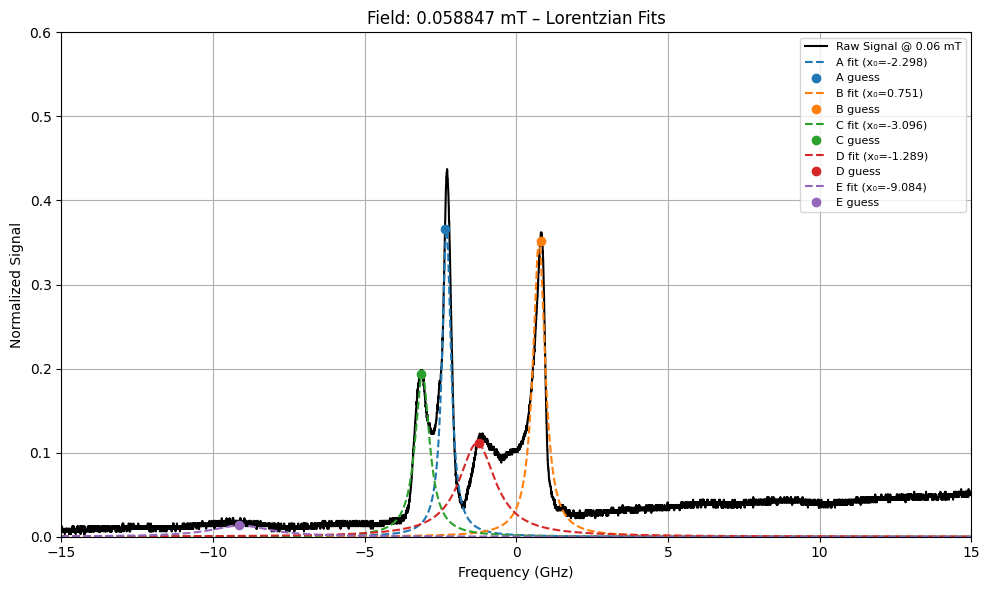

57.330000000000005

--- Fitting Lorentzians at B = 0.06 mT ---
  Trying A at B = 57.330000 mT
    Guess: Gamma=0.2661, x0=-2.2589, scale=0.1801
    Bounds: [[np.float64(0.002661130203721171), np.float64(-2.3089420819999997), np.float64(0.018007993400000002)]], [[np.float64(0.2661130203721171), np.float64(-2.208942082), np.float64(0.180079934)]]
  Trying B at B = 57.330000 mT
    Guess: Gamma=0.4879, x0=0.7570, scale=0.2687
    Bounds: [[np.float64(0.004878738706822184), np.float64(0.7070054824523708), np.float64(0.02687371425578196)]], [[np.float64(0.4878738706822183), np.float64(0.8070054824523709), np.float64(0.2687371425578196)]]
  Trying C at B = 57.330000 mT
    Guess: Gamma=0.5322, x0=-3.1460, scale=0.1587
    Bounds: [[np.float64(0.005322260407442379), np.float64(-3.195985483), np.float64(0.015865646389796022)]], [[np.float64(0.5322260407442378), np.float64(-3.095985483), np.float64(0.1586564638979602)]]
  Trying D at B = 57.330000 mT
    Guess: Gamma=1.3306, x0=-1.1945, scale=0

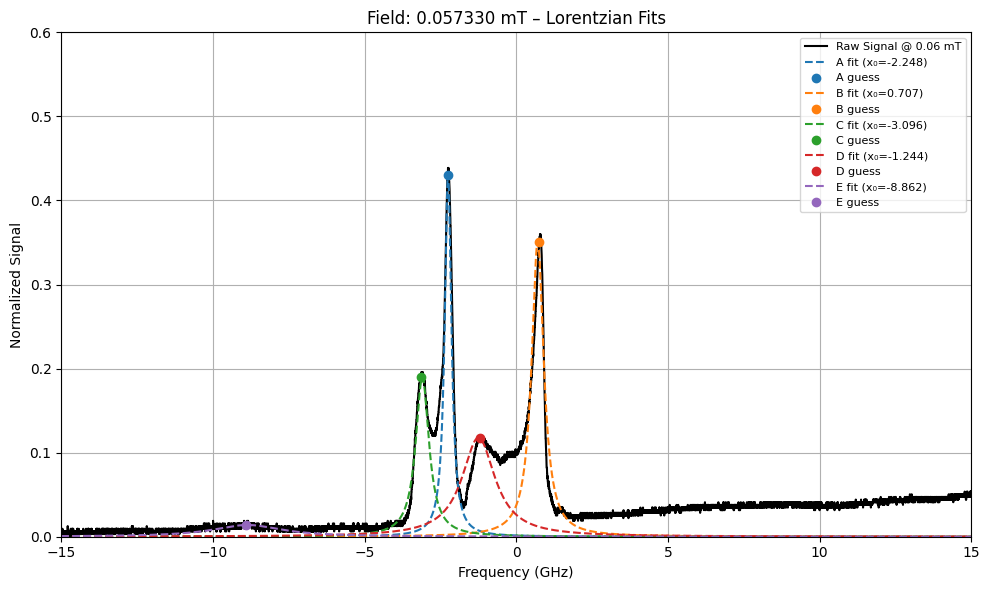

55.81333333333334

--- Fitting Lorentzians at B = 0.06 mT ---
  Trying A at B = 55.813333 mT
    Guess: Gamma=0.3548, x0=-2.2146, scale=0.2424
    Bounds: [[np.float64(0.003548173604961562), np.float64(-2.264589912), np.float64(0.024238654330953333)]], [[np.float64(0.3548173604961562), np.float64(-2.1645899120000003), np.float64(0.2423865433095333)]]
  Trying B at B = 55.813333 mT
    Guess: Gamma=0.5322, x0=0.7570, scale=0.3007
    Bounds: [[np.float64(0.005322260407442379), np.float64(0.7070054824523708), np.float64(0.030073422299732883)]], [[np.float64(0.5322260407442378), np.float64(0.8070054824523709), np.float64(0.3007342229973288)]]
  Trying C at B = 55.813333 mT
    Guess: Gamma=0.5766, x0=-3.1016, scale=0.1716
    Bounds: [[np.float64(0.005765782108062539), np.float64(-3.1516333129999996), np.float64(0.01716030543541402)]], [[np.float64(0.5765782108062538), np.float64(-3.051633313), np.float64(0.1716030543541402)]]
  Trying D at B = 55.813333 mT
    Guess: Gamma=1.2862, x0=-1.

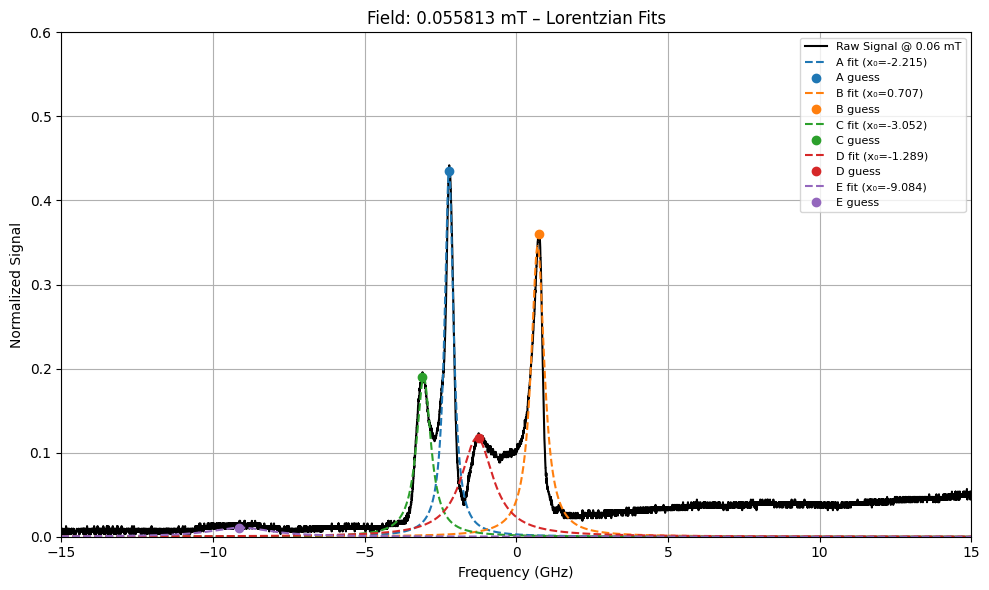

54.29666666666667

--- Fitting Lorentzians at B = 0.05 mT ---
  Trying A at B = 54.296667 mT
    Guess: Gamma=0.3992, x0=-2.1702, scale=0.2754
    Bounds: [[np.float64(0.003991695305581757), np.float64(-2.2202377419999997), np.float64(0.02754082565257412)]], [[np.float64(0.3991695305581757), np.float64(-2.120237742), np.float64(0.2754082565257412)]]
  Trying B at B = 54.296667 mT
    Guess: Gamma=0.4435, x0=0.7127, scale=0.2518
    Bounds: [[np.float64(0.004435217006201988), np.float64(0.6626533123903477), np.float64(0.02517521688312236)]], [[np.float64(0.4435217006201988), np.float64(0.7626533123903478), np.float64(0.2517521688312236)]]
  Trying C at B = 54.296667 mT
    Guess: Gamma=0.5766, x0=-3.0573, scale=0.1730
    Bounds: [[np.float64(0.005765782108062539), np.float64(-3.107281143), np.float64(0.01729672603537166)]], [[np.float64(0.5765782108062538), np.float64(-3.007281143), np.float64(0.1729672603537166)]]
  Trying D at B = 54.296667 mT
    Guess: Gamma=1.4636, x0=-1.3275, sca

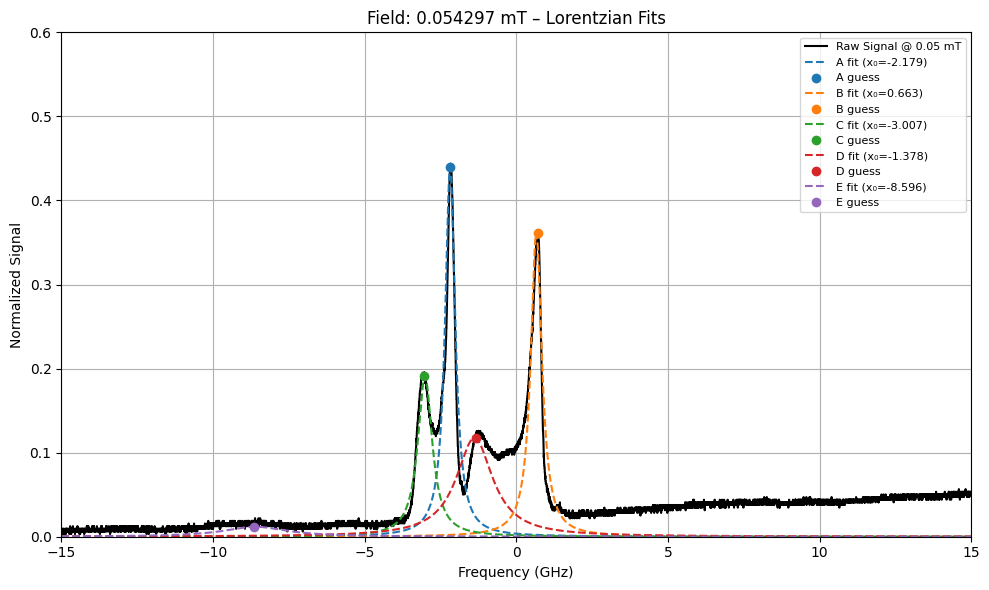

52.78

--- Fitting Lorentzians at B = 0.05 mT ---
  Trying A at B = 52.780000 mT
    Guess: Gamma=0.3992, x0=-2.1702, scale=0.2553
    Bounds: [[np.float64(0.003991695305581757), np.float64(-2.2202377419999997), np.float64(0.02552801332029403)]], [[np.float64(0.3991695305581757), np.float64(-2.120237742), np.float64(0.2552801332029403)]]
  Trying B at B = 52.780000 mT
    Guess: Gamma=0.4435, x0=0.6683, scale=0.2520
    Bounds: [[np.float64(0.004435217006201988), np.float64(0.6183011423283282), np.float64(0.02519761866654263)]], [[np.float64(0.4435217006201988), np.float64(0.7183011423283283), np.float64(0.2519761866654263)]]
  Trying C at B = 52.780000 mT
    Guess: Gamma=0.6209, x0=-3.1016, scale=0.1750
    Bounds: [[np.float64(0.006209303808682734), np.float64(-3.1516333129999996), np.float64(0.01750063028213166)]], [[np.float64(0.6209303808682733), np.float64(-3.051633313), np.float64(0.1750063028213166)]]
  Trying D at B = 52.780000 mT
    Guess: Gamma=1.1975, x0=-1.2832, scale=0.

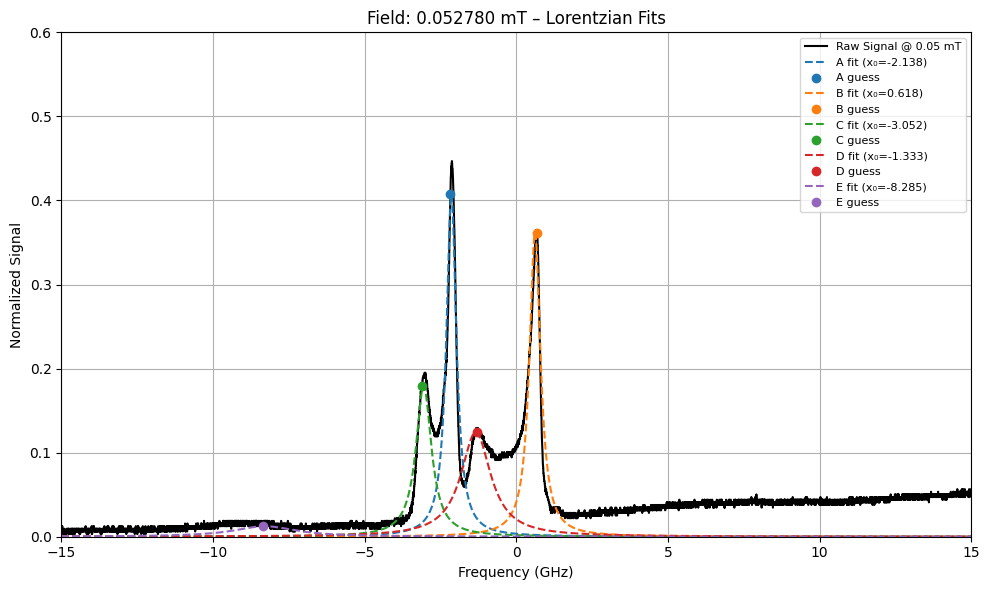

51.263333333333335

--- Fitting Lorentzians at B = 0.05 mT ---
  Trying A at B = 51.263333 mT
    Guess: Gamma=0.3105, x0=-2.0815, scale=0.2175
    Bounds: [[np.float64(0.003104651904341367), np.float64(-2.1315334019999996), np.float64(0.021749008951713632)]], [[np.float64(0.3104651904341367), np.float64(-2.031533402), np.float64(0.2174900895171363)]]
  Trying B at B = 51.263333 mT
    Guess: Gamma=0.4435, x0=0.6239, scale=0.2515
    Bounds: [[np.float64(0.004435217006201988), np.float64(0.5739489722663087), np.float64(0.02515119196636406)]], [[np.float64(0.4435217006201988), np.float64(0.6739489722663088), np.float64(0.2515119196636406)]]
  Trying C at B = 51.263333 mT
    Guess: Gamma=0.7540, x0=-3.0573, scale=0.2148
    Bounds: [[np.float64(0.007539868910543355), np.float64(-3.107281143), np.float64(0.02148269828082264)]], [[np.float64(0.7539868910543355), np.float64(-3.007281143), np.float64(0.2148269828082264)]]
  Trying D at B = 51.263333 mT
    Guess: Gamma=1.1975, x0=-1.3719, s

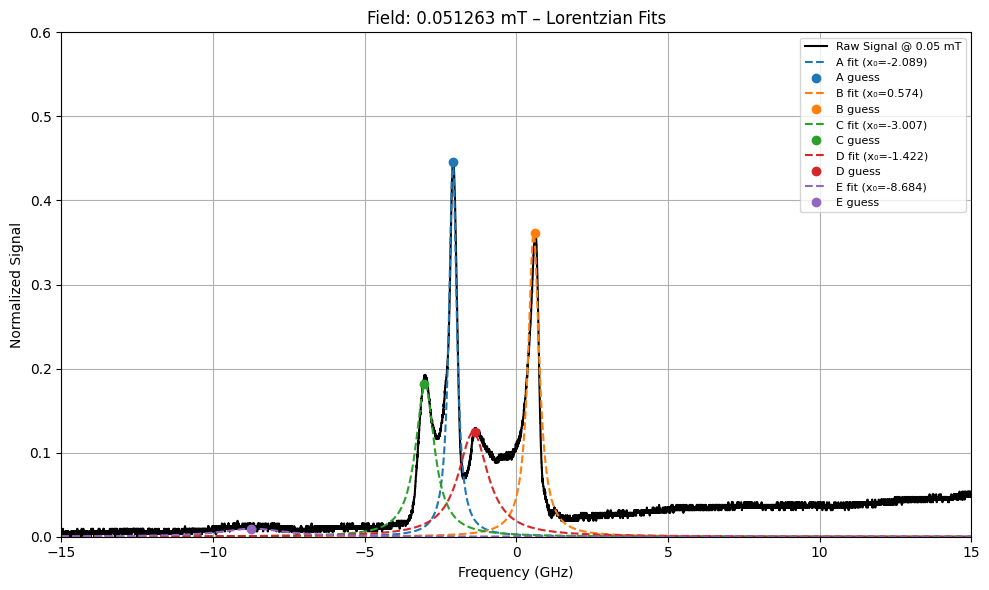

49.74666666666667

--- Fitting Lorentzians at B = 0.05 mT ---
  Trying A at B = 49.746667 mT
    Guess: Gamma=0.3548, x0=-2.0815, scale=0.2336
    Bounds: [[np.float64(0.003548173604961562), np.float64(-2.1315334019999996), np.float64(0.023359323900000003)]], [[np.float64(0.3548173604961562), np.float64(-2.031533402), np.float64(0.233593239)]]
  Trying B at B = 49.746667 mT
    Guess: Gamma=0.3992, x0=0.5796, scale=0.2279
    Bounds: [[np.float64(0.0039916953055817925), np.float64(0.5295968022042892), np.float64(0.02279092568974968)]], [[np.float64(0.3991695305581793), np.float64(0.6295968022042893), np.float64(0.2279092568974968)]]
  Trying C at B = 49.746667 mT
    Guess: Gamma=0.7983, x0=-3.0129, scale=0.2284
    Bounds: [[np.float64(0.00798339061), np.float64(-3.062928973), np.float64(0.02284225130429375)]], [[np.float64(0.798339061), np.float64(-2.9629289730000004), np.float64(0.2284225130429375)]]
  Trying D at B = 49.746667 mT
    Guess: Gamma=1.2419, x0=-1.3275, scale=0.2514
  

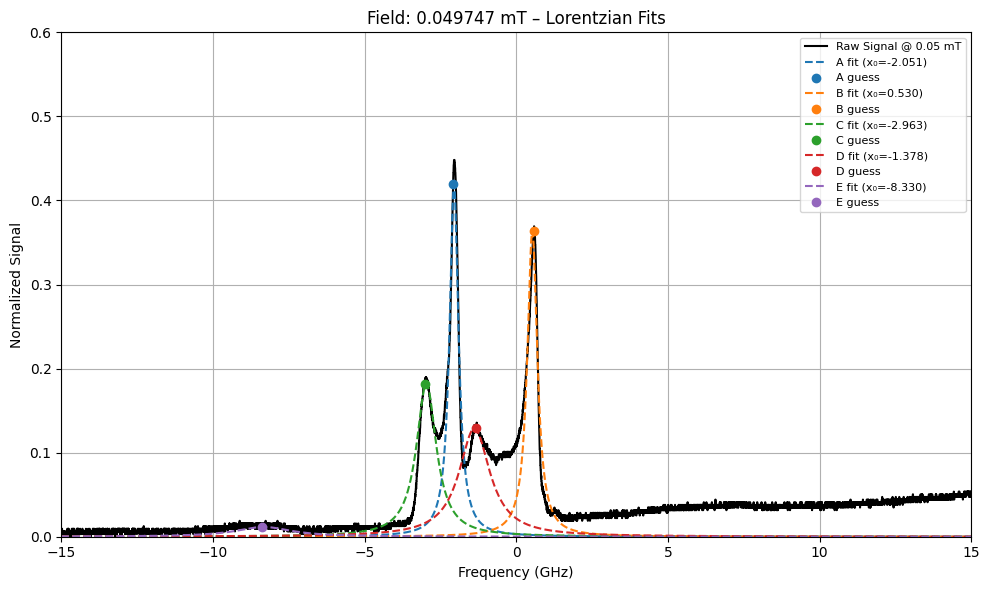

48.23

--- Fitting Lorentzians at B = 0.05 mT ---
  Trying A at B = 48.230000 mT
    Guess: Gamma=0.3992, x0=-2.0372, scale=0.2681
    Bounds: [[np.float64(0.003991695305581757), np.float64(-2.0871812309999997), np.float64(0.02681290935796507)]], [[np.float64(0.3991695305581757), np.float64(-1.9871812309999999), np.float64(0.2681290935796507)]]
  Trying B at B = 48.230000 mT
    Guess: Gamma=0.4435, x0=0.5352, scale=0.2530
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.4852446321422697), np.float64(0.025304436910145913)]], [[np.float64(0.4435217006201952), np.float64(0.5852446321422697), np.float64(0.2530443691014591)]]
  Trying C at B = 48.230000 mT
    Guess: Gamma=0.7096, x0=-3.0129, scale=0.1996
    Bounds: [[np.float64(0.007096347209923124), np.float64(-3.062928973), np.float64(0.019960962400000004)]], [[np.float64(0.7096347209923124), np.float64(-2.9629289730000004), np.float64(0.199609624)]]
  Trying D at B = 48.230000 mT
    Guess: Gamma=1.2862, x0=-1.3275, scale=

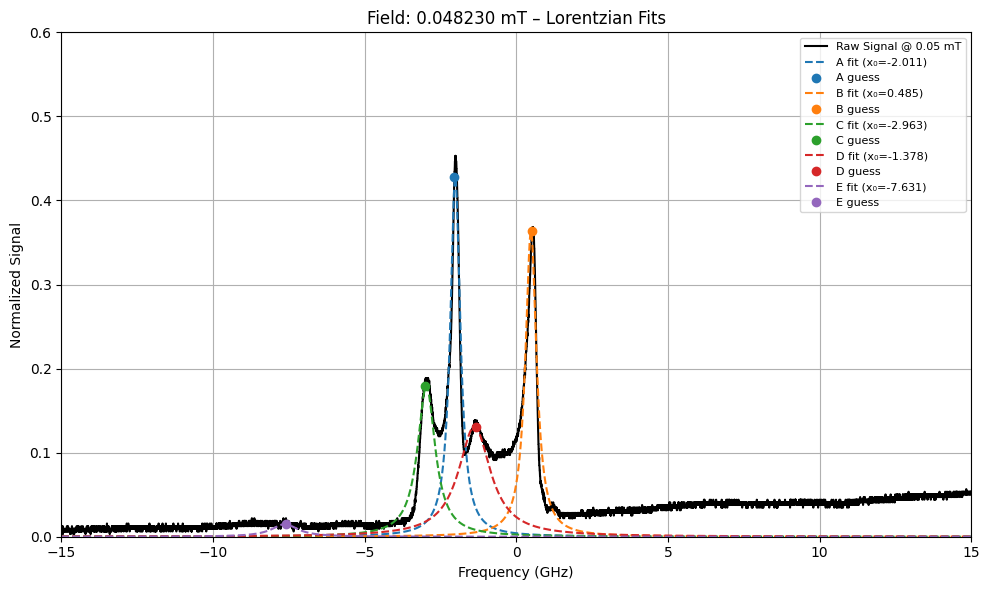

46.71333333333334

--- Fitting Lorentzians at B = 0.05 mT ---
  Trying A at B = 46.713333 mT
    Guess: Gamma=0.3548, x0=-1.9928, scale=0.2436
    Bounds: [[np.float64(0.003548173604961562), np.float64(-2.042829061), np.float64(0.02436037846304987)]], [[np.float64(0.3548173604961562), np.float64(-1.9428290609999999), np.float64(0.2436037846304987)]]
  Trying B at B = 46.713333 mT
    Guess: Gamma=0.4435, x0=0.4465, scale=0.2327
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.3965402920182306), np.float64(0.02327342961263969)]], [[np.float64(0.4435217006201952), np.float64(0.4965402920182306), np.float64(0.2327342961263969)]]
  Trying C at B = 46.713333 mT
    Guess: Gamma=0.6653, x0=-2.8799, scale=0.1906
    Bounds: [[np.float64(0.006652825509302929), np.float64(-2.9298724629999997), np.float64(0.01906265905418785)]], [[np.float64(0.6652825509302929), np.float64(-2.829872463), np.float64(0.1906265905418785)]]
  Trying D at B = 46.713333 mT
    Guess: Gamma=1.1088, x0=-1.37

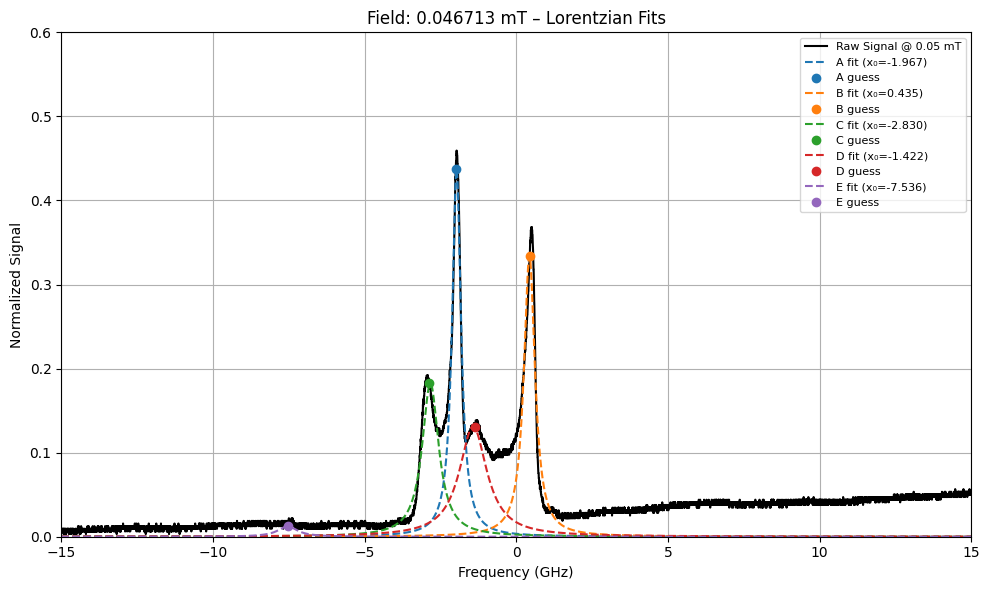

45.19666666666667

--- Fitting Lorentzians at B = 0.05 mT ---
  Trying A at B = 45.196667 mT
    Guess: Gamma=0.3105, x0=-1.9485, scale=0.2158
    Bounds: [[np.float64(0.003104651904341367), np.float64(-1.9984768910000001), np.float64(0.02158270541235123)]], [[np.float64(0.3104651904341367), np.float64(-1.898476891), np.float64(0.2158270541235123)]]
  Trying B at B = 45.196667 mT
    Guess: Gamma=0.4879, x0=0.4022, scale=0.2531
    Bounds: [[np.float64(0.004878738706822147), np.float64(0.35218812195621113), np.float64(0.02531472960288353)]], [[np.float64(0.4878738706822147), np.float64(0.4521881219562111), np.float64(0.2531472960288353)]]
  Trying C at B = 45.196667 mT
    Guess: Gamma=0.5766, x0=-2.9242, scale=0.1662
    Bounds: [[np.float64(0.005765782108062539), np.float64(-2.974224633), np.float64(0.01662448828166008)]], [[np.float64(0.5765782108062538), np.float64(-2.8742246330000003), np.float64(0.1662448828166008)]]
  Trying D at B = 45.196667 mT
    Guess: Gamma=1.3749, x0=-1.5

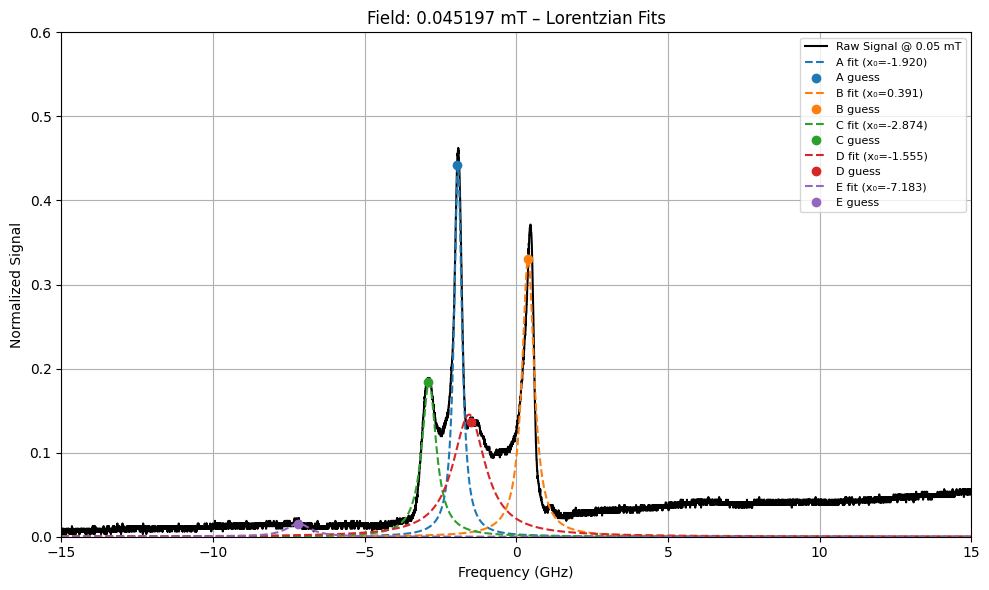

43.68000000000001

--- Fitting Lorentzians at B = 0.04 mT ---
  Trying A at B = 43.680000 mT
    Guess: Gamma=0.3992, x0=-1.9041, scale=0.2810
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-1.9541247210000001), np.float64(0.028101178557771313)]], [[np.float64(0.3991695305581793), np.float64(-1.854124721), np.float64(0.2810117855777131)]]
  Trying B at B = 43.680000 mT
    Guess: Gamma=0.4435, x0=0.3578, scale=0.2273
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.3078359518941916), np.float64(0.02273350848161492)]], [[np.float64(0.4435217006201952), np.float64(0.4078359518941916), np.float64(0.2273350848161492)]]
  Trying C at B = 43.680000 mT
    Guess: Gamma=0.5322, x0=-2.9686, scale=0.1391
    Bounds: [[np.float64(0.005322260407442343), np.float64(-3.0185768029999998), np.float64(0.013914623402260951)]], [[np.float64(0.5322260407442343), np.float64(-2.918576803), np.float64(0.1391462340226095)]]
  Trying D at B = 43.680000 mT
    Guess: Gamma=1.5523, x0=-1

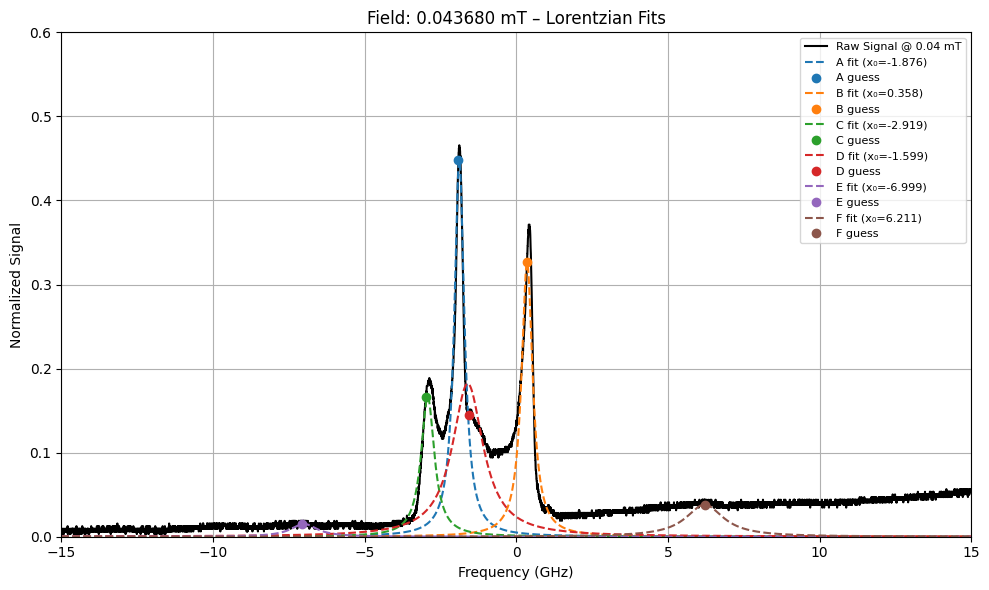

42.16333333333333

--- Fitting Lorentzians at B = 0.04 mT ---
  Trying A at B = 42.163333 mT
    Guess: Gamma=0.3548, x0=-1.8598, scale=0.2559
    Bounds: [[np.float64(0.003548173604961597), np.float64(-1.909772551), np.float64(0.025594508920081402)]], [[np.float64(0.3548173604961597), np.float64(-1.809772551), np.float64(0.255945089200814)]]
  Trying B at B = 42.163333 mT
    Guess: Gamma=0.4435, x0=0.3578, scale=0.2500
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.3078359518941916), np.float64(0.02499625066072194)]], [[np.float64(0.4435217006201952), np.float64(0.4078359518941916), np.float64(0.2499625066072194)]]
  Trying C at B = 42.163333 mT
    Guess: Gamma=0.6653, x0=-2.8355, scale=0.1918
    Bounds: [[np.float64(0.006652825509302965), np.float64(-2.885520293), np.float64(0.0191765609075158)]], [[np.float64(0.6652825509302964), np.float64(-2.7855202930000003), np.float64(0.191765609075158)]]
  Trying D at B = 42.163333 mT
    Guess: Gamma=1.5080, x0=-1.5050, scale

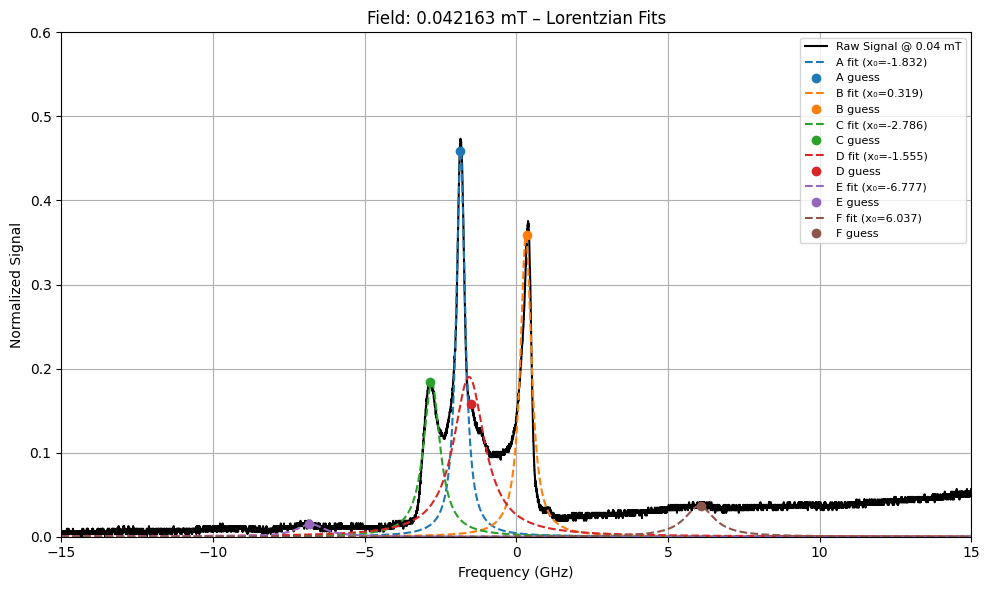

40.64666666666667

--- Fitting Lorentzians at B = 0.04 mT ---
  Trying A at B = 40.646667 mT
    Guess: Gamma=0.4435, x0=-1.8154, scale=0.3288
    Bounds: [[np.float64(0.004435217006201988), np.float64(-1.865420381), np.float64(0.03288402131493727)]], [[np.float64(0.4435217006201988), np.float64(-1.765420381), np.float64(0.3288402131493727)]]
  Trying B at B = 40.646667 mT
    Guess: Gamma=0.4435, x0=0.3135, scale=0.2495
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.263483781832172), np.float64(0.02494699859201)]], [[np.float64(0.4435217006201952), np.float64(0.363483781832172), np.float64(0.2494699859201)]]
  Trying C at B = 40.646667 mT
    Guess: Gamma=0.5766, x0=-2.8355, scale=0.1652
    Bounds: [[np.float64(0.005765782108062574), np.float64(-2.885520293), np.float64(0.01652073765979768)]], [[np.float64(0.5765782108062574), np.float64(-2.7855202930000003), np.float64(0.1652073765979768)]]
  Trying E at B = 40.646667 mT
    Guess: Gamma=1.0645, x0=-6.6498, scale=0.028

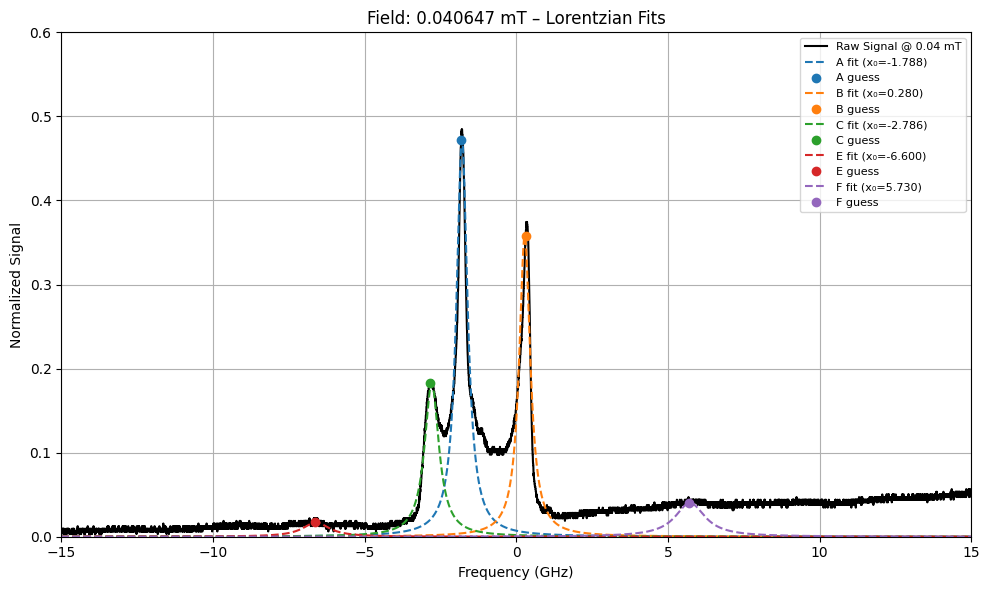

39.13

--- Fitting Lorentzians at B = 0.04 mT ---
  Trying A at B = 39.130000 mT
    Guess: Gamma=0.3548, x0=-1.8154, scale=0.2359
    Bounds: [[np.float64(0.003548173604961597), np.float64(-1.865420381), np.float64(0.02359168249405534)]], [[np.float64(0.3548173604961597), np.float64(-1.765420381), np.float64(0.2359168249405534)]]
  Trying B at B = 39.130000 mT
    Guess: Gamma=0.4435, x0=0.2691, scale=0.2461
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.2191316117701525), np.float64(0.024605211459663892)]], [[np.float64(0.4435217006201952), np.float64(0.3191316117701525), np.float64(0.2460521145966389)]]
  Trying C at B = 39.130000 mT
    Guess: Gamma=0.7096, x0=-2.7912, scale=0.2004
    Bounds: [[np.float64(0.00709634721), np.float64(-2.8411681229999997), np.float64(0.020043905283674623)]], [[np.float64(0.709634721), np.float64(-2.741168123), np.float64(0.2004390528367462)]]
  Trying E at B = 39.130000 mT
    Guess: Gamma=1.0201, x0=-6.5168, scale=0.0232
    Bounds: [[

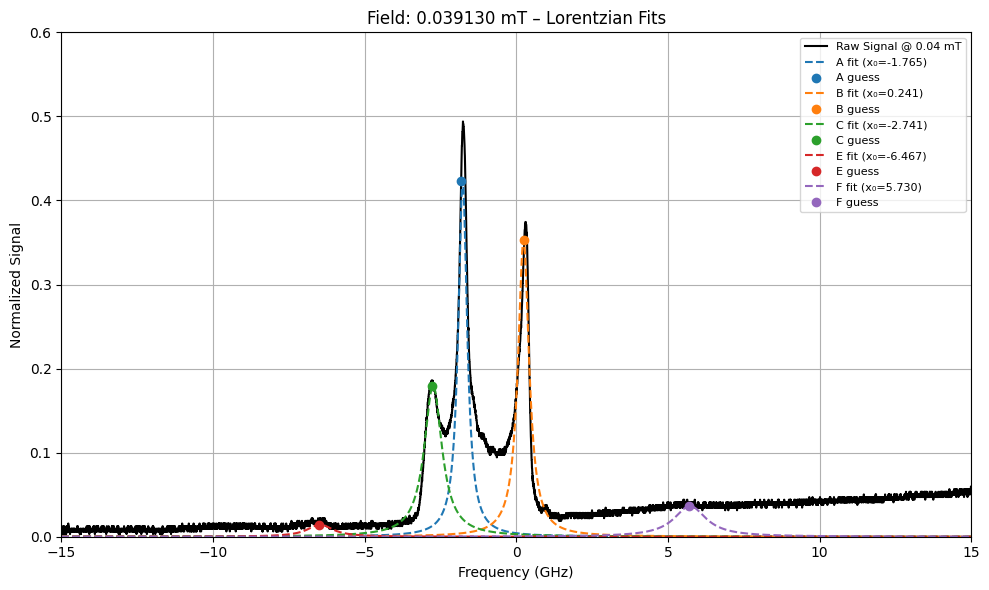

37.61333333333334

--- Fitting Lorentzians at B = 0.04 mT ---
  Trying A at B = 37.613333 mT
    Guess: Gamma=0.4435, x0=-1.6824, scale=0.3411
    Bounds: [[np.float64(0.004435217006201988), np.float64(-1.732363871), np.float64(0.03410559646528189)]], [[np.float64(0.4435217006201988), np.float64(-1.632363871), np.float64(0.3410559646528189)]]
  Trying B at B = 37.613333 mT
    Guess: Gamma=0.4435, x0=0.2248, scale=0.2456
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.17477944170813298), np.float64(0.02456129411200026)]], [[np.float64(0.4435217006201952), np.float64(0.274779441708133), np.float64(0.2456129411200026)]]
  Trying C at B = 37.613333 mT
    Guess: Gamma=0.6653, x0=-2.7912, scale=0.1854
    Bounds: [[np.float64(0.006652825509302965), np.float64(-2.8411681229999997), np.float64(0.01853680355347002)]], [[np.float64(0.6652825509302964), np.float64(-2.741168123), np.float64(0.1853680355347002)]]
  Trying E at B = 37.613333 mT
    Guess: Gamma=0.9757, x0=-6.3393, sca

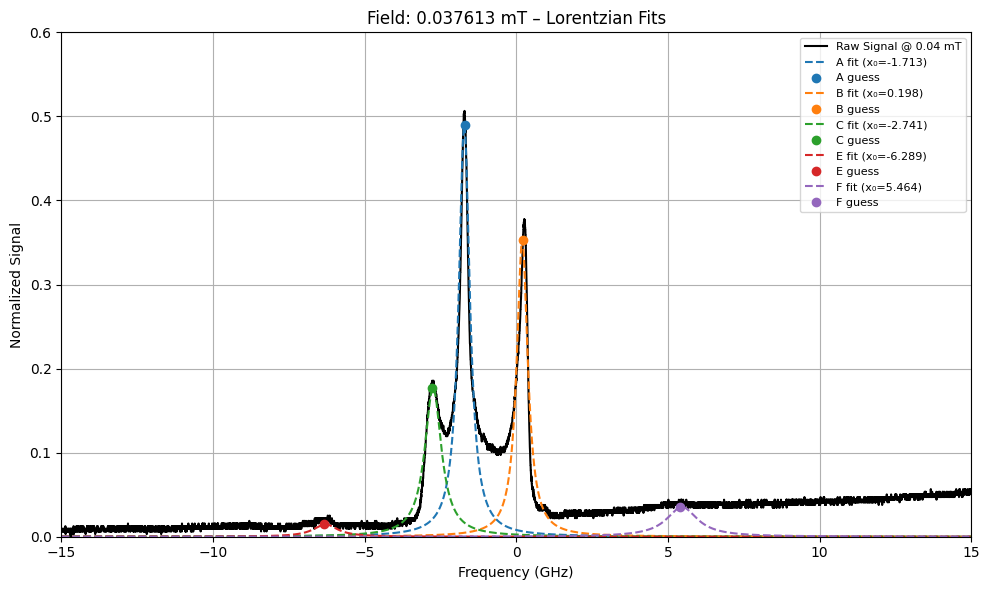

36.09666666666666

--- Fitting Lorentzians at B = 0.04 mT ---
  Trying A at B = 36.096667 mT
    Guess: Gamma=0.3105, x0=-1.6824, scale=0.2482
    Bounds: [[np.float64(0.0031046519043414025), np.float64(-1.732363871), np.float64(0.02482214771105303)]], [[np.float64(0.3104651904341402), np.float64(-1.632363871), np.float64(0.2482214771105303)]]
  Trying B at B = 36.096667 mT
    Guess: Gamma=0.4435, x0=0.2248, scale=0.2617
    Bounds: [[np.float64(0.004435217006201952), np.float64(0.17477944170813298), np.float64(0.02616626510010331)]], [[np.float64(0.4435217006201952), np.float64(0.274779441708133), np.float64(0.2616626510010331)]]
  Trying C at B = 36.096667 mT
    Guess: Gamma=0.6209, x0=-2.7468, scale=0.1721
    Bounds: [[np.float64(0.006209303808682769), np.float64(-2.7968159519999998), np.float64(0.01721491290368327)]], [[np.float64(0.6209303808682769), np.float64(-2.696815952), np.float64(0.1721491290368327)]]
  Trying E at B = 36.096667 mT
    Guess: Gamma=0.7540, x0=-6.1176, sc

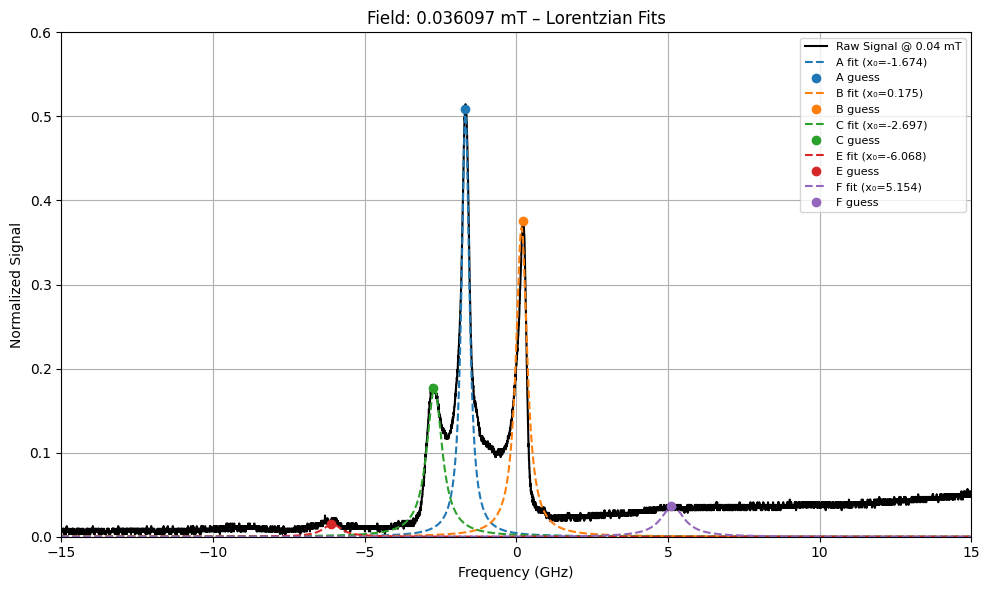

34.58

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 34.580000 mT
    Guess: Gamma=0.4879, x0=-1.6380, scale=0.3987
    Bounds: [[np.float64(0.004878738706822184), np.float64(-1.688011701), np.float64(0.039868664278493074)]], [[np.float64(0.4878738706822183), np.float64(-1.5880117009999999), np.float64(0.3986866427849307)]]
  Trying B at B = 34.580000 mT
    Guess: Gamma=0.3992, x0=0.1804, scale=0.2367
    Bounds: [[np.float64(0.003991695305581757), np.float64(0.1304272716461135), np.float64(0.02366728090502786)]], [[np.float64(0.3991695305581757), np.float64(0.23042727164611349), np.float64(0.2366728090502786)]]
  Trying C at B = 34.580000 mT
    Guess: Gamma=0.6653, x0=-2.7912, scale=0.1766
    Bounds: [[np.float64(0.006652825509302965), np.float64(-2.8411681229999997), np.float64(0.0176619072950588)]], [[np.float64(0.6652825509302964), np.float64(-2.741168123), np.float64(0.176619072950588)]]
  Trying E at B = 34.580000 mT
    Guess: Gamma=0.7096, x0=-6.0289, scale=0.

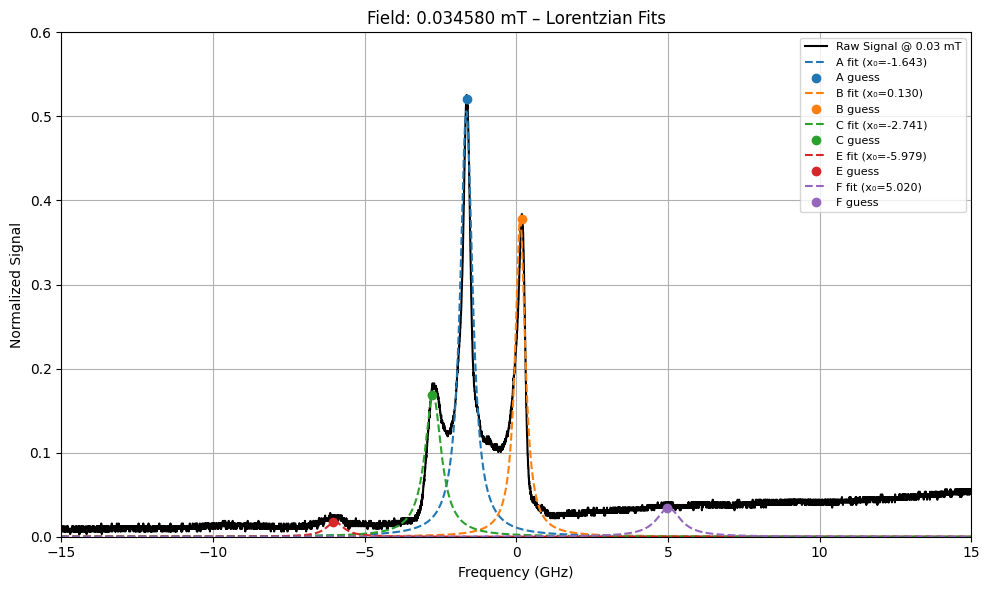

33.06333333333333

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 33.063333 mT
    Guess: Gamma=0.3992, x0=-1.6380, scale=0.3081
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-1.688011701), np.float64(0.030810242461546553)]], [[np.float64(0.3991695305581793), np.float64(-1.5880117009999999), np.float64(0.3081024246154655)]]
  Trying B at B = 33.063333 mT
    Guess: Gamma=0.3548, x0=0.0917, scale=0.1907
    Bounds: [[np.float64(0.003548173604961562), np.float64(0.04172293199999999), np.float64(0.01907079648240998)]], [[np.float64(0.3548173604961562), np.float64(0.141722932), np.float64(0.1907079648240998)]]
  Trying C at B = 33.063333 mT
    Guess: Gamma=0.6209, x0=-2.7025, scale=0.1701
    Bounds: [[np.float64(0.006209303808682769), np.float64(-2.752463782), np.float64(0.017007387856479213)]], [[np.float64(0.6209303808682769), np.float64(-2.6524637820000003), np.float64(0.1700738785647921)]]
  Trying E at B = 33.063333 mT
    Guess: Gamma=0.6209, x0=-5.8515,

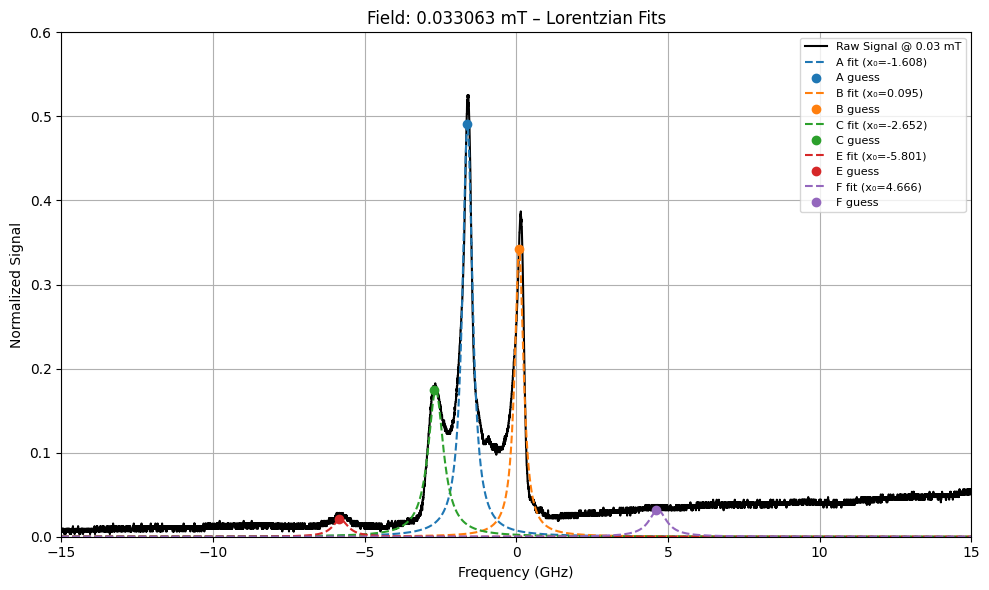

31.546666666666667

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 31.546667 mT
    Guess: Gamma=0.4879, x0=-1.5937, scale=0.3802
    Bounds: [[np.float64(0.004878738706822184), np.float64(-1.643659531), np.float64(0.038017672016961414)]], [[np.float64(0.4878738706822183), np.float64(-1.5436595309999999), np.float64(0.3801767201696141)]]
  Trying B at B = 31.546667 mT
    Guess: Gamma=0.3992, x0=0.0917, scale=0.2376
    Bounds: [[np.float64(0.0039916953055817925), np.float64(0.04172293199999999), np.float64(0.023764889562790072)]], [[np.float64(0.3991695305581793), np.float64(0.141722932), np.float64(0.2376488956279007)]]
  Trying C at B = 31.546667 mT
    Guess: Gamma=0.6653, x0=-2.7025, scale=0.1783
    Bounds: [[np.float64(0.006652825509302965), np.float64(-2.752463782), np.float64(0.01782564482535333)]], [[np.float64(0.6652825509302964), np.float64(-2.6524637820000003), np.float64(0.1782564482535333)]]
  Trying E at B = 31.546667 mT
    Guess: Gamma=0.7096, x0=-5.6741

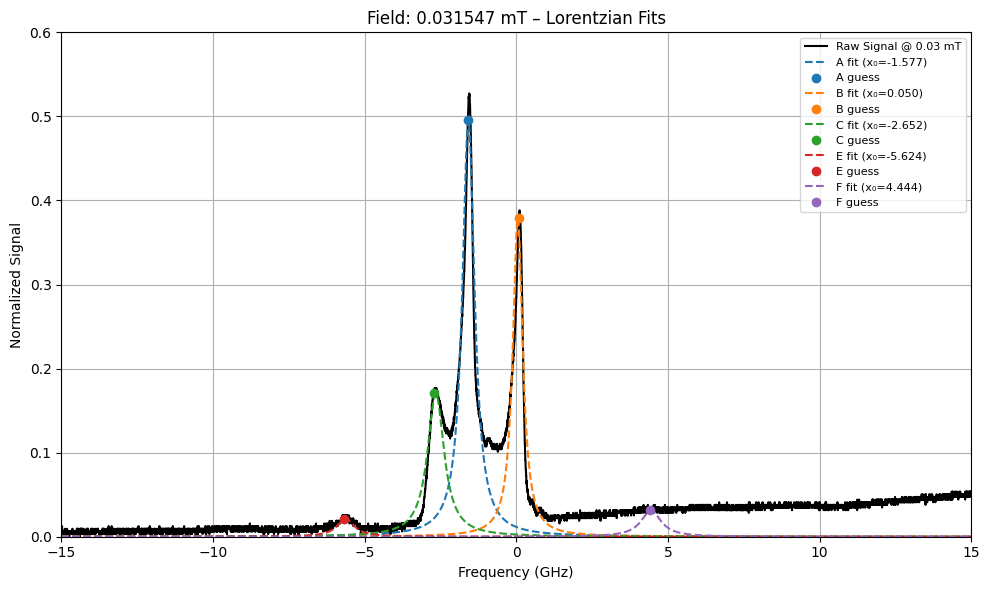

30.03

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 30.030000 mT
    Guess: Gamma=0.5766, x0=-1.5493, scale=0.4556
    Bounds: [[np.float64(0.005765782108062574), np.float64(-1.5993073610000001), np.float64(0.045560609982367765)]], [[np.float64(0.5765782108062574), np.float64(-1.499307361), np.float64(0.4556060998236776)]]
  Trying B at B = 30.030000 mT
    Guess: Gamma=0.3548, x0=0.0474, scale=0.2111
    Bounds: [[np.float64(0.003548173604961597), np.float64(-0.0026292390000000054), np.float64(0.0211071206519769)]], [[np.float64(0.3548173604961597), np.float64(0.097370761), np.float64(0.211071206519769)]]
  Trying C at B = 30.030000 mT
    Guess: Gamma=0.6209, x0=-2.7025, scale=0.1645
    Bounds: [[np.float64(0.006209303808682769), np.float64(-2.752463782), np.float64(0.016447512037873712)]], [[np.float64(0.6209303808682769), np.float64(-2.6524637820000003), np.float64(0.1644751203787371)]]
  Trying E at B = 30.030000 mT
    Guess: Gamma=0.5322, x0=-5.4523, scale=0.019

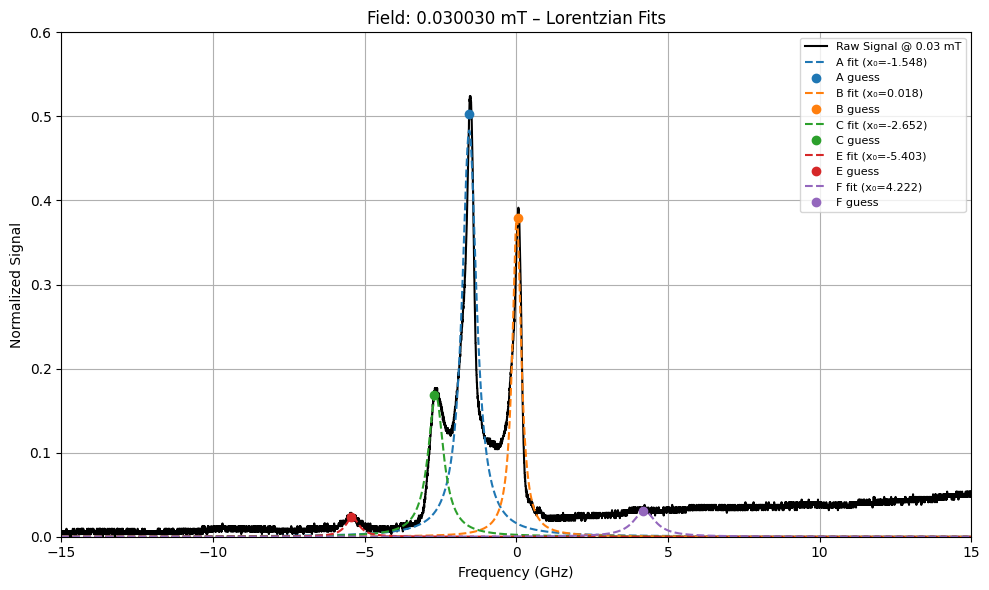

28.513333333333332

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 28.513333 mT
    Guess: Gamma=0.4879, x0=-1.5493, scale=0.3362
    Bounds: [[np.float64(0.004878738706822184), np.float64(-1.5993073610000001), np.float64(0.03361567650857154)]], [[np.float64(0.4878738706822183), np.float64(-1.499307361), np.float64(0.3361567650857154)]]
  Trying B at B = 28.513333 mT
    Guess: Gamma=0.3992, x0=0.0030, scale=0.2386
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-0.046981409), np.float64(0.02385873154973133)]], [[np.float64(0.3991695305581793), np.float64(0.053018591000000004), np.float64(0.2385873154973133)]]
  Trying C at B = 28.513333 mT
    Guess: Gamma=0.6209, x0=-2.6138, scale=0.1697
    Bounds: [[np.float64(0.006209303808682769), np.float64(-2.663759442), np.float64(0.0169657996536877)]], [[np.float64(0.6209303808682769), np.float64(-2.5637594420000003), np.float64(0.169657996536877)]]
  Trying E at B = 28.513333 mT
    Guess: Gamma=0.6209, x0=-5.2305, 

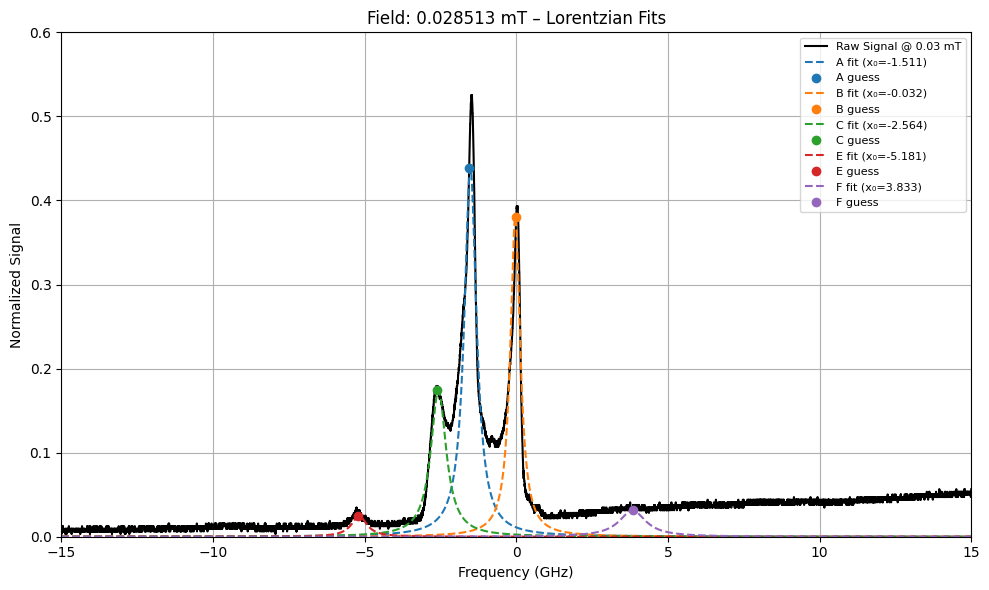

26.99666666666667

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 26.996667 mT
    Guess: Gamma=0.5322, x0=-1.5050, scale=0.3675
    Bounds: [[np.float64(0.005322260407442379), np.float64(-1.5549551910000001), np.float64(0.036754721772821845)]], [[np.float64(0.5322260407442378), np.float64(-1.454955191), np.float64(0.3675472177282184)]]
  Trying B at B = 26.996667 mT
    Guess: Gamma=0.4879, x0=-0.0413, scale=0.2877
    Bounds: [[np.float64(0.004878738706822184), np.float64(-0.091333579), np.float64(0.0287733095)]], [[np.float64(0.4878738706822183), np.float64(0.008666421), np.float64(0.287733095)]]
  Trying C at B = 26.996667 mT
    Guess: Gamma=0.7096, x0=-2.5694, scale=0.1897
    Bounds: [[np.float64(0.00709634721), np.float64(-2.6194072719999997), np.float64(0.018973630365382382)]], [[np.float64(0.709634721), np.float64(-2.519407272), np.float64(0.1897363036538238)]]
  Trying E at B = 26.996667 mT
    Guess: Gamma=0.4879, x0=-5.0975, scale=0.0181
    Bounds: [[np.floa

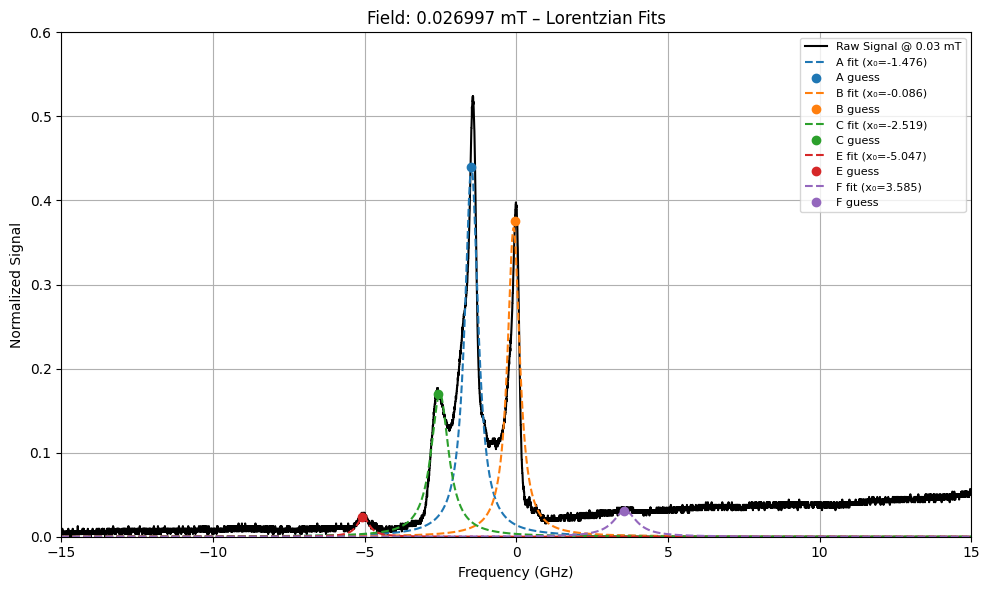

25.480000000000004

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 25.480000 mT
    Guess: Gamma=0.5766, x0=-1.4163, scale=0.4613
    Bounds: [[np.float64(0.005765782108062574), np.float64(-1.466250851), np.float64(0.04613253462804915)]], [[np.float64(0.5765782108062574), np.float64(-1.366250851), np.float64(0.4613253462804915)]]
  Trying B at B = 25.480000 mT
    Guess: Gamma=0.4435, x0=-0.0857, scale=0.2619
    Bounds: [[np.float64(0.004435217006201988), np.float64(-0.13568574900000002), np.float64(0.02618647113921886)]], [[np.float64(0.4435217006201988), np.float64(-0.035685749), np.float64(0.2618647113921886)]]
  Trying C at B = 25.480000 mT
    Guess: Gamma=0.6209, x0=-2.5694, scale=0.1661
    Bounds: [[np.float64(0.006209303808682769), np.float64(-2.6194072719999997), np.float64(0.016611381540344212)]], [[np.float64(0.6209303808682769), np.float64(-2.519407272), np.float64(0.1661138154034421)]]
  Trying E at B = 25.480000 mT
    Guess: Gamma=0.4435, x0=-4.9201, scal

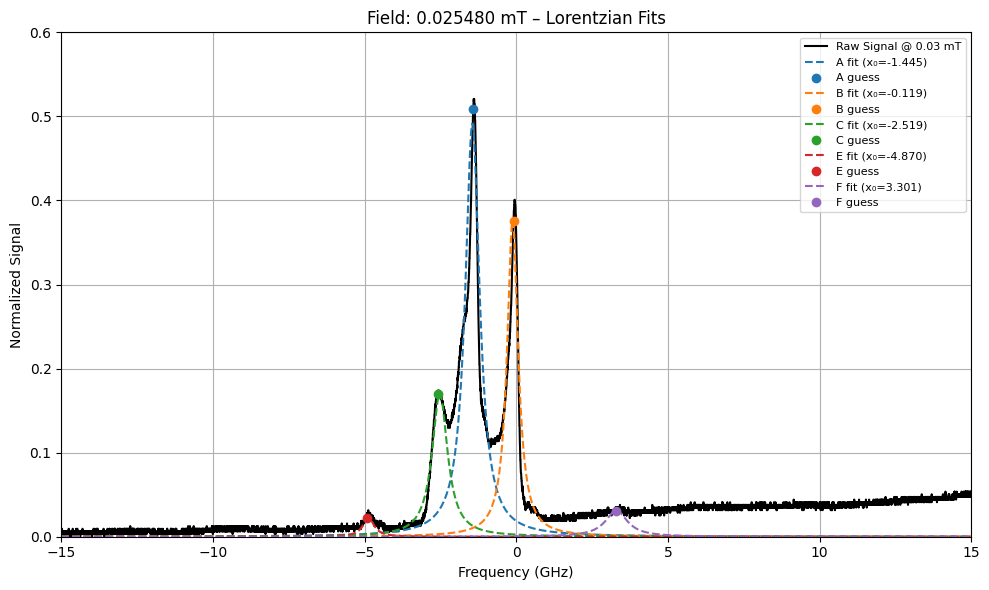

23.96333333333334

--- Fitting Lorentzians at B = 0.02 mT ---
  Trying A at B = 23.963333 mT
    Guess: Gamma=0.5322, x0=-1.4163, scale=0.3766
    Bounds: [[np.float64(0.005322260407442343), np.float64(-1.466250851), np.float64(0.03765902889079141)]], [[np.float64(0.5322260407442343), np.float64(-1.366250851), np.float64(0.3765902889079141)]]
  Trying B at B = 23.963333 mT
    Guess: Gamma=0.5322, x0=-0.1744, scale=0.2663
    Bounds: [[np.float64(0.005322260407442379), np.float64(-0.22439008900000001), np.float64(0.026630808988830232)]], [[np.float64(0.5322260407442378), np.float64(-0.124390089), np.float64(0.2663080898883023)]]
  Trying C at B = 23.963333 mT
    Guess: Gamma=0.7540, x0=-2.5694, scale=0.1996
    Bounds: [[np.float64(0.007539868910543355), np.float64(-2.6194072719999997), np.float64(0.019958183311898563)]], [[np.float64(0.7539868910543355), np.float64(-2.519407272), np.float64(0.1995818331189856)]]
  Trying E at B = 23.963333 mT
    Guess: Gamma=0.4435, x0=-4.6983, scal

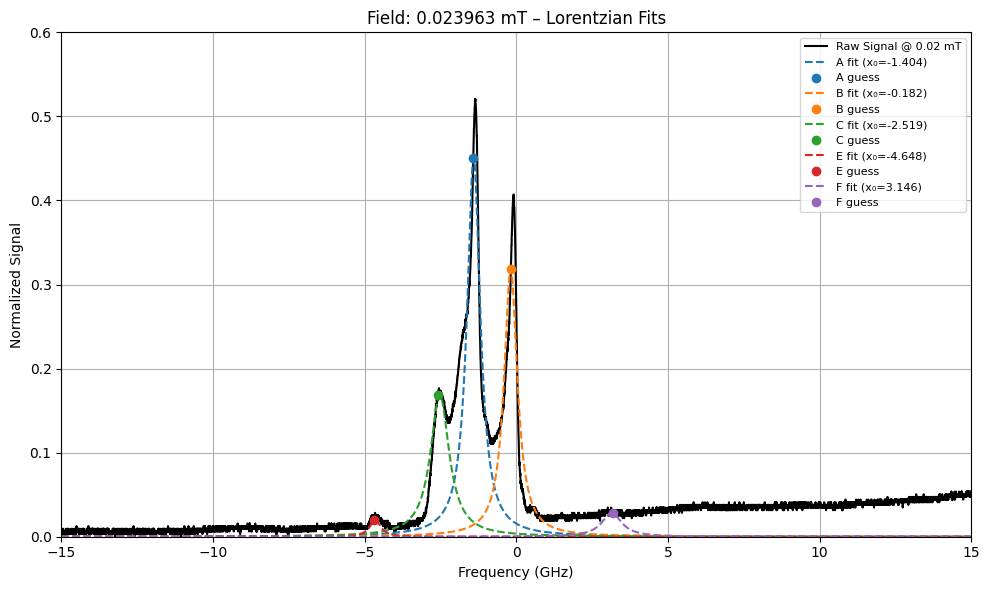

22.446666666666665

--- Fitting Lorentzians at B = 0.02 mT ---
  Trying A at B = 22.446667 mT
    Guess: Gamma=0.4435, x0=-1.3275, scale=0.3531
    Bounds: [[np.float64(0.004435217006201952), np.float64(-1.37754651), np.float64(0.035312428586628544)]], [[np.float64(0.4435217006201952), np.float64(-1.2775465099999999), np.float64(0.3531242858662854)]]
  Trying B at B = 22.446667 mT
    Guess: Gamma=0.3992, x0=-0.1300, scale=0.2543
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-0.180037919), np.float64(0.02542642695256831)]], [[np.float64(0.3991695305581793), np.float64(-0.080037919), np.float64(0.2542642695256831)]]
  Trying C at B = 22.446667 mT
    Guess: Gamma=0.6653, x0=-2.5251, scale=0.1773
    Bounds: [[np.float64(0.006652825509302965), np.float64(-2.575055102), np.float64(0.01773043316912829)]], [[np.float64(0.6652825509302964), np.float64(-2.4750551020000002), np.float64(0.1773043316912829)]]
  Trying E at B = 22.446667 mT
    Guess: Gamma=0.6653, x0=-4.4322, scale

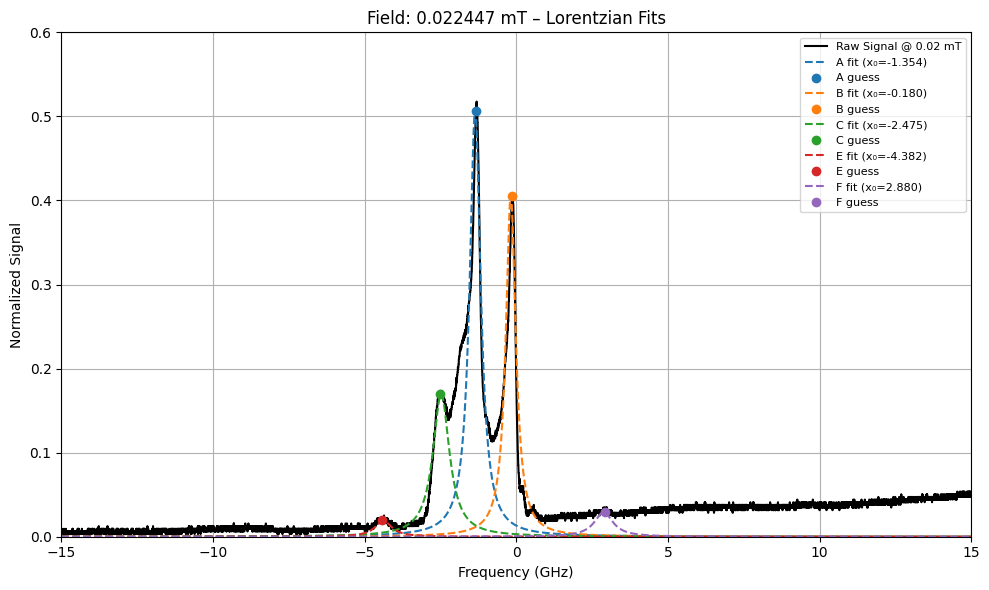

20.93

--- Fitting Lorentzians at B = 0.02 mT ---
  Trying A at B = 20.930000 mT
    Guess: Gamma=0.4435, x0=-1.2832, scale=0.3536
    Bounds: [[np.float64(0.004435217006201952), np.float64(-1.3331943400000001), np.float64(0.03535841880938123)]], [[np.float64(0.4435217006201952), np.float64(-1.23319434), np.float64(0.3535841880938123)]]
  Trying B at B = 20.930000 mT
    Guess: Gamma=0.4435, x0=-0.1744, scale=0.2853
    Bounds: [[np.float64(0.004435217006201988), np.float64(-0.22439008900000001), np.float64(0.02852788765301142)]], [[np.float64(0.4435217006201988), np.float64(-0.124390089), np.float64(0.2852788765301142)]]
  Trying C at B = 20.930000 mT
    Guess: Gamma=0.5322, x0=-2.5251, scale=0.1379
    Bounds: [[np.float64(0.005322260407442379), np.float64(-2.575055102), np.float64(0.01379334178324864)]], [[np.float64(0.5322260407442378), np.float64(-2.4750551020000002), np.float64(0.1379334178324864)]]
  Trying E at B = 20.930000 mT
    Guess: Gamma=0.6209, x0=-4.2104, scale=0.0168

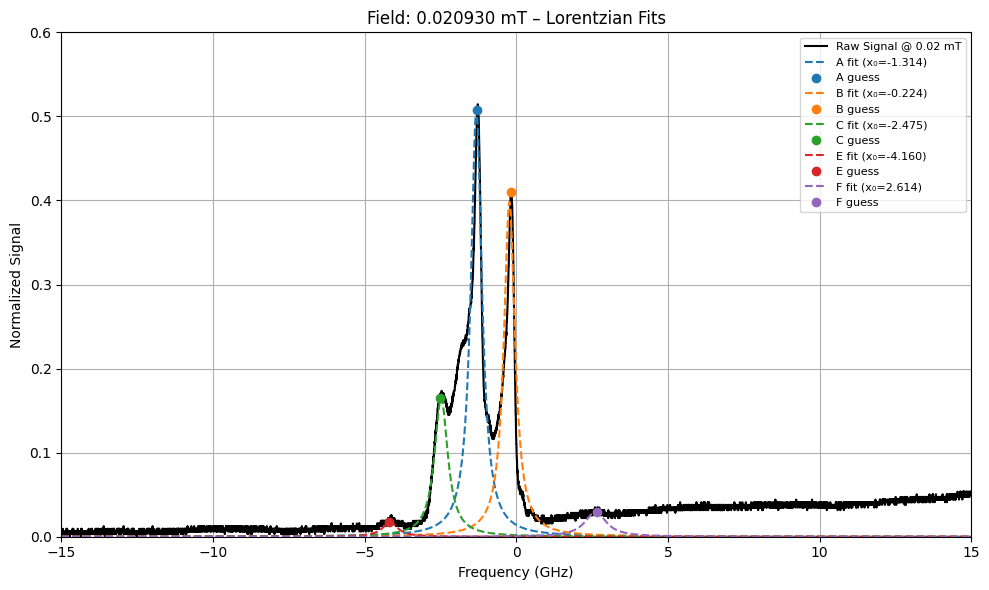

19.41333333333333

--- Fitting Lorentzians at B = 0.02 mT ---
  Trying A at B = 19.413333 mT
    Guess: Gamma=0.4435, x0=-1.2388, scale=0.3554
    Bounds: [[np.float64(0.004435217006201952), np.float64(-1.2888421700000001), np.float64(0.03554427142392652)]], [[np.float64(0.4435217006201952), np.float64(-1.18884217), np.float64(0.3554427142392652)]]
  Trying B at B = 19.413333 mT
    Guess: Gamma=0.4435, x0=-0.2187, scale=0.2863
    Bounds: [[np.float64(0.004435217006201988), np.float64(-0.268742259), np.float64(0.028628026565362643)]], [[np.float64(0.4435217006201988), np.float64(-0.168742259), np.float64(0.2862802656536264)]]
  Trying C at B = 19.413333 mT
    Guess: Gamma=0.7540, x0=-2.4364, scale=0.2012
    Bounds: [[np.float64(0.007539868910543355), np.float64(-2.486350762), np.float64(0.02012147912336457)]], [[np.float64(0.7539868910543355), np.float64(-2.386350762), np.float64(0.2012147912336457)]]
  Trying E at B = 19.413333 mT
    Guess: Gamma=0.5322, x0=-3.8113, scale=0.0178
 

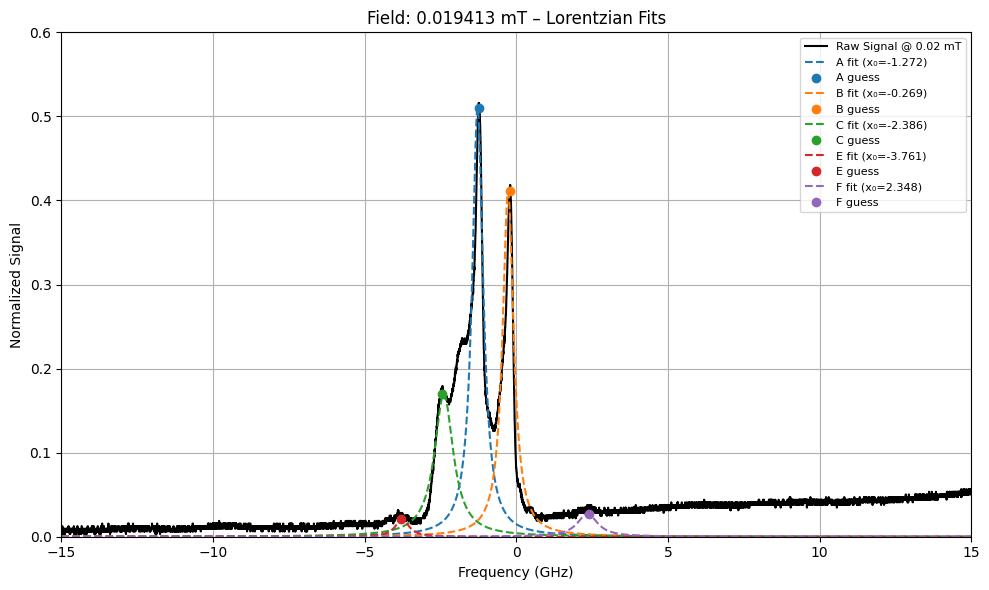

17.89666666666667

--- Fitting Lorentzians at B = 0.02 mT ---
  Trying A at B = 17.896667 mT
    Guess: Gamma=0.4435, x0=-1.1945, scale=0.3558
    Bounds: [[np.float64(0.004435217006201952), np.float64(-1.24449), np.float64(0.035579176389186694)]], [[np.float64(0.4435217006201952), np.float64(-1.14449), np.float64(0.3557917638918669)]]
  Trying B at B = 17.896667 mT
    Guess: Gamma=0.3992, x0=-0.2631, scale=0.2583
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-0.313094429), np.float64(0.02582576920166394)]], [[np.float64(0.3991695305581793), np.float64(-0.21309442900000003), np.float64(0.2582576920166394)]]
  Trying C at B = 17.896667 mT
    Guess: Gamma=0.8870, x0=-2.4364, scale=0.2332
    Bounds: [[np.float64(0.00887043401), np.float64(-2.486350762), np.float64(0.02332362176996872)]], [[np.float64(0.887043401), np.float64(-2.386350762), np.float64(0.2332362176996872)]]
  Trying E at B = 17.896667 mT
    Guess: Gamma=0.4435, x0=-3.7226, scale=0.0141
    Bounds: [[np.flo

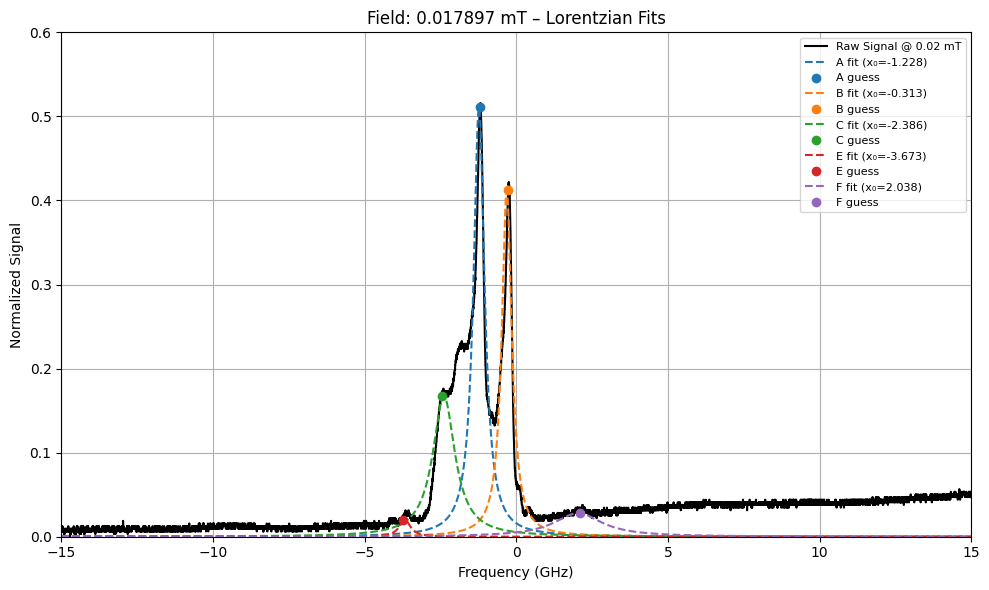

16.380000000000003

--- Fitting Lorentzians at B = 0.02 mT ---
  Trying A at B = 16.380000 mT
    Guess: Gamma=0.3548, x0=-1.1501, scale=0.2839
    Bounds: [[np.float64(0.003548173604961562), np.float64(-1.20013783), np.float64(0.02838764598151542)]], [[np.float64(0.3548173604961562), np.float64(-1.10013783), np.float64(0.2838764598151542)]]
  Trying B at B = 16.380000 mT
    Guess: Gamma=0.3548, x0=-0.3074, scale=0.2321
    Bounds: [[np.float64(0.003548173604961562), np.float64(-0.357446599), np.float64(0.02321245062172713)]], [[np.float64(0.3548173604961562), np.float64(-0.257446599), np.float64(0.2321245062172713)]]
  Trying C at B = 16.380000 mT
    Guess: Gamma=0.7983, x0=-2.3476, scale=0.2082
    Bounds: [[np.float64(0.00798339061), np.float64(-2.3976464219999998), np.float64(0.020824530361786983)]], [[np.float64(0.798339061), np.float64(-2.297646422), np.float64(0.2082453036178698)]]
  Trying E at B = 16.380000 mT
    Guess: Gamma=0.4435, x0=-3.3677, scale=0.0179
    Bounds: [[n

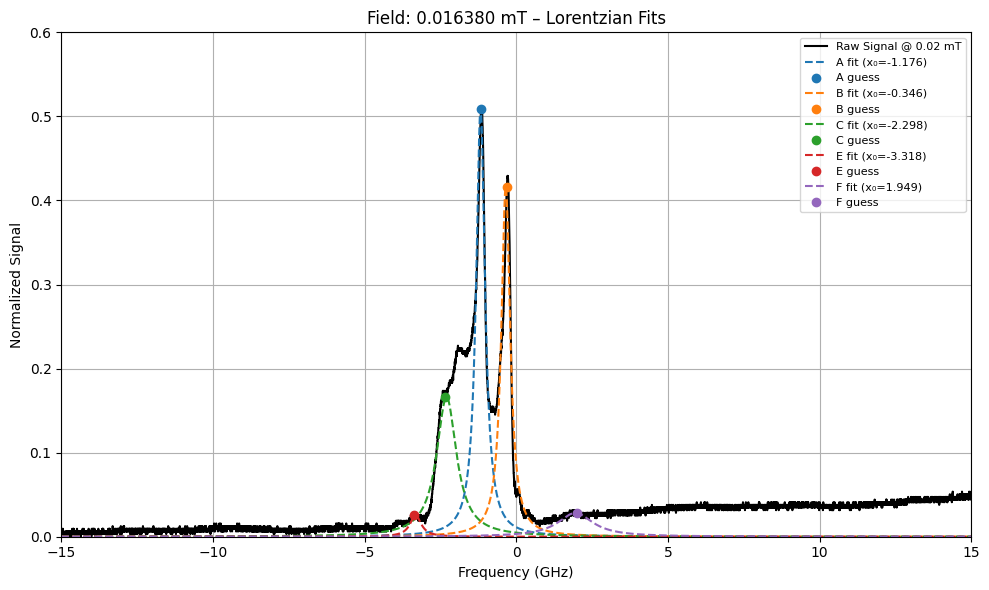

14.863333333333337

--- Fitting Lorentzians at B = 0.01 mT ---
  Trying A at B = 14.863333 mT
    Guess: Gamma=0.3992, x0=-1.1945, scale=0.2508
    Bounds: [[np.float64(0.003991695305581757), np.float64(-1.24449), np.float64(0.025075622297179828)]], [[np.float64(0.3991695305581757), np.float64(-1.14449), np.float64(0.2507562229717983)]]
  Trying B at B = 14.863333 mT
    Guess: Gamma=0.3548, x0=-0.3518, scale=0.2301
    Bounds: [[np.float64(0.003548173604961562), np.float64(-0.401798769), np.float64(0.0230096863473501)]], [[np.float64(0.3548173604961562), np.float64(-0.301798769), np.float64(0.230096863473501)]]
  Trying C at B = 14.863333 mT
    Guess: Gamma=1.0645, x0=-1.9041, scale=0.3769
    Bounds: [[np.float64(0.010644520814884758), np.float64(-1.9541247210000001), np.float64(0.03768689189850227)]], [[np.float64(1.0644520814884757), np.float64(-1.854124721), np.float64(0.3768689189850227)]]
  Trying D at B = 14.863333 mT
    Guess: Gamma=0.9314, x0=-1.9041, scale=0.3298
    Bound

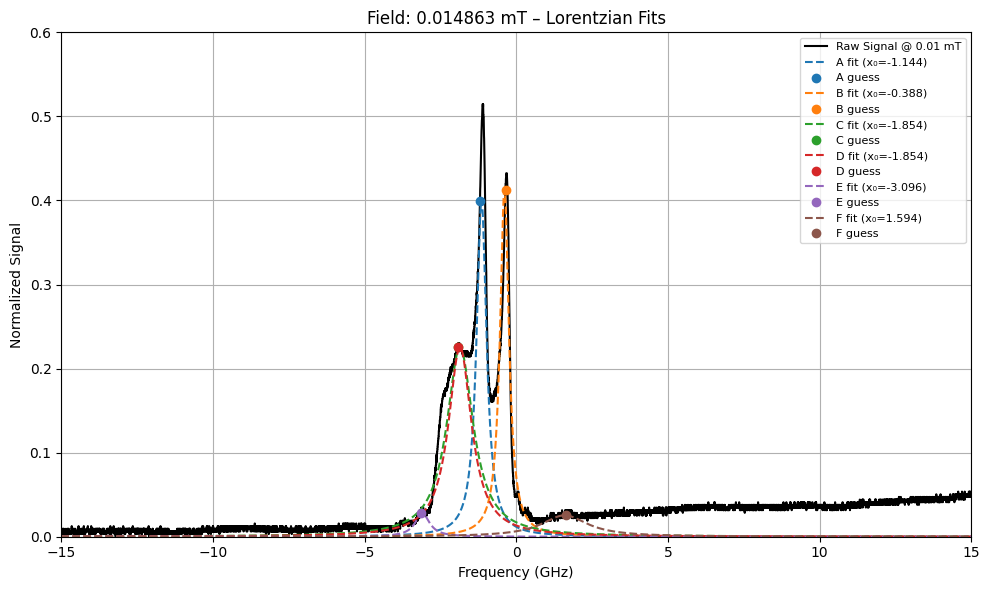

13.346666666666668

--- Fitting Lorentzians at B = 0.01 mT ---
  Trying A at B = 13.346667 mT
    Guess: Gamma=0.3992, x0=-1.1058, scale=0.2972
    Bounds: [[np.float64(0.003991695305581757), np.float64(-1.15578566), np.float64(0.029718571934600792)]], [[np.float64(0.3991695305581757), np.float64(-1.05578566), np.float64(0.2971857193460079)]]
  Trying B at B = 13.346667 mT
    Guess: Gamma=0.2661, x0=-0.3962, scale=0.1705
    Bounds: [[np.float64(0.002661130203721171), np.float64(-0.44615093899999997), np.float64(0.01704876178908705)]], [[np.float64(0.2661130203721171), np.float64(-0.346150939), np.float64(0.1704876178908705)]]
  Trying C at B = 13.346667 mT
    Guess: Gamma=0.8870, x0=-1.9485, scale=0.3087
    Bounds: [[np.float64(0.00887043401), np.float64(-1.9984768910000001), np.float64(0.03086564631968738)]], [[np.float64(0.887043401), np.float64(-1.898476891), np.float64(0.3086564631968738)]]
  Trying D at B = 13.346667 mT
    Guess: Gamma=1.0645, x0=-1.9485, scale=0.3704
    Bou

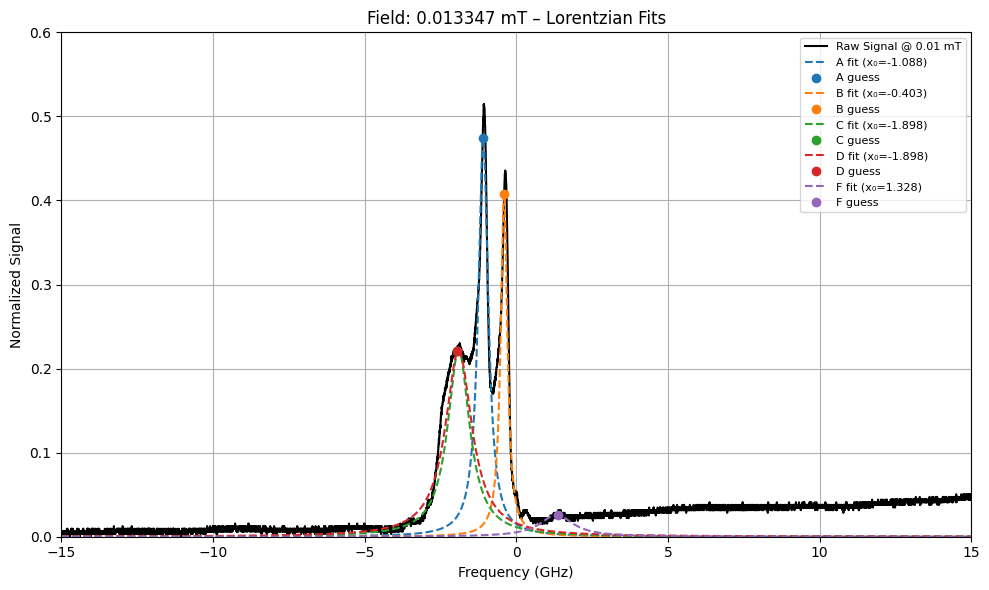

11.83

--- Fitting Lorentzians at B = 0.01 mT ---
  Trying A at B = 11.830000 mT
    Guess: Gamma=0.3548, x0=-1.0614, scale=0.2672
    Bounds: [[np.float64(0.003548173604961562), np.float64(-1.11143349), np.float64(0.02671943004136136)]], [[np.float64(0.3548173604961562), np.float64(-1.01143349), np.float64(0.2671943004136136)]]
  Trying B at B = 11.830000 mT
    Guess: Gamma=0.4435, x0=-0.3962, scale=0.3034
    Bounds: [[np.float64(0.004435217006201952), np.float64(-0.44615093899999997), np.float64(0.030344875737705612)]], [[np.float64(0.4435217006201952), np.float64(-0.346150939), np.float64(0.3034487573770561)]]
  Trying C at B = 11.830000 mT
    Guess: Gamma=0.8427, x0=-2.0815, scale=0.3006
    Bounds: [[np.float64(0.008426912311783781), np.float64(-2.1315334019999996), np.float64(0.03006131334567143)]], [[np.float64(0.8426912311783781), np.float64(-2.031533402), np.float64(0.3006131334567143)]]
  Trying D at B = 11.830000 mT
    Guess: Gamma=0.9757, x0=-2.0372, scale=0.3522
    Bo

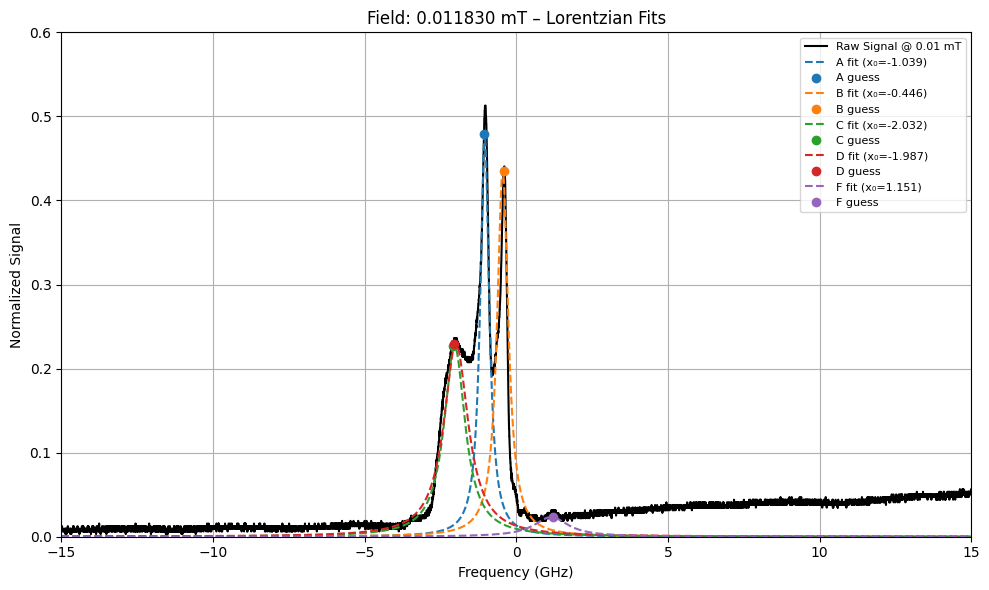

10.313333333333334

--- Fitting Lorentzians at B = 0.01 mT ---
  Trying A at B = 10.313333 mT
    Guess: Gamma=0.4879, x0=-1.0171, scale=0.3721
    Bounds: [[np.float64(0.004878738706822184), np.float64(-1.06708132), np.float64(0.03720565887749756)]], [[np.float64(0.4878738706822183), np.float64(-0.9670813199999999), np.float64(0.3720565887749756)]]
  Trying B at B = 10.313333 mT
    Guess: Gamma=0.4879, x0=-0.4849, scale=0.3047
    Bounds: [[np.float64(0.004878738706822147), np.float64(-0.534855279), np.float64(0.030473084103755974)]], [[np.float64(0.4878738706822147), np.float64(-0.434855279), np.float64(0.3047308410375597)]]
  Trying C at B = 10.313333 mT
    Guess: Gamma=0.9314, x0=-2.0815, scale=0.3496
    Bounds: [[np.float64(0.009313955713024137), np.float64(-2.1315334019999996), np.float64(0.03496247110773816)]], [[np.float64(0.9313955713024136), np.float64(-2.031533402), np.float64(0.3496247110773816)]]
  Trying D at B = 10.313333 mT
    Guess: Gamma=0.7983, x0=-2.0815, scale=

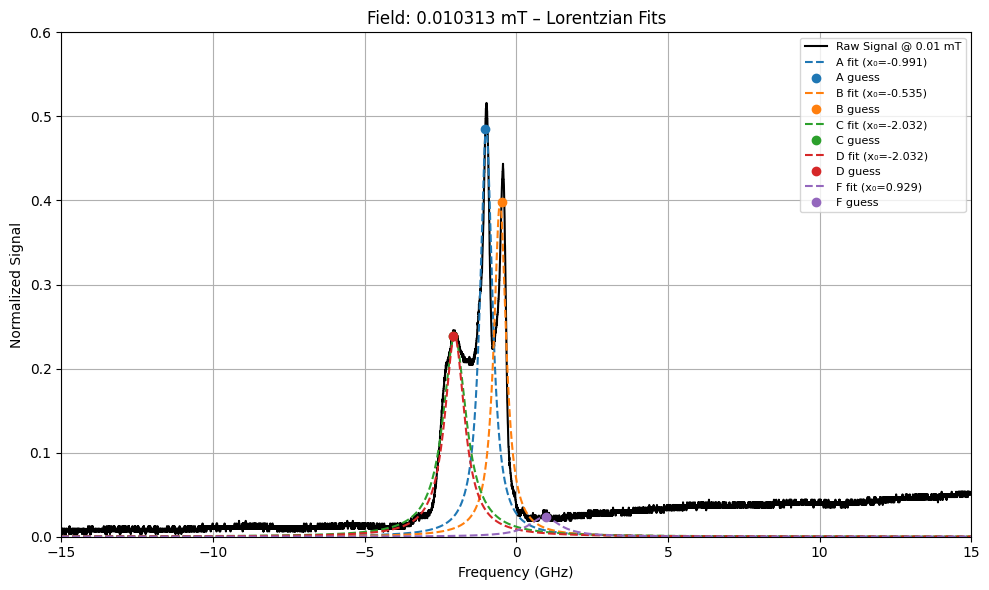

8.796666666666669

--- Fitting Lorentzians at B = 0.01 mT ---
  Trying A at B = 8.796667 mT
    Guess: Gamma=0.3992, x0=-0.9727, scale=0.3122
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-1.02272915), np.float64(0.031216248215046212)]], [[np.float64(0.3991695305581793), np.float64(-0.92272915), np.float64(0.3121624821504621)]]
  Trying B at B = 8.796667 mT
    Guess: Gamma=0.3548, x0=-0.4849, scale=0.2444
    Bounds: [[np.float64(0.003548173604961562), np.float64(-0.534855279), np.float64(0.0244417678)]], [[np.float64(0.3548173604961562), np.float64(-0.434855279), np.float64(0.244417678)]]
  Trying C at B = 8.796667 mT
    Guess: Gamma=0.8427, x0=-2.1259, scale=0.3306
    Bounds: [[np.float64(0.008426912311783781), np.float64(-2.175885572), np.float64(0.03306158519387758)]], [[np.float64(0.8426912311783781), np.float64(-2.0758855720000002), np.float64(0.3306158519387758)]]
  Trying D at B = 8.796667 mT
    Guess: Gamma=1.0645, x0=-2.1259, scale=0.4176
    Bounds: [[np.fl

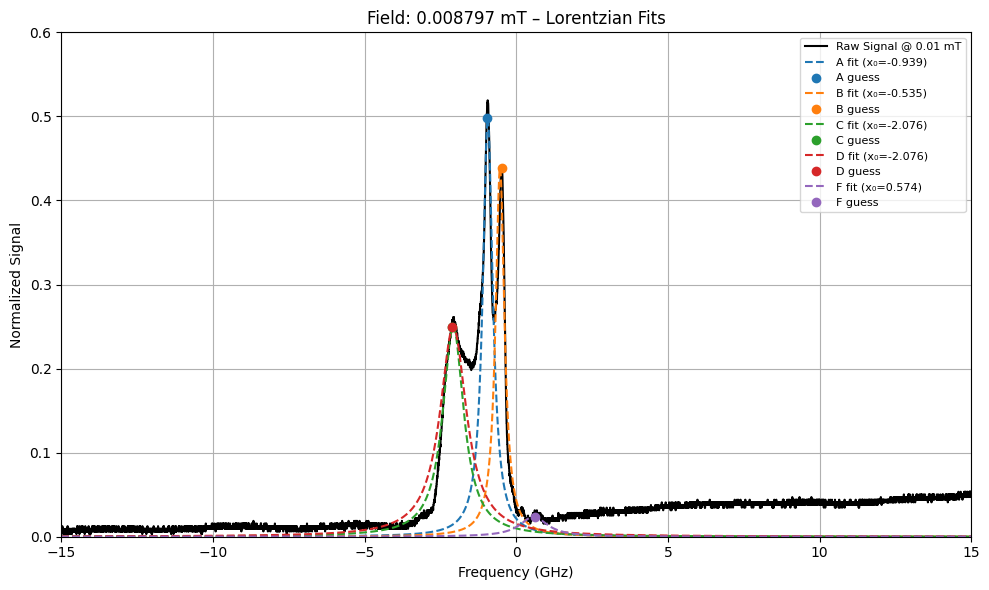

7.28

--- Fitting Lorentzians at B = 0.01 mT ---
  Trying A at B = 7.280000 mT
    Guess: Gamma=0.4435, x0=-0.9727, scale=0.3057
    Bounds: [[np.float64(0.004435217006201988), np.float64(-1.02272915), np.float64(0.03056752354916289)]], [[np.float64(0.4435217006201988), np.float64(-0.92272915), np.float64(0.3056752354916289)]]
  Trying B at B = 7.280000 mT
    Guess: Gamma=0.3105, x0=-0.5292, scale=0.2230
    Bounds: [[np.float64(0.003104651904341367), np.float64(-0.5792074490000001), np.float64(0.022297118720544212)]], [[np.float64(0.3104651904341367), np.float64(-0.47920744900000006), np.float64(0.2229711872054421)]]
  Trying C at B = 7.280000 mT
    Guess: Gamma=1.0201, x0=-2.0372, scale=0.4073
    Bounds: [[np.float64(0.010200999114264527), np.float64(-2.0871812309999997), np.float64(0.040731246329763174)]], [[np.float64(1.0200999114264526), np.float64(-1.9871812309999999), np.float64(0.4073124632976317)]]
  Trying D at B = 7.280000 mT
    Guess: Gamma=1.0645, x0=-2.0815, scale=0.4

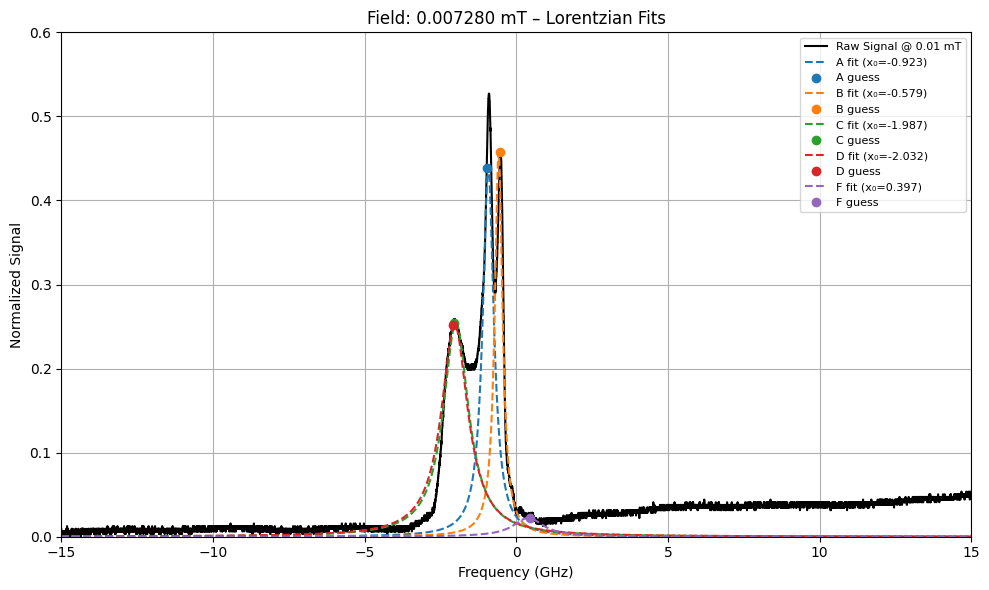

5.763333333333334

--- Fitting Lorentzians at B = 0.01 mT ---
  Trying A at B = 5.763333 mT
    Guess: Gamma=0.3548, x0=-0.9284, scale=0.2528
    Bounds: [[np.float64(0.003548173604961597), np.float64(-0.9783769800000001), np.float64(0.02527723560966526)]], [[np.float64(0.3548173604961597), np.float64(-0.87837698), np.float64(0.2527723560966526)]]
  Trying B at B = 5.763333 mT
    Guess: Gamma=0.3548, x0=-0.6179, scale=0.2299
    Bounds: [[np.float64(0.003548173604961562), np.float64(-0.667911789), np.float64(0.02298504421312517)]], [[np.float64(0.3548173604961562), np.float64(-0.567911789), np.float64(0.2298504421312517)]]
  Trying C at B = 5.763333 mT
    Guess: Gamma=0.9314, x0=-2.1259, scale=0.3695
    Bounds: [[np.float64(0.009313955713024137), np.float64(-2.175885572), np.float64(0.03694675453113997)]], [[np.float64(0.9313955713024136), np.float64(-2.0758855720000002), np.float64(0.3694675453113997)]]
  Trying D at B = 5.763333 mT
    Guess: Gamma=1.1975, x0=-2.0372, scale=0.4851

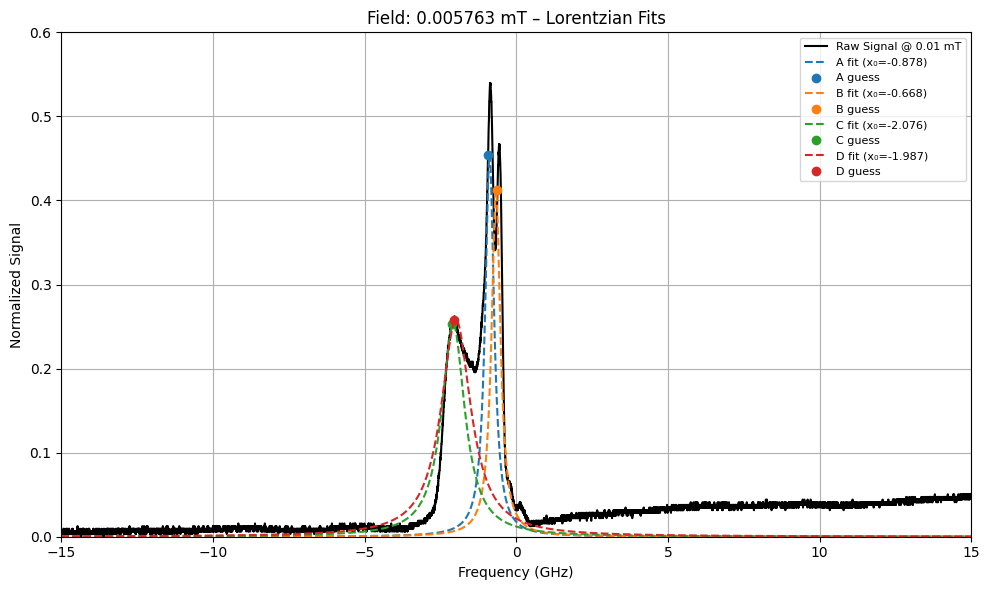

4.246666666666667

--- Fitting Lorentzians at B = 0.00 mT ---
  Trying A at B = 4.246667 mT
    Guess: Gamma=0.3105, x0=-0.8397, scale=0.2652
    Bounds: [[np.float64(0.0031046519043414025), np.float64(-0.88967264), np.float64(0.02652150326825506)]], [[np.float64(0.3104651904341402), np.float64(-0.7896726399999999), np.float64(0.2652150326825506)]]
  Trying B at B = 4.246667 mT
    Guess: Gamma=0.3548, x0=-0.6179, scale=0.2658
    Bounds: [[np.float64(0.003548173604961562), np.float64(-0.667911789), np.float64(0.026575631486479814)]], [[np.float64(0.3548173604961562), np.float64(-0.567911789), np.float64(0.2657563148647981)]]
  Trying C at B = 4.246667 mT
    Guess: Gamma=0.9314, x0=-2.0815, scale=0.3767
    Bounds: [[np.float64(0.009313955713024137), np.float64(-2.1315334019999996), np.float64(0.03767431593254833)]], [[np.float64(0.9313955713024136), np.float64(-2.031533402), np.float64(0.3767431593254833)]]
  Trying D at B = 4.246667 mT
    Guess: Gamma=1.1088, x0=-2.1702, scale=0.43

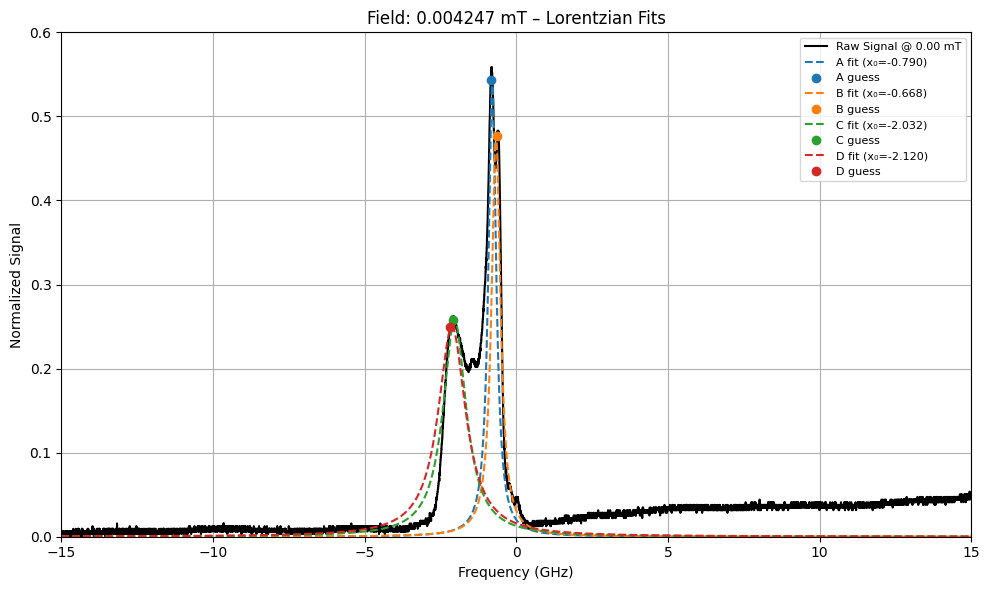

2.7300000000000004

--- Fitting Lorentzians at B = 0.00 mT ---
  Trying A at B = 2.730000 mT
    Guess: Gamma=0.5322, x0=-0.8397, scale=0.4261
    Bounds: [[np.float64(0.005322260407442379), np.float64(-0.88967264), np.float64(0.04261414462889381)]], [[np.float64(0.5322260407442378), np.float64(-0.7896726399999999), np.float64(0.4261414462889381)]]
  Trying B at B = 2.730000 mT
    Guess: Gamma=0.6209, x0=-0.7510, scale=0.5569
    Bounds: [[np.float64(0.006209303808682769), np.float64(-0.8009683000000001), np.float64(0.05568526156953412)]], [[np.float64(0.6209303808682769), np.float64(-0.7009683), np.float64(0.5568526156953412)]]
  Trying C at B = 2.730000 mT
    Guess: Gamma=0.9314, x0=-2.2589, scale=0.3294
    Bounds: [[np.float64(0.009313955713024137), np.float64(-2.3089420819999997), np.float64(0.032942064464061324)]], [[np.float64(0.9313955713024136), np.float64(-2.208942082), np.float64(0.3294206446406132)]]
  Trying D at B = 2.730000 mT
    Guess: Gamma=1.0201, x0=-2.2589, scale

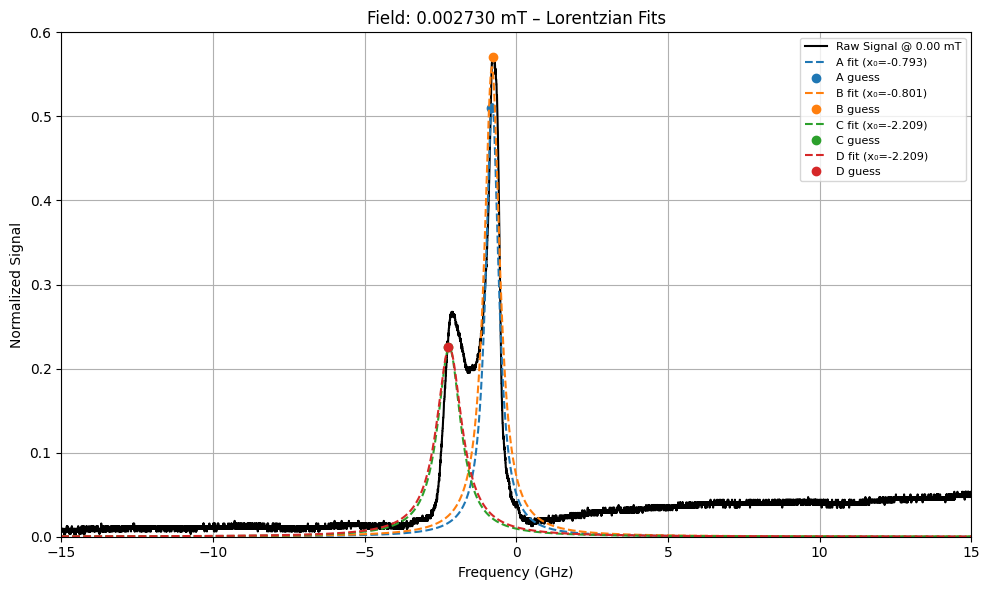

1.2133333333333334

--- Fitting Lorentzians at B = 0.00 mT ---
  Trying A at B = 1.213333 mT
    Guess: Gamma=0.5322, x0=-0.7066, scale=0.4776
    Bounds: [[np.float64(0.005322260407442379), np.float64(-0.75661613), np.float64(0.047764240900000005)]], [[np.float64(0.5322260407442378), np.float64(-0.65661613), np.float64(0.477642409)]]
  Trying B at B = 1.213333 mT
    Guess: Gamma=0.5766, x0=-0.7953, scale=0.4958
    Bounds: [[np.float64(0.005765782108062574), np.float64(-0.84532047), np.float64(0.049577720986184785)]], [[np.float64(0.5765782108062574), np.float64(-0.7453204699999999), np.float64(0.4957772098618478)]]
  Trying C at B = 1.213333 mT
    Guess: Gamma=0.9757, x0=-2.1259, scale=0.4114
    Bounds: [[np.float64(0.009757477413644333), np.float64(-2.175885572), np.float64(0.04113880503064973)]], [[np.float64(0.9757477413644332), np.float64(-2.0758855720000002), np.float64(0.4113880503064973)]]
  Trying D at B = 1.213333 mT
    Guess: Gamma=0.9757, x0=-2.1259, scale=0.4114
    B

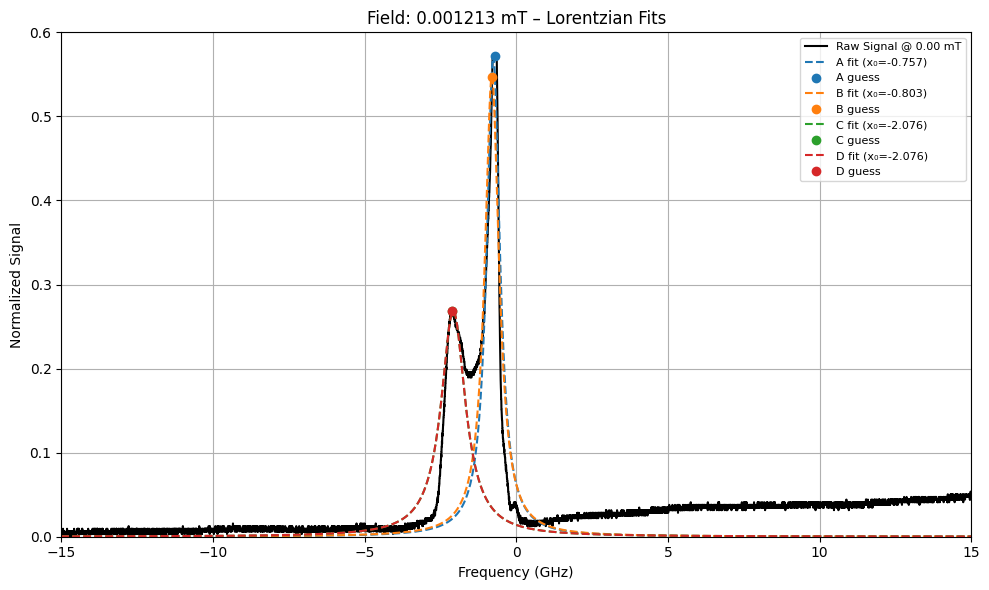

4

In [86]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np

# --- Lorentzian function ---
def lorentzian(x, Gamma, x0, scale):
    return scale * (1 / np.pi) * (Gamma / 2) / ((x - x0)**2 + (Gamma / 2)**2)

# --- Storage dictionary ---
fit_results = {peak: [] for peak in peak_data.keys()}  # A–F

# --- Loop over magnetic fields from peak_data["A"] ---
for B_target_mT in peak_data["A"]["b_field"]:
    print(B_target_mT)
    # Match B field exactly with raw data (converted to mT)
    idx = np.where(np.isclose(fields*1000, B_target_mT, atol=1e-3))[0]
    if len(idx) == 0:
        print(f"Field {B_target_mT:.2f} mT not found in raw data.")
        continue
    raw_idx = idx[0]
    raw_signal = signals[raw_idx]
    B_matched = fields[raw_idx]  # For consistent units

    print(f"\n--- Fitting Lorentzians at B = {B_matched:.2f} mT ---")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(freq_axis_GHz, raw_signal, color='black', label=f"Raw Signal @ {B_matched:.2f} mT")

    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    peak_color_idx = 0

    # --- Loop over each peak A–F ---
    for peak_label, pdata in peak_data.items():
        b_fields = pdata["b_field"]
        freqs = pdata["freq"]
        gammas = pdata["linewidth"]
        scales = pdata["scale"]

        # Find match at this field
        match_idx = np.where(np.isclose(b_fields, B_target_mT, atol=1e-3))[0]
        if len(match_idx) == 0:
            continue  # Skip if no match

        for idx in match_idx:
            Gamma_0 = gammas[idx]
            x0_0 = freqs[idx]
            scale_0 = scales[idx]
            guess = [Gamma_0, x0_0, scale_0]




            # Use guess-centered bounds (± reasonable factor)
            lower_bounds = [Gamma_0 * 0.01, x0_0 - 0.05, scale_0 * 0.1]
            upper_bounds = [Gamma_0 * 1, x0_0 + 0.05, scale_0 * 1]

            print(f"  Trying {peak_label} at B = {B_target_mT:.6f} mT")
            print(f"    Guess: Gamma={Gamma_0:.4f}, x0={x0_0:.4f}, scale={scale_0:.4f}")
            print(f"    Bounds: [{lower_bounds}], [{upper_bounds}]")

            try:
                popt, _ = curve_fit(
                    lorentzian,
                    freq_axis_GHz,
                    raw_signal,
                    p0=guess,
                    bounds=(lower_bounds, upper_bounds),
                    maxfev=10000
                )
                Gamma_fit, x0_fit, scale_fit = popt

                # Plot Lorentzian fit
                L = lorentzian(freq_axis_GHz, *popt)
                ax.plot(freq_axis_GHz, L, '--', color=colors[peak_color_idx % 10],
                        label=f"{peak_label} fit (x₀={x0_fit:.3f})")

                # Plot marker at guessed x₀
                y0_guess = lorentzian(x0_0, *guess)
                ax.plot(x0_0, y0_guess, 'o', color=colors[peak_color_idx % 10], label=f"{peak_label} guess")

                # Store result
                fit_results[peak_label].append({
                    "B Field (mT)": B_matched,
                    "Gamma (GHz)": Gamma_fit,
                    "Center Frequency (GHz)": x0_fit,
                    "Scale": scale_fit
                })

            except (RuntimeError, ValueError) as e:
                print(f"Fit failed for {peak_label} at B = {B_matched:.2f} mT: {e}")
                continue

        peak_color_idx += 1

    # --- Plot formatting ---
    ax.set_xlim([-15, 15])
    ax.set_ylim([0, 0.6])
    ax.set_title(f"Field: {B_matched:.6f} mT – Lorentzian Fits")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Normalized Signal")
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# --- Convert to DataFrames ---
fit_dataframes = {
    peak: pd.DataFrame(entries) for peak, entries in fit_results.items() if entries
}
4

In [ ]:
from datetime import datetime
# Define your save directory
save_dir = "data_optics/fitted_lorentzian_data_2025-03-25_IH_site1"
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
# Loop through and save each DataFrame
for peak_label, df in fit_dataframes.items():
    save_path = os.path.join(save_dir, f"lorentzian_fits_peak_{peak_label}_{timestamp}.csv")
    df.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

Saved: data_optics/fitted_lorentzian_data_2025-03-25_IH_site1/lorentzian_fits_peak_A_2025_04_18_20_36_07.csv
Saved: data_optics/fitted_lorentzian_data_2025-03-25_IH_site1/lorentzian_fits_peak_B_2025_04_18_20_36_07.csv
Saved: data_optics/fitted_lorentzian_data_2025-03-25_IH_site1/lorentzian_fits_peak_C_2025_04_18_20_36_07.csv
Saved: data_optics/fitted_lorentzian_data_2025-03-25_IH_site1/lorentzian_fits_peak_D_2025_04_18_20_36_07.csv
Saved: data_optics/fitted_lorentzian_data_2025-03-25_IH_site1/lorentzian_fits_peak_E_2025_04_18_20_36_07.csv
Saved: data_optics/fitted_lorentzian_data_2025-03-25_IH_site1/lorentzian_fits_peak_F_2025_04_18_20_36_07.csv


min  340.2607897169147
max 401.5407298213775
Peak A:
  Slope = 1.554014 MHz/mT ± 0.657537
  Total broadening (ΔΓ) = 61.279940 MHz
  Over = 39.433333 mT
  Slope of linewidth: 0.001554 GHz/mT
  d(ΔB)/dB = 0.008893 ± 0.003763 (unitless)
  Field inhomogeneity: 0.8893% ± 0.3821%



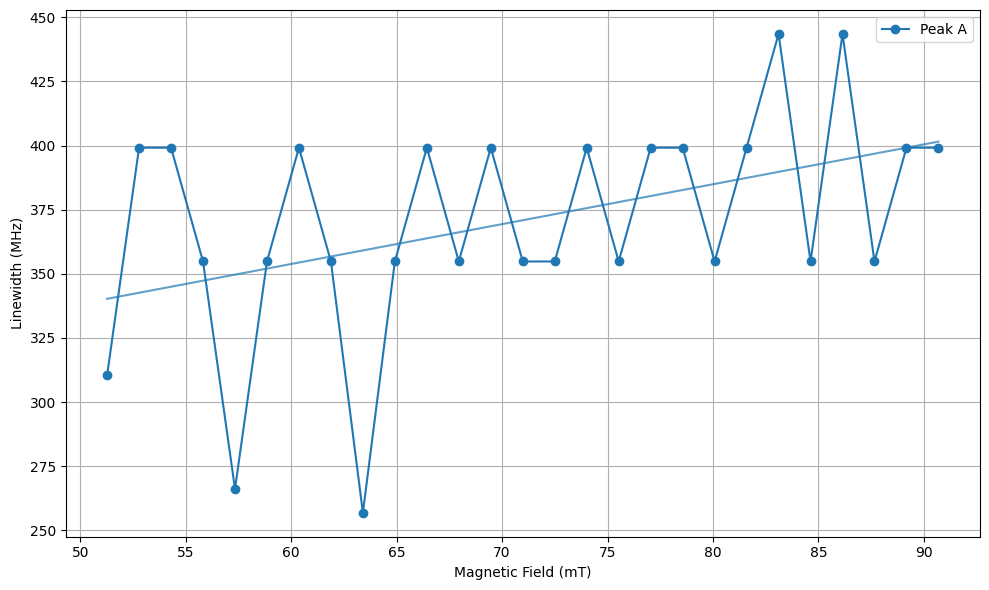

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# Define magnetic field threshold (in mT)
exclude_below = 50  # exclude B-fields ≤ 45 mT

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define distinct colors for each peak
colors = plt.cm.tab10(range(len(fit_dataframes)))

# ---- Physical constants ----
muB = 9.27400968e-24  # Bohr Magneton (J/T)
hbar = 1.054571817E-34  # Reduced Planck constant (Js)
h = 2 * np.pi * hbar
scale = (h / muB) * 1e9 / 1e-3  # Converts GHz/mT to unitless g_eff

g_eff = 12.485805793985856  # unitless

# Input B-field relative uncertainty (0.27/3.6)
B_relative_uncertainty = 0.27 / 3.6

# Plot linewidth vs B-field and apply linear fits
for i, (peak_label, df) in enumerate(fit_dataframes.items()):
    if "B Field (mT)" not in df.columns or "Gamma (GHz)" not in df.columns:
        continue

    if peak_label in ["E", "F", "C", "D", "B"]:
        continue

    # Extract data
    B_fields = df["B Field (mT)"].values
    gammas = df["Gamma (GHz)"].values
    gammas = gammas * 1000
    B_fields = B_fields * 1000

    # Mask out data with B-field ≤ 45 mT
    mask = B_fields > exclude_below
    B_fit = B_fields[mask]
    gamma_fit = gammas[mask]

    # Linear fit
    if len(B_fit) > 1:
        # Sort B_fit and gamma_fit by B-field
        sort_indices = np.argsort(B_fit)
        B_fit_sorted = B_fit[sort_indices]

        coeffs, cov = np.polyfit(B_fit, gamma_fit, 1, cov=True)
        slope, intercept = coeffs
        slope_err = np.sqrt(cov[0, 0])  # 1σ uncertainty in slope

        fit_line = np.poly1d(coeffs)(B_fit)

        # R² calculation
        residuals = gamma_fit - fit_line
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((gamma_fit - np.mean(gamma_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)

        # Total broadening
        print("min ", fit_line[-1])
        print("max",fit_line[0])
        total_broadening = fit_line[0] - fit_line[-1]
        field_range = np.max(B_fit) - np.min(B_fit)

        # Print results
        print(f"Peak {peak_label}:")
        print(f"  Slope = {slope:.6f} MHz/mT ± {slope_err:.6f}")
        print(f"  Total broadening (ΔΓ) = {total_broadening:.6f} MHz")
        print(f"  Over = {field_range:.6f} mT")

        # --- Slope of linewidth vs field (in GHz/mT) ---
        linewidth_slope = slope * 1e-3  # dΓ/dB in GHz/mT
        linewidth_slope_err = slope_err * 1e-3

        # --- Convert slope to Hz/T ---
        linewidth_slope_Hz_per_T = linewidth_slope * 1e9 / 1e-3  # Hz/T
        linewidth_slope_Hz_per_T_err = linewidth_slope_err * 1e9 / 1e-3

        # --- Compute d(delta_B)/dB ---
        dDeltaB_dB = (h * linewidth_slope_Hz_per_T) / (muB * g_eff)  # unitless
        dDeltaB_dB_err = (h * linewidth_slope_Hz_per_T_err) / (muB * g_eff)

        # --- Express as percentage ---
        percent_inhomogeneity_per_T = dDeltaB_dB * 100
        percent_inhomogeneity_per_T_err = dDeltaB_dB_err * 100

        percent_inhomogeneity_per_mT = dDeltaB_dB * 100 / 1e3
        percent_inhomogeneity_per_mT_err = dDeltaB_dB_err * 100 / 1e3

        # Include B-field measurement uncertainty
        total_percent_error = np.sqrt((dDeltaB_dB_err / dDeltaB_dB) ** 2 + B_relative_uncertainty ** 2)
        total_percent_uncertainty = percent_inhomogeneity_per_T * total_percent_error

        print(f"  Slope of linewidth: {linewidth_slope:.6f} GHz/mT")
        print(f"  d(ΔB)/dB = {dDeltaB_dB:.6f} ± {dDeltaB_dB_err:.6f} (unitless)")
        print(f"  Field inhomogeneity: {percent_inhomogeneity_per_T:.4f}% ± {total_percent_uncertainty:.4f}%\n")
        # print(f"  Field inhomogeneity per mT: {percent_inhomogeneity_per_mT:.6f}% ± {percent_inhomogeneity_per_mT_err:.6f}%\n")

        # Plot only masked data
        ax.plot(B_fit, gamma_fit,"o-",label=f"Peak {peak_label}", color=colors[i])
        ax.plot(B_fit, fit_line, '-', color=colors[i], linewidth=1.5, alpha=0.7)

# Final plot formatting
ax.set_xlabel("Magnetic Field (mT)")
ax.set_ylabel("Linewidth (MHz)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [31]:
# ---- Physical constants ----
muB = 9.27400968e-24  # Bohr Magneton (J/T)
hbar = 1.054571817E-34  # Reduced Planck constant (Js)
h = 2 * np.pi * hbar
scale = (h / muB) * 1e9 / 1e-3  # Converts GHz/mT to unitless g_eff


g_eff =12          # unitless

# --- Slope of linewidth vs field (in GHz/mT) ---
linewidth_slope = 1.535357e-3  # dΓ/dB in GHz/mT

# --- Convert slope to Hz/T ---
linewidth_slope_Hz_per_T = linewidth_slope * 1e9 / 1e-3  # Hz/T

# --- Compute d(delta_B)/dB ---
dDeltaB_dB = (h * linewidth_slope_Hz_per_T) / (muB * g_eff)  # unitless

# --- Express as percentage ---
percent_inhomogeneity_per_T = dDeltaB_dB * 100
percent_inhomogeneity_per_mT = dDeltaB_dB * 100 / 1e3  # per mT

print(f"Slope of linewidth: {linewidth_slope:.6f} GHz/mT")
print(f"d(ΔB)/dB = {dDeltaB_dB:.6f} (unitless)")
print(f"Field inhomogeneity {percent_inhomogeneity_per_T:.4f}%")



Slope of linewidth: 0.001535 GHz/mT
d(ΔB)/dB = 0.009141 (unitless)
Field inhomogeneity 0.9141%


## Trial ##

In [42]:
print(peak_data["A"]["b_field"])

[90.69666667 89.18       87.66333333 86.14666667 84.63       83.11333333
 81.59666667 80.08       78.56333333 77.04666667 75.53       74.01333333
 72.49666667 70.98       69.46333333 67.94666667 66.43       64.91333333
 63.39666667 61.88       60.36333333 58.84666667 57.33       55.81333333
 54.29666667 52.78       51.26333333 49.74666667 48.23       46.71333333
 45.19666667 43.68       42.16333333 40.64666667 39.13       37.61333333
 36.09666667 34.58       33.06333333 31.54666667 30.03       28.51333333
 26.99666667 25.48       23.96333333 22.44666667 20.93       19.41333333
 17.89666667 16.38       14.86333333 13.34666667 11.83       10.31333333
  8.79666667  7.28        5.76333333  4.24666667  2.73        1.21333333]


33.06333333

--- Fitting Lorentzians at B = 0.03 mT ---
  Trying A at B = 33.063333 mT
    Guess: Gamma=0.3992, x0=-1.6380, scale=0.3081
    Bounds: [[np.float64(0.0039916953055817925), np.float64(-1.688011701), np.float64(0.030810242461546553)]], [[np.float64(0.3991695305581793), np.float64(-1.5880117009999999), np.float64(0.3081024246154655)]]
  Trying B at B = 33.063333 mT
    Guess: Gamma=0.3548, x0=0.0917, scale=0.1907
    Bounds: [[np.float64(0.003548173604961562), np.float64(0.04172293199999999), np.float64(0.01907079648240998)]], [[np.float64(0.3548173604961562), np.float64(0.141722932), np.float64(0.1907079648240998)]]
  Trying C at B = 33.063333 mT
    Guess: Gamma=0.6209, x0=-2.7025, scale=0.1701
    Bounds: [[np.float64(0.006209303808682769), np.float64(-2.752463782), np.float64(0.017007387856479213)]], [[np.float64(0.6209303808682769), np.float64(-2.6524637820000003), np.float64(0.1700738785647921)]]
  Trying E at B = 33.063333 mT
    Guess: Gamma=0.6209, x0=-5.8515, scale

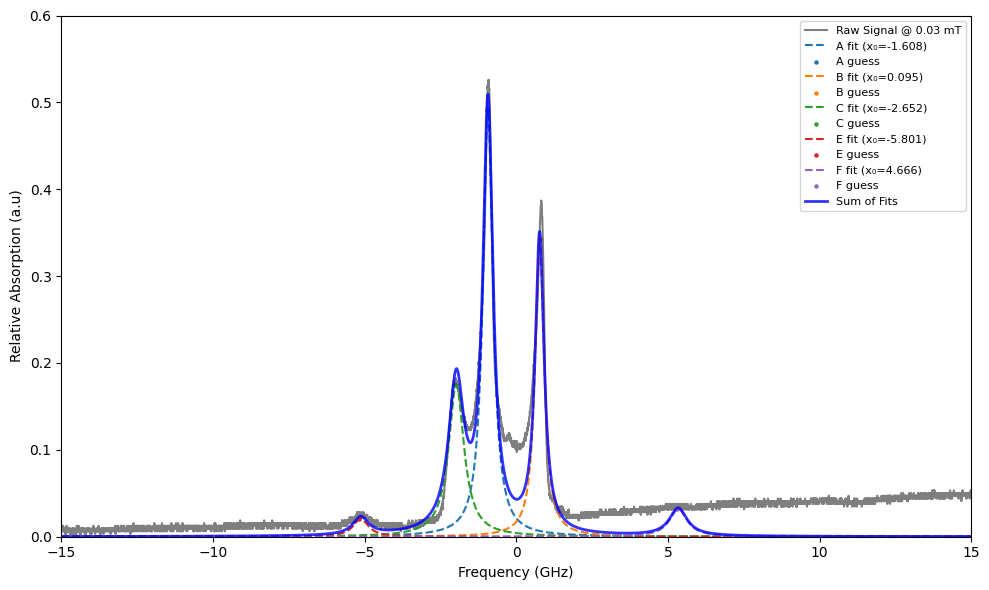

In [84]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
freq_shift = -0.675555
freq_axis_GHz_shifted = freq_axis_GHz-freq_shift#-freq_shift#freq_shift
# --- Lorentzian function ---
def lorentzian(x, Gamma, x0, scale):
    return scale * (1 / np.pi) * (Gamma / 2) / ((x - x0)**2 + (Gamma / 2)**2)

# --- Storage dictionary ---
fit_results = {peak: [] for peak in peak_data.keys()}  # A–F

# --- Loop over magnetic fields from peak_data["A"] ---
for B_target_mT in [ 33.06333333]:# peak_data["A"]["b_field"]:[69.46333333]:#
    print(B_target_mT)
    # Match B field exactly with raw data (converted to mT)
    idx = np.where(np.isclose(fields*1000, B_target_mT, atol=1e-3))[0]
    if len(idx) == 0:
        print(f"Field {B_target_mT:.2f} mT not found in raw data.")
        continue
    raw_idx = idx[0]
    raw_signal = signals[raw_idx]
    B_matched = fields[raw_idx]  # For consistent units

    print(f"\n--- Fitting Lorentzians at B = {B_matched:.2f} mT ---")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(freq_axis_GHz_shifted, raw_signal, color='black', label=f"Raw Signal @ {B_matched:.2f} mT", alpha =0.5)

    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    peak_color_idx = 0

    lorentzian_fits = []  # Store each Lorentzian to sum later

    # --- Loop over each peak A–F ---
    for peak_label, pdata in peak_data.items():
        b_fields = pdata["b_field"]
        freqs = pdata["freq"]
        gammas = pdata["linewidth"]
        scales = pdata["scale"]

        # Find match at this field
        match_idx = np.where(np.isclose(b_fields, B_target_mT, atol=1e-3))[0]
        if len(match_idx) == 0:
            continue  # Skip if no match

        for idx in match_idx:
            Gamma_0 = gammas[idx]
            x0_0 = freqs[idx]
            scale_0 = scales[idx]
            guess = [Gamma_0, x0_0, scale_0]

            # Use guess-centered bounds (± reasonable factor)
            lower_bounds = [Gamma_0 * 0.01, x0_0 - 0.05, scale_0 * 0.1]
            upper_bounds = [Gamma_0 * 1, x0_0 + 0.05, scale_0 * 1]

            print(f"  Trying {peak_label} at B = {B_target_mT:.6f} mT")
            print(f"    Guess: Gamma={Gamma_0:.4f}, x0={x0_0:.4f}, scale={scale_0:.4f}")
            print(f"    Bounds: [{lower_bounds}], [{upper_bounds}]")

            try:
                popt, _ = curve_fit(
                    lorentzian,
                    freq_axis_GHz,
                    raw_signal,
                    p0=guess,
                    bounds=(lower_bounds, upper_bounds),
                    maxfev=10000
                )
                Gamma_fit, x0_fit, scale_fit = popt

                # Plot Lorentzian fit
                L = lorentzian(freq_axis_GHz, *popt)
                ax.plot(freq_axis_GHz-freq_shift, L, '--', color=colors[peak_color_idx % 10],
                        label=f"{peak_label} fit (x₀={x0_fit:.3f})")

                # Store this fit for summing later
                lorentzian_fits.append(L)

                # Plot marker at guessed x₀
                y0_guess = lorentzian(x0_0, *guess)
                ax.scatter(x0_0-freq_shift, y0_guess, color=colors[peak_color_idx % 10], label=f"{peak_label} guess", s=5)

                # Store result
                fit_results[peak_label].append({
                    "B Field (mT)": B_matched,
                    "Gamma (GHz)": Gamma_fit,
                    "Center Frequency (GHz)": x0_fit,
                    "Scale": scale_fit
                })

            except (RuntimeError, ValueError) as e:
                print(f"Fit failed for {peak_label} at B = {B_matched:.2f} mT: {e}")
                continue

        peak_color_idx += 1

    # --- Plot sum of all Lorentzian fits ---
    if lorentzian_fits:
        total_fit = np.sum(lorentzian_fits, axis=0)
        ax.plot(freq_axis_GHz-freq_shift, total_fit, color='blue', linewidth=2, label='Sum of Fits', alpha=0.8)

    # --- Plot formatting ---
    ax.set_xlim([-15, 15])
    ax.set_ylim([0, 0.6])
    # ax.set_title(f"Field: {B_matched:.6f} mT – Lorentzian Fits")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Relative Absorption (a.u)")
    ax.legend(fontsize=8)
    # ax.grid(True)
    plt.tight_layout()
    plt.show()

# --- Convert to DataFrames ---
fit_dataframes = {
    peak: pd.DataFrame(entries) for peak, entries in fit_results.items() if entries
}


Figure saved as /Users/fergusayton/Documents/My Library/fayt3249/2024/Honours Thesis/Thesis Figures and Diagrams/Figures/MyResults/IH_lorentzian_fit_33mT.png


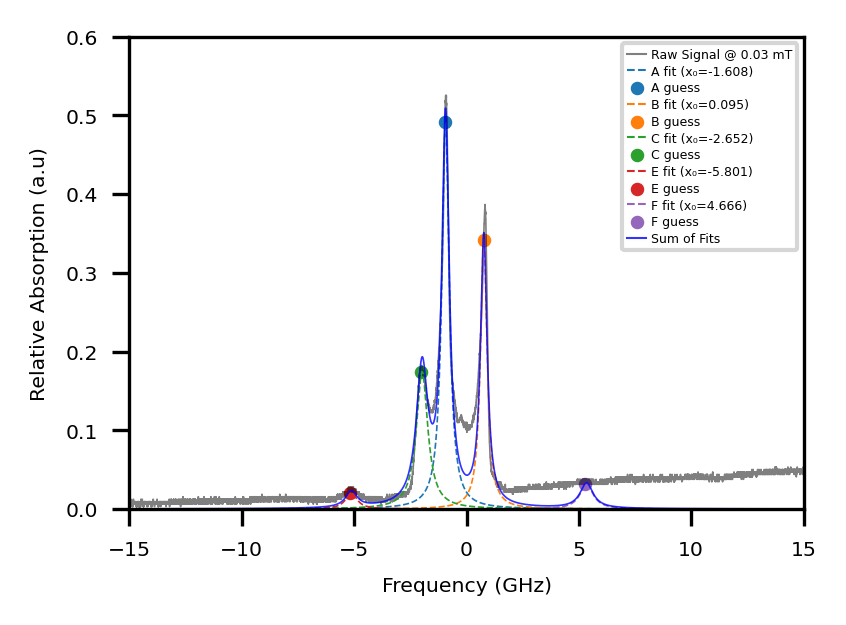

In [85]:

# mf.apply_fig_style(fig,ax,style="large", colorbar=cbar)
# mf.save_figure(fig,"25_03_2025_IH_abosorption_site1",folder=figure_save_path,dpi=1200)
# fig

figure_save_path="/Users/fergusayton/Documents/My Library/fayt3249/2024/Honours Thesis/Thesis Figures and Diagrams/Figures/MyResults"
#mpl.rcParams['font.family'] = 'serif'
mf.apply_fig_style(
    fig=fig,
    ax=ax,
    style='small',
    line_size=0.4,
    marker_size=2,
    freeze_marker_size=True,
    dpi=300,
    freeze_lines=True,
    freeze_ticks=True,
    legend_fontsize=3,
    handle_linewidth=0.5,
    legend_handlelength=1.5,
    legend_handletextpad=0.4,
    legend_labelspacing=0.3,
    legend_borderpad=0.4
)

mf.save_figure(fig,
    filename="IH_lorentzian_fit_33mT",
    folder=figure_save_path, 
    file_format="png", 
    dpi=300
    )
fig
#195.11847 - 0.675555 = 195.117794445


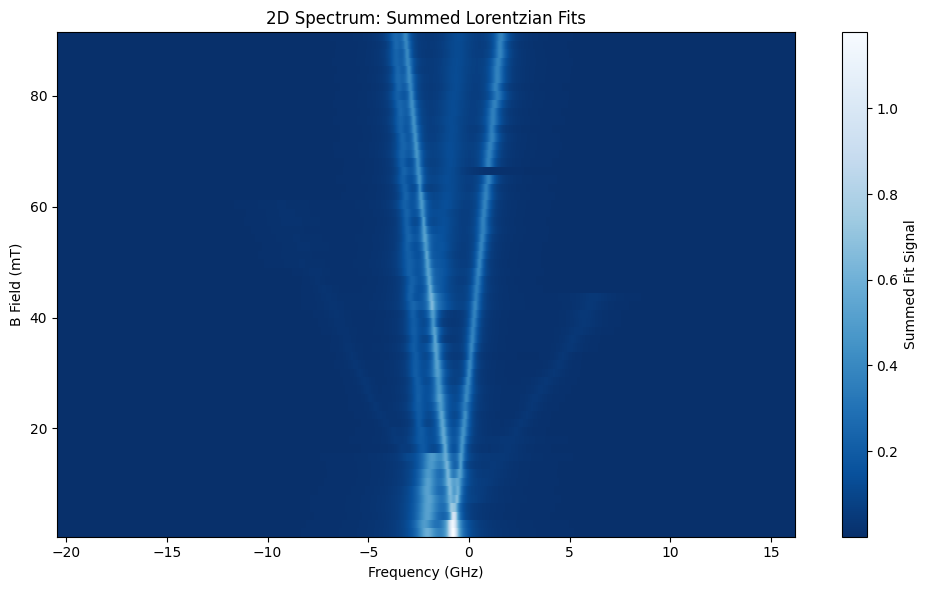

In [37]:
# --- Create 2D array of total fits for all B fields ---
total_fit_2d = []     # rows: B fields, cols: freq points
field_list = []       # store corresponding B field values

for B_target_mT in peak_data["A"]["b_field"]:
    idx = np.where(np.isclose(fields * 1000, B_target_mT, atol=1e-3))[0]
    if len(idx) == 0:
        continue
    raw_idx = idx[0]
    B_matched = fields[raw_idx]

    combined_lorentzians = []

    for peak_label, fits in fit_results.items():
        for entry in fits:
            if np.isclose(entry["B Field (mT)"], B_matched, atol=1e-6):
                L = lorentzian(
                    freq_axis_GHz,
                    entry["Gamma (GHz)"],
                    entry["Center Frequency (GHz)"],
                    entry["Scale"]
                )
                combined_lorentzians.append(L)

    if combined_lorentzians:
        total = np.sum(combined_lorentzians, axis=0)
        total_fit_2d.append(total)
        field_list.append(B_matched * 1000)  # store in mT

# Convert to arrays
total_fit_2d = np.array(total_fit_2d)
field_list = np.array(field_list)

# --- Plot 2D color map of summed Lorentzian fits ---
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(freq_axis_GHz, field_list, total_fit_2d, shading='auto', cmap='Blues_r')
fig.colorbar(im, ax=ax, label="Summed Fit Signal")
ax.set_title("2D Spectrum: Summed Lorentzian Fits")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("B Field (mT)")
plt.tight_layout()
plt.show()
